## Avance 1

In [3]:
import numpy as np
import pandas as pd

importamos las bibliotecas para manejo de los df y analisis

In [4]:
# Leer el archivo CSV y guardandolo en una variable llamada "data_latinoamerica"
data_latinoamerica = pd.read_csv("c:\\Users\\benav\\Downloads\\data_latinoamerica.csv", parse_dates=['date'])  #se puede de a chunk pero en este momento no es necesario 

Cargamos la base de datos con la que vamos a trabajar y le damos el nombre de data_latinoamerica

In [5]:
# Mostrando la cantidad de registros y columnas en el dataset
data_latinoamerica.shape

(12216057, 50)

Encontramos que tenemos en el df un total de 12.216.057 registros y 50 campos para trabajar

In [6]:
# Verificando que el dataset contenga la informacion correcta
data_latinoamerica.head()

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
0,AR,2020-01-01,AR,Argentina,3.0,0.0,3.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
1,AR,2020-01-02,AR,Argentina,14.0,0.0,17.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
2,AR,2020-01-03,AR,Argentina,3.0,0.0,20.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
3,AR,2020-01-04,AR,Argentina,7.0,0.0,27.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
4,AR,2020-01-05,AR,Argentina,5.0,0.0,32.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN


In [7]:
# Mostrando todos los paises en el dataset
data_latinoamerica['country_name'].unique()

array(['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia',
       'Costa Rica', 'Cuba', 'Dominican Republic', 'Ecuador', 'Guatemala',
       'Honduras', 'Mexico', 'Nicaragua', 'Panama', 'Peru', 'Puerto Rico',
       'Paraguay', 'El Salvador', 'Uruguay', 'Venezuela'], dtype=object)

In [8]:
# Paises a seleccionar son: Colombia, Argentina, Chile, México, Perú y Brasil.
seleccionar_paises = ['Colombia', 'Argentina', 'Chile', 'Mexico', 'Peru', 'Brazil']
data_latinoamerica_filtro_paises = data_latinoamerica[data_latinoamerica['country_name'].isin(seleccionar_paises)]
print(data_latinoamerica_filtro_paises['country_name'].unique())


['Argentina' 'Brazil' 'Chile' 'Colombia' 'Mexico' 'Peru']


Tenemos los 6 paises con los que trabajaremos

In [9]:
# Filtrando el dataset por fecha a partir del 2021
data_latinoamerica_fechas = data_latinoamerica_filtro_paises[data_latinoamerica_filtro_paises['date'] >= '2021-01-01']
print(data_latinoamerica_fechas.shape)

(7549375, 50)


Se redujo la cantidad de registros que teniamos en el df gracias al filtro de fecha desde el año 2021.

In [10]:
# Eliminando la fila si encontramos todos los registros nulos
df_samerica = data_latinoamerica_fechas.dropna(axis=0, how='all')

In [11]:
# Si encontramos la columnas con todos sus datos nulos la eliminamos
df_samerica = data_latinoamerica_fechas.dropna(axis=1, how='all')

In [12]:
# Mostrando como nos va quedando el DataFrame
df_samerica.head()

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN


In [13]:
# Lista de columnas para las que se desea rellenar valores faltantes (NaN) usando la mediana por país
columnas_mediana = ['cumulative_recovered', 
                    'cumulative_vaccine_doses_administered', 
                    'rainfall_mm', 
                    'relative_humidity',
                    'new_recovered']

# Para cada columna en la lista...
for col in columnas_mediana:
    df_samerica[col] = df_samerica.groupby('country_name')[col].transform(
        lambda x: x.fillna(x.median() if not np.isnan(x.median()) else 0)
    )

# Rellenar los valores faltantes en las columnas 'new_confirmed' y 'new_deceased' con 0
df_samerica['new_confirmed'] = df_samerica['new_confirmed'].fillna(0)
df_samerica['new_deceased'] = df_samerica['new_deceased'].fillna(0)


c:\Users\benav\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\benav\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\benav\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\benav\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\benav\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out,

realizamos un filtro por locationkey

In [14]:

locationKey = ['AR', 'BR', 'CL', 'CO', 'MX', 'PE']
df_datos_finales_filtrado = df_samerica[df_samerica['location_key'].isin(locationKey)]
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253872,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253873,PE,2022-09-14,PE,Peru,0.0,0.0,NaN,NaN,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253874,PE,2022-09-15,PE,Peru,0.0,0.0,NaN,NaN,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253875,PE,2022-09-16,PE,Peru,0.0,0.0,NaN,NaN,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0


In [15]:
#df_datos_finales_filtrado = df_samerica[df_samerica['new_confirmed'] > 0]



In [16]:
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253872,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253873,PE,2022-09-14,PE,Peru,0.0,0.0,NaN,NaN,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253874,PE,2022-09-15,PE,Peru,0.0,0.0,NaN,NaN,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253875,PE,2022-09-16,PE,Peru,0.0,0.0,NaN,NaN,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0


In [17]:
# Para cada país, se realiza una interpolación lineal de los valores faltantes (NaN)
df_datos_finales_filtrado['cumulative_recovered'] = (df_datos_finales_filtrado
.groupby('country_name')['cumulative_recovered'].transform(lambda x:x.interpolate(method='linear'))
)


C:\Users\benav\AppData\Local\Temp\ipykernel_13800\2126424223.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_datos_finales_filtrado['cumulative_recovered'] = (df_datos_finales_filtrado


In [18]:
columnas_temperatura = [
    'average_temperature_celsius',
    'minimum_temperature_celsius',
    'maximum_temperature_celsius'
]

# Asegurarse de que está ordenado por país y fecha
df_datos_finales_filtrado = df_datos_finales_filtrado.sort_values(by=['country_name', 'date'])

# Usar bfill por país
df_datos_finales_filtrado[columnas_temperatura] = df_datos_finales_filtrado.groupby('country_name')[columnas_temperatura].bfill().ffill()


In [19]:
# Se rellenan los valores faltantes (NaN) en las columnas 'cumulative_confirmed' y 'cumulative_deceased'
# utilizando el método forward fill (relleno hacia adelante) dentro de cada país y respetando el orden temporal.

df_datos_finales_filtrado[['cumulative_confirmed', 'cumulative_deceased']] = (
    df_datos_finales_filtrado.sort_values(['country_name', 'date'])
    .groupby('country_name')[['cumulative_confirmed', 'cumulative_deceased']].ffill()
)



In [20]:
df_datos_finales_filtrado.describe()

,date,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,population_male,population_female,population_rural,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
count,3750,3750.000000,3750.000000,3.750000e+03,3750.000000,3.750000e+03,3.750000e+03,3.750000e+03,3.750000e+03,3.750000e+03,...,3.750000e+03,3.750000e+03,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3.750000e+03
mean,2021-11-08 23:59:59.999999744,13846.620533,275.748000,6.786495e+06,192863.569600,7.018423e+07,7.772147e+07,3.787035e+07,3.927162e+07,1.255498e+07,...,1.443888e+07,2.636580e+06,59502.500000,76.808500,154.274667,81.428000,36.566667,14.816667,8264.092000,3.890390e+06
min,2021-01-01 00:00:00,-573.000000,0.000000,9.710000e+02,1.000000,1.800000e+01,1.757400e+07,8.972014e+06,8.601989e+06,2.341903e+06,...,6.723516e+06,7.094180e+05,12027.000000,74.992000,107.669000,59.035000,25.300000,12.400000,-31119.000000,0.000000e+00
25%,2021-06-06 00:00:00,1511.000000,25.000000,2.130490e+06,59241.250000,9.444480e+06,2.938188e+07,1.445076e+07,1.493113e+07,3.599141e+06,...,1.055471e+07,1.090598e+06,16425.000000,75.672000,146.370000,77.999000,26.600000,12.600000,0.000000,0.000000e+00
50%,2021-11-09 00:00:00,5102.000000,98.000000,3.640786e+06,139614.000000,4.054679e+07,4.791080e+07,2.225416e+07,2.324582e+07,8.316128e+06,...,1.291832e+07,1.543881e+06,45582.000000,76.518000,149.351000,82.149000,33.300000,15.750000,0.000000,0.000000e+00
75%,2022-04-14 00:00:00,14802.500000,311.750000,6.247634e+06,215073.000000,7.474850e+07,1.109920e+08,5.485523e+07,5.748131e+07,2.494867e+07,...,2.167191e+07,2.690269e+06,102418.000000,77.109000,184.379000,91.421000,37.000000,15.800000,1833.500000,2.134504e+06
max,2022-09-17 00:00:00,298408.000000,11447.000000,3.456883e+07,685203.000000,3.478685e+08,2.125594e+08,1.044358e+08,1.081236e+08,2.780789e+07,...,2.184651e+07,8.241430e+06,134981.000000,80.042000,188.528000,95.815000,63.900000,16.600000,282957.000000,3.370623e+07
std,NaN,24212.287393,507.204008,8.001193e+06,182912.085588,9.062662e+07,6.713774e+07,3.318493e+07,3.448406e+07,1.008074e+07,...,5.710076e+06,2.584740e+06,45125.310561,1.597394,27.000140,11.800621,13.027566,1.665972,23037.733425,8.412811e+06


In [21]:
df_datos_finales_filtrado[['new_confirmed', 'new_recovered']] = df_datos_finales_filtrado[['new_confirmed', 'new_recovered']].clip(lower=0)



In [22]:
# Verificar valores nulos restantes
print(df_datos_finales_filtrado.isnull().sum().sort_values(ascending=False).head(20))

location_key                   0
maximum_temperature_celsius    0
latitude                       0
longitude                      0
area_sq_km                     0
smoking_prevalence             0
diabetes_prevalence            0
infant_mortality_rate          0
nurses_per_1000                0
physicians_per_1000            0
average_temperature_celsius    0
minimum_temperature_celsius    0
rainfall_mm                    0
date                           0
relative_humidity              0
population_largest_city        0
area_rural_sq_km               0
area_urban_sq_km               0
life_expectancy                0
adult_male_mortality_rate      0
dtype: int64


In [23]:
df_datos_finales_filtrado


,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253872,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253873,PE,2022-09-14,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253874,PE,2022-09-15,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0
10253875,PE,2022-09-16,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,10554712.0,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0


Desde aca comenzamos con la DB ya filtrada

In [27]:
df_datos_finales_filtrado.head()

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,0.0
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,0.0
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,0.0
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,0.0
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,0.0


In [28]:
# Seleccionamos las columnas numéricas importantes que queremos analizar
columnas_analizar = [
    'new_confirmed', 'new_deceased', 'cumulative_confirmed', 'cumulative_deceased',
    'cumulative_vaccine_doses_administered', 'population', 'human_development_index',
    'average_temperature_celsius', 'rainfall_mm', 'relative_humidity'
]

# Lista de países únicos
paises = df_datos_finales_filtrado['country_name'].unique()

# Diccionario para guardar resultados
estadisticas_resultado = {}

# Bucle para recorrer cada país
for pais in paises:
    print(f"\n Estadísticas de: {pais}")
    datos_pais = df_datos_finales_filtrado[df_datos_finales_filtrado['country_name'] == pais]
    
    estadisticas_resultado[pais] = {}  # Crear entrada por país
    
    for columna in columnas_analizar:
        if columna in datos_pais.columns:
            descripcion = datos_pais[columna].describe()
            estadisticas_resultado[pais][columna] = descripcion  # Guardar en diccionario
            
            # Mostrar por consola
            print(f"\n Columna: {columna}")
            print(descripcion)




 Estadísticas de: Argentina

 Columna: new_confirmed
count       625.000000
mean      12812.390400
std       23531.309945
min           0.000000
25%        1214.000000
50%        5104.000000
75%       14269.000000
max      174174.000000
Name: new_confirmed, dtype: float64

 Columna: new_deceased
count    625.000000
mean     133.528000
std      166.222712
min        0.000000
25%        8.000000
50%       58.000000
75%      186.000000
max      656.000000
Name: new_deceased, dtype: float64

 Columna: cumulative_confirmed
count    6.250000e+02
mean     6.095668e+06
std      2.743051e+06
min      1.662867e+06
25%      4.041966e+06
50%      5.321678e+06
75%      9.069222e+06
max      9.697763e+06
Name: cumulative_confirmed, dtype: float64

 Columna: cumulative_deceased
count       625.000000
mean     105775.737600
std       27663.122762
min       46522.000000
25%       88655.000000
50%      116740.000000
75%      128711.000000
max      129830.000000
Name: cumulative_deceased, dtype: float64

In [29]:
df_datos_finales_filtrado.describe(include='all')


,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
count,3750,3750,3750,3750,3750.000000,3750.000000,3.750000e+03,3750.000000,3.750000e+03,3.750000e+03,...,3.750000e+03,3.750000e+03,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3.750000e+03
unique,6,NaN,6,6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,AR,NaN,AR,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,625,NaN,625,625,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2021-11-08 23:59:59.999999744,NaN,NaN,13846.773333,275.748000,6.786495e+06,192863.569600,7.018423e+07,7.772147e+07,...,1.443888e+07,2.636580e+06,59502.500000,76.808500,154.274667,81.428000,36.566667,14.816667,8306.359467,3.890390e+06
min,NaN,2021-01-01 00:00:00,NaN,NaN,0.000000,0.000000,9.710000e+02,1.000000,1.800000e+01,1.757400e+07,...,6.723516e+06,7.094180e+05,12027.000000,74.992000,107.669000,59.035000,25.300000,12.400000,0.000000,0.000000e+00
25%,NaN,2021-06-06 00:00:00,NaN,NaN,1511.000000,25.000000,2.130490e+06,59241.250000,9.444480e+06,2.938188e+07,...,1.055471e+07,1.090598e+06,16425.000000,75.672000,146.370000,77.999000,26.600000,12.600000,0.000000,0.000000e+00
50%,NaN,2021-11-09 00:00:00,NaN,NaN,5102.000000,98.000000,3.640786e+06,139614.000000,4.054679e+07,4.791080e+07,...,1.291832e+07,1.543881e+06,45582.000000,76.518000,149.351000,82.149000,33.300000,15.750000,0.000000,0.000000e+00
75%,NaN,2022-04-14 00:00:00,NaN,NaN,14802.500000,311.750000,6.247634e+06,215073.000000,7.474850e+07,1.109920e+08,...,2.167191e+07,2.690269e+06,102418.000000,77.109000,184.379000,91.421000,37.000000,15.800000,1833.500000,2.134504e+06
max,NaN,2022-09-17 00:00:00,NaN,NaN,298408.000000,11447.000000,3.456883e+07,685203.000000,3.478685e+08,2.125594e+08,...,2.184651e+07,8.241430e+06,134981.000000,80.042000,188.528000,95.815000,63.900000,16.600000,282957.000000,3.370623e+07


In [30]:
# Desarrollando una funcion que muestre datos estadissticos fundamentales para el analisis
def analizar_medidas(country, colum):
    # Filtramos los datos del país seleccionado y la columna elegida, eliminando los valores nulos
    datos = df_datos_finales_filtrado[df_datos_finales_filtrado['country_name'] == country][colum].dropna()
    
    promedio = datos.mean().round(2)
    mediana = datos.median().round(2)
    desviacion = datos.std().round(2)
    varianza = datos.var().round(2)
    rango = (datos.max() - datos.min()).round(2)
    # Creamos un diccionario con los nombres de las estadísticas y sus valores
    tabla_estadisticas = {
        f'Estadística de: {country}': ['Promedio', 'Mediana', 'Desviación Estándar', 'Varianza', 'Rango'],
        f'Columna seleccionada: {colum}': [promedio, mediana, desviacion, varianza, rango]
    }

    # Convertimos el diccionario en un DataFrame transpuesto para mejor presentación
    return pd.DataFrame(tabla_estadisticas).T



In [31]:
#mostraos los paises y los campos que tenemos para poder colocarlos en la funcion creada
print(df_datos_finales_filtrado['country_name'].unique())
print(df_datos_finales_filtrado.columns)

['Argentina' 'Brazil' 'Chile' 'Colombia' 'Mexico' 'Peru']
Index(['location_key', 'date', 'country_code', 'country_name', 'new_confirmed',
       'new_deceased', 'cumulative_confirmed', 'cumulative_deceased',
       'cumulative_vaccine_doses_administered', 'population',
       'population_male', 'population_female', 'population_rural',
       'population_urban', 'population_density', 'human_development_index',
       'population_age_00_09', 'population_age_10_19', 'population_age_20_29',
       'population_age_30_39', 'population_age_40_49', 'population_age_50_59',
       'population_age_60_69', 'population_age_70_79',
       'population_age_80_and_older', 'gdp_usd', 'gdp_per_capita_usd',
       'latitude', 'longitude', 'area_sq_km', 'smoking_prevalence',
       'diabetes_prevalence', 'infant_mortality_rate', 'nurses_per_1000',
       'physicians_per_1000', 'average_temperature_celsius',
       'minimum_temperature_celsius', 'maximum_temperature_celsius',
       'rainfall_mm', 'relative

In [32]:
analizar_medidas('Argentina', 'new_confirmed')


,0,1,2,3,4
Estadística de: Argentina,Promedio,Mediana,Desviación Estándar,Varianza,Rango
Columna seleccionada: new_confirmed,12812.39,5104.0,23531.31,553722547.74,174174.0


In [33]:
# Aplicamos funciones estadísticas básicas a varias columnas numéricas
estadisticas = df_datos_finales_filtrado[['new_confirmed', 'new_deceased', 'new_recovered']].apply(
    lambda x: {
        'media': round(x.mean(), 2),
        'mediana': round(x.median(), 2),
        'desviacion': round(x.std(), 2),
        'min': round(x.min(), 2),
        'max': round(x.max(), 2)
    }
)

# Lo convertimos en DataFrame para que sea más legible
pd.DataFrame(estadisticas.tolist(), index=estadisticas.index)


,media,mediana,desviacion,min,max
new_confirmed,13846.77,5102.0,24212.20,0.0,298408.0
new_deceased,275.75,98.0,507.20,0.0,11447.0
new_recovered,8306.36,0.0,23001.29,0.0,282957.0


In [34]:
# Creamos una nueva columna según la proporción de recuperados sobre casos confirmados acumulados
df_datos_finales_filtrado['nivel_recuperacion'] = df_datos_finales_filtrado.apply(
    lambda row: 'Alto' if row['cumulative_recovered'] / row['cumulative_confirmed'] > 0.9 
    else 'Medio' if row['cumulative_recovered'] / row['cumulative_confirmed'] > 0.6
    else 'Bajo', axis=1
)


In [ ]:
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered,nivel_recuperacion
0,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0,Bajo
1,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0,Bajo
2,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0,Bajo
3,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0,Bajo
4,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,2690269.0,55032.0,76.520,147.086,79.483,26.6,15.8,0.0,0.0,Bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0,Bajo
3746,PE,2022-09-14,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0,Bajo
3747,PE,2022-09-15,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0,Bajo
3748,PE,2022-09-16,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.516,146.370,84.815,63.9,12.6,0.0,0.0,Bajo


In [35]:
df_datos_finales_filtrado = df_datos_finales_filtrado.round(2)
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered,nivel_recuperacion
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253872,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo
10253873,PE,2022-09-14,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo
10253874,PE,2022-09-15,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo
10253875,PE,2022-09-16,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo


In [36]:
df_datos_finales_filtrado.to_csv("CSV\\latam_covid.csv",index=False,)

## Avace 2

In [ ]:
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered,nivel_recuperacion
0,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
1,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
2,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
3,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
4,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,2690269.0,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo
3746,PE,2022-09-14,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo
3747,PE,2022-09-15,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo
3748,PE,2022-09-16,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,1256339.0,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo


In [37]:
# Asegurarnos de tener los últimos datos por país
df_ultimos = df_datos_finales_filtrado.sort_values('date').groupby('country_name').last()

# Seleccionar columnas numéricas relevantes para análisis estadístico
columnas_numericas = [
    'population', 'population_male', 'population_female',
    'population_density', 'human_development_index',
    'gdp_per_capita_usd', 'life_expectancy',
    'diabetes_prevalence', 'smoking_prevalence',
    'cumulative_confirmed', 'cumulative_deceased',
    'cumulative_recovered', 'cumulative_vaccine_doses_administered',
    'new_confirmed', 'new_deceased', 'new_recovered',
    'relative_humidity', 'average_temperature_celsius'
]

# Filtrar solo columnas numéricas disponibles
columnas_numericas = [col for col in columnas_numericas if col in df_ultimos.columns]

# Crear un DataFrame de estadísticas descriptivas
estadisticas = df_ultimos[columnas_numericas].describe().T

# Agregar varianza, rango y percentiles personalizados
estadisticas['varianza'] = df_ultimos[columnas_numericas].var()
estadisticas['rango'] = df_ultimos[columnas_numericas].max() - df_ultimos[columnas_numericas].min()

# Redondear para presentación
estadisticas = estadisticas.round(2)

# Mostrar resumen estadístico
print("🔍 Resumen Estadístico General:")
display(estadisticas)

# Calcular correlaciones
correlaciones = df_ultimos[columnas_numericas].corr()

# Mostrar matriz de correlación
print("\n📊 Matriz de Correlación entre Variables:")
display(correlaciones.round(2))


🔍 Resumen Estadístico General:


,count,mean,std,min,25%,50%,75%,max,varianza,rango
population,6.0,77721474.17,73535905.67,17574003.00,33271091.00,47910798.00,95964685.75,2.125594e+08,5.407529e+15,1.949854e+08
population_male,6.0,37870352.50,36347420.37,8972014.00,15719009.25,22254165.00,47387564.25,1.044358e+08,1.321135e+15,9.546377e+07
population_female,6.0,39271616.50,37770361.31,8601989.00,16346677.75,23245825.00,49585560.25,1.081236e+08,1.426600e+15,9.952164e+07
population_density,6.0,34.27,18.44,16.52,25.50,25.74,40.84,6.632000e+01,3.400900e+02,4.980000e+01
human_development_index,6.0,0.78,0.04,0.75,0.75,0.76,0.80,8.300000e-01,0.000000e+00,8.000000e-02
gdp_per_capita_usd,6.0,9481.83,3029.65,6432.00,7412.00,9290.00,9970.25,1.489600e+04,9.178777e+06,8.464000e+03
life_expectancy,6.0,76.81,1.75,74.99,75.88,76.52,76.96,8.004000e+01,3.060000e+00,5.050000e+00
diabetes_prevalence,6.0,8.73,2.82,5.90,6.80,8.00,9.95,1.350000e+01,7.970000e+00,7.600000e+00
smoking_prevalence,6.0,16.88,11.72,4.80,10.22,13.95,19.85,3.780000e+01,1.374100e+02,3.300000e+01
cumulative_confirmed,6.0,10374264.00,12081583.38,2978564.00,4237832.75,5436406.00,8849401.50,3.456883e+07,1.459647e+14,3.159027e+07



📊 Matriz de Correlación entre Variables:


,population,population_male,population_female,population_density,human_development_index,gdp_per_capita_usd,life_expectancy,diabetes_prevalence,smoking_prevalence,cumulative_confirmed,cumulative_deceased,cumulative_recovered,cumulative_vaccine_doses_administered,new_confirmed,new_deceased,new_recovered,relative_humidity,average_temperature_celsius
population,1.00,1.00,1.00,0.16,-0.49,-0.21,-0.61,0.60,-0.26,0.86,0.80,-0.18,-0.13,NaN,NaN,-0.18,0.00,0.58
population_male,1.00,1.00,1.00,0.17,-0.50,-0.20,-0.60,0.61,-0.26,0.85,0.79,-0.17,-0.11,NaN,NaN,-0.17,0.01,0.59
population_female,1.00,1.00,1.00,0.18,-0.50,-0.21,-0.61,0.62,-0.27,0.85,0.79,-0.17,-0.11,NaN,NaN,-0.17,0.01,0.59
population_density,0.16,0.17,0.18,1.00,-0.46,-0.18,-0.40,0.74,-0.30,-0.34,-0.37,0.31,0.58,NaN,NaN,0.31,0.15,-0.07
human_development_index,-0.49,-0.50,-0.50,-0.46,1.00,0.83,0.67,-0.30,0.90,-0.26,-0.42,-0.35,-0.06,NaN,NaN,-0.35,-0.46,-0.80
gdp_per_capita_usd,-0.21,-0.20,-0.21,-0.18,0.83,1.00,0.65,0.18,0.96,-0.14,-0.30,-0.49,0.29,NaN,NaN,-0.49,-0.45,-0.63
life_expectancy,-0.61,-0.60,-0.61,-0.40,0.67,0.65,1.00,-0.40,0.74,-0.30,-0.32,0.08,-0.08,NaN,NaN,0.08,0.19,-0.53
diabetes_prevalence,0.60,0.61,0.62,0.74,-0.30,0.18,-0.40,1.00,0.01,0.16,0.07,-0.23,0.61,NaN,NaN,-0.23,-0.19,0.11
smoking_prevalence,-0.26,-0.26,-0.27,-0.30,0.90,0.96,0.74,0.01,1.00,-0.10,-0.28,-0.33,0.05,NaN,NaN,-0.33,-0.31,-0.72
cumulative_confirmed,0.86,0.85,0.85,-0.34,-0.26,-0.14,-0.30,0.16,-0.10,1.00,0.96,-0.17,-0.52,NaN,NaN,-0.17,0.10,0.57


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt



C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


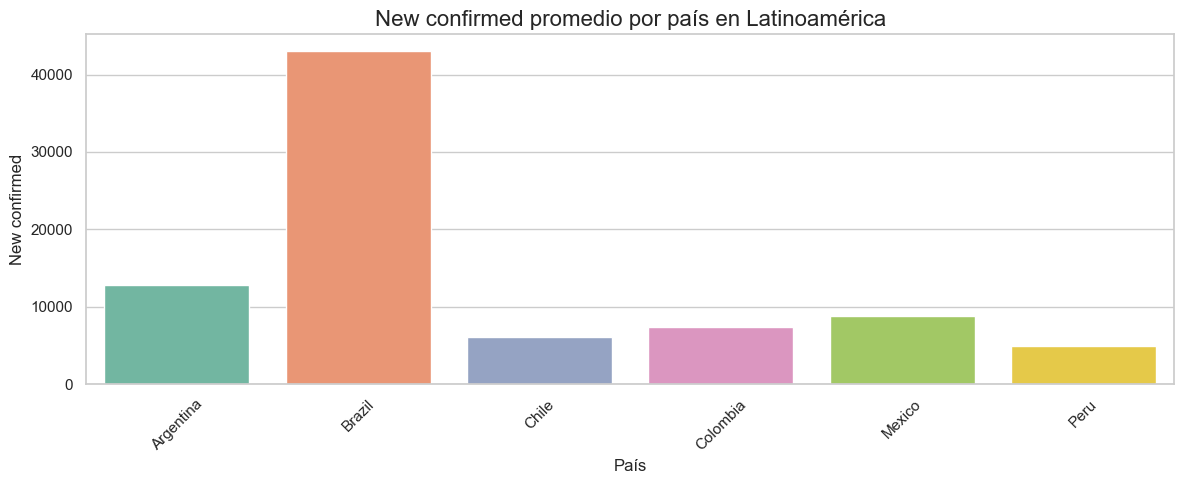

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


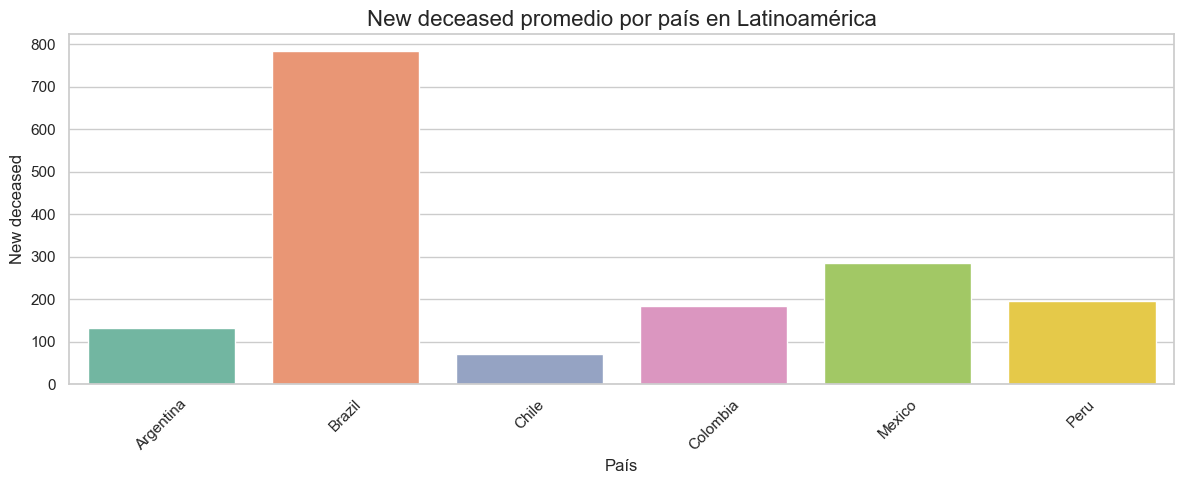

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


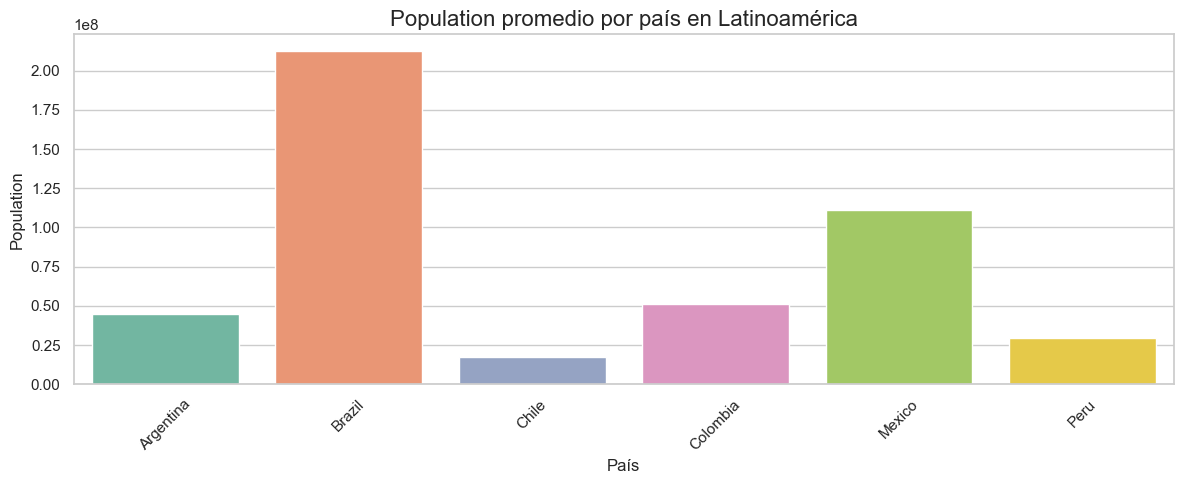

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


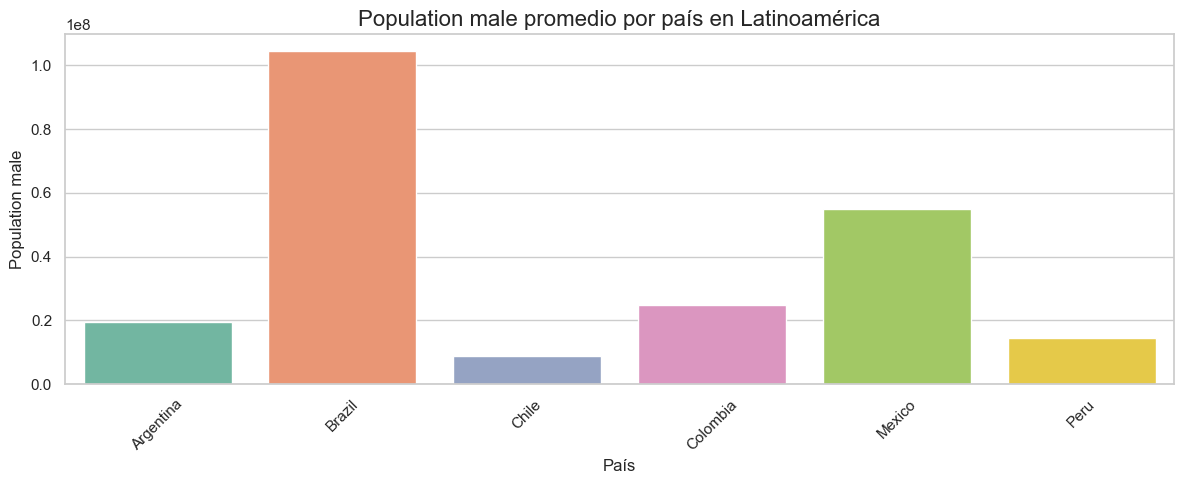

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


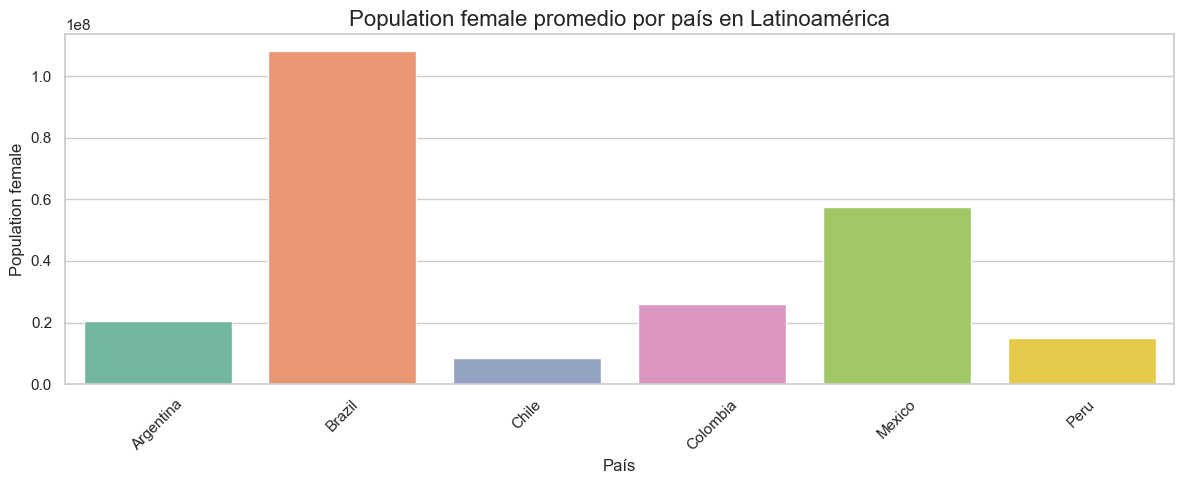

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


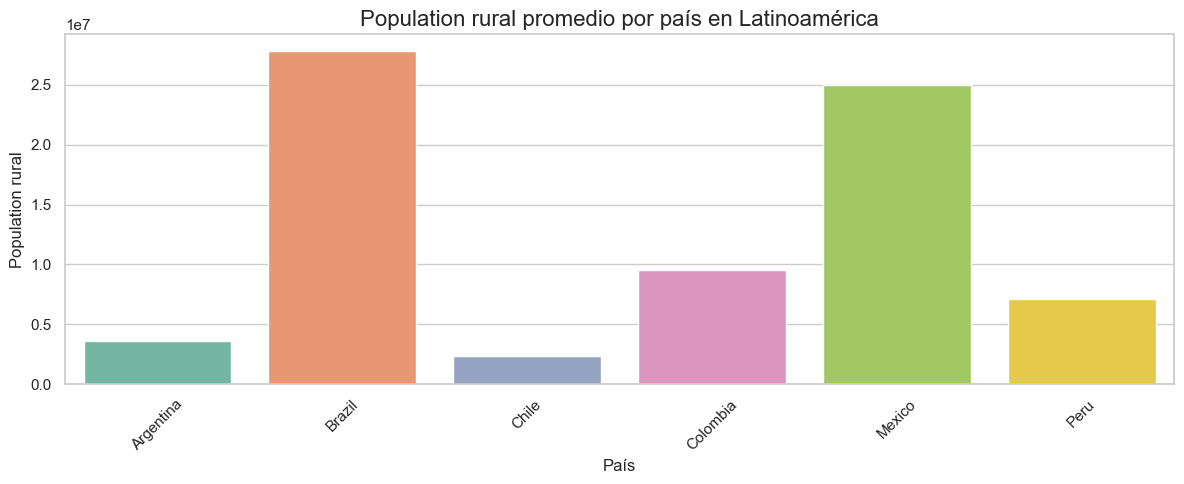

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


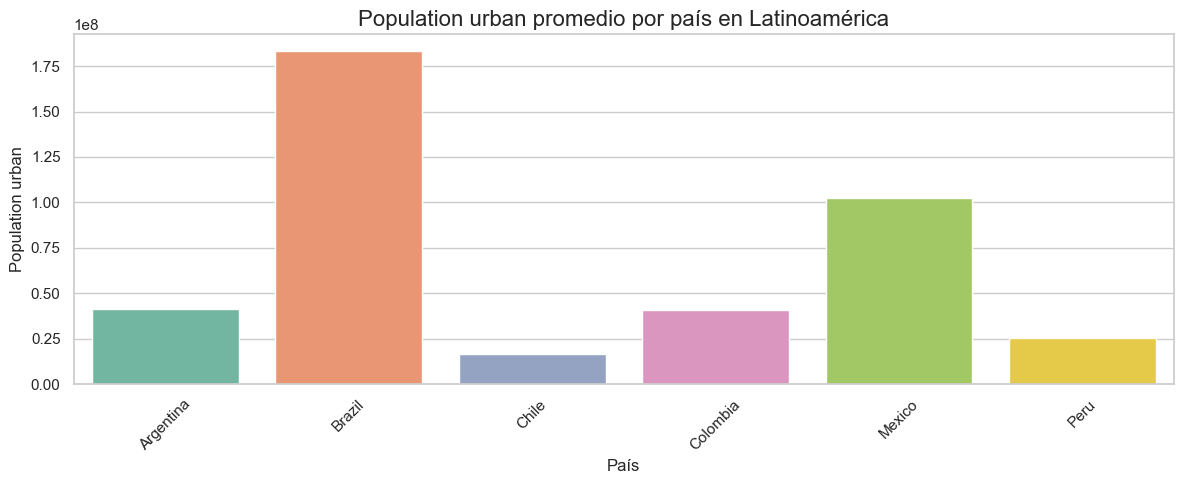

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


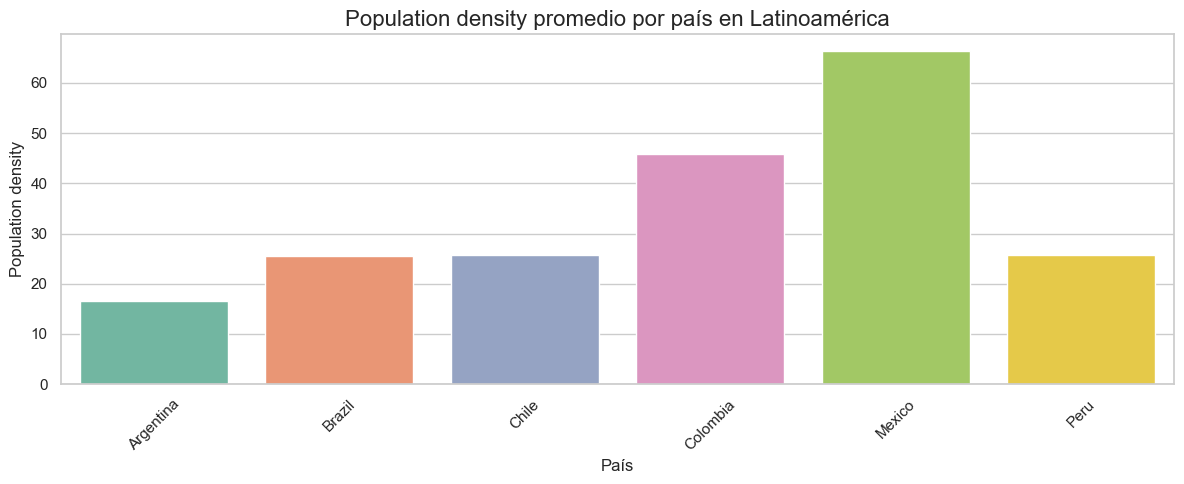

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


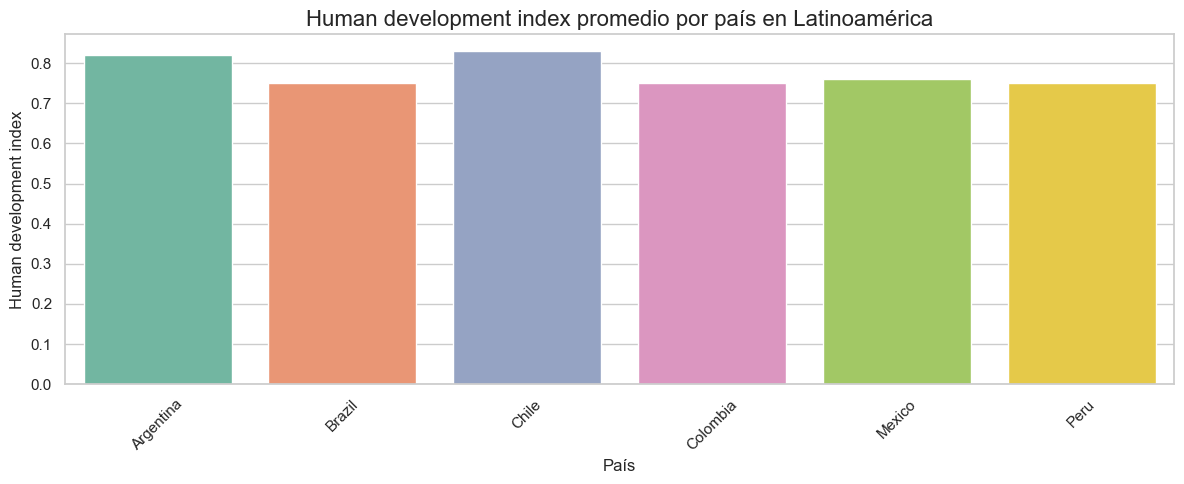

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


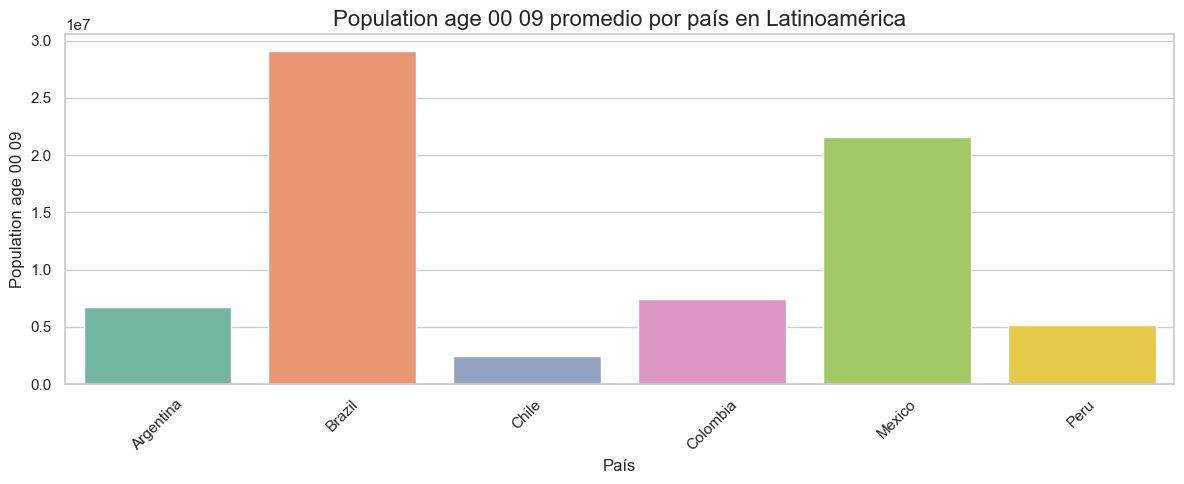

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


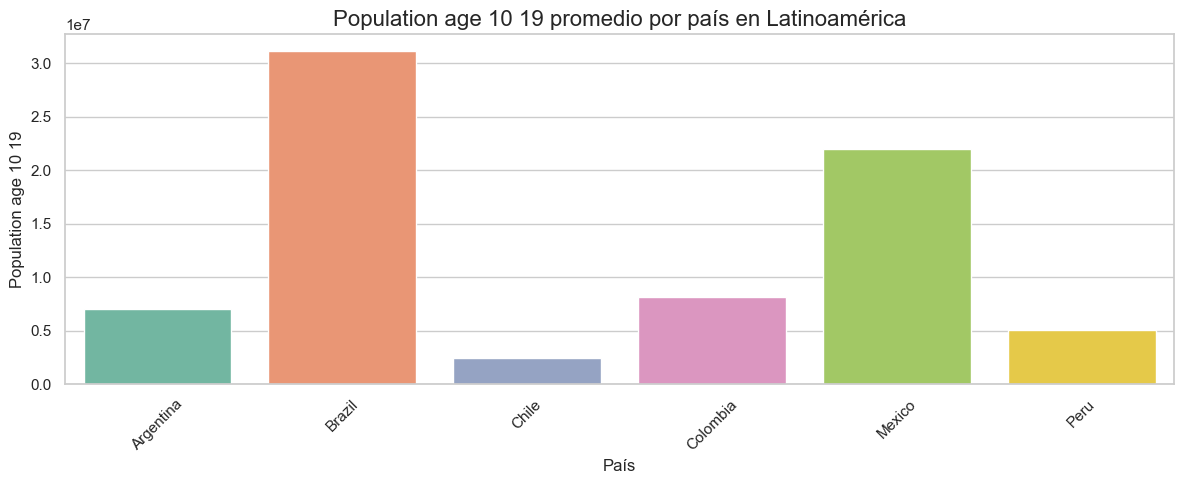

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


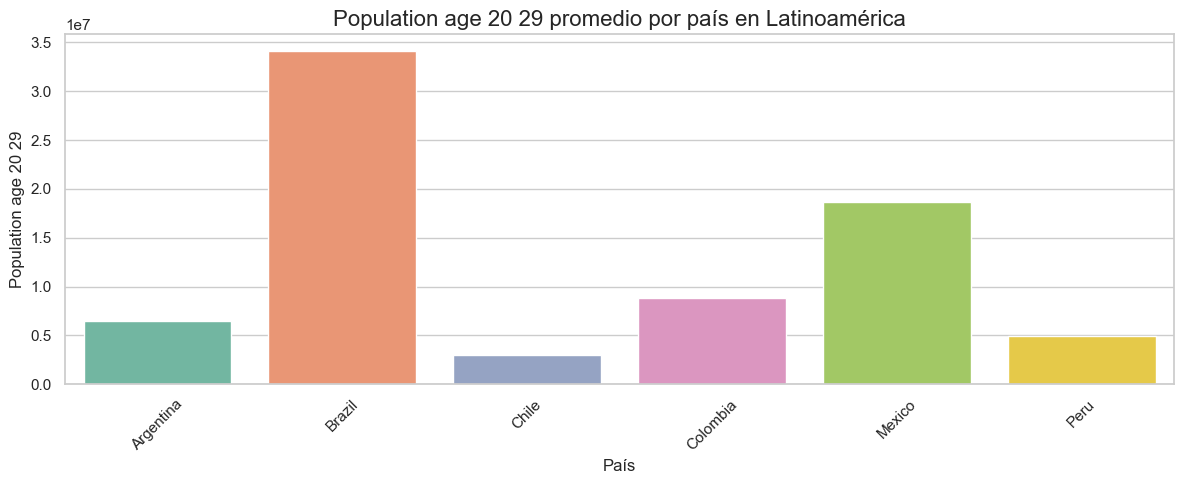

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


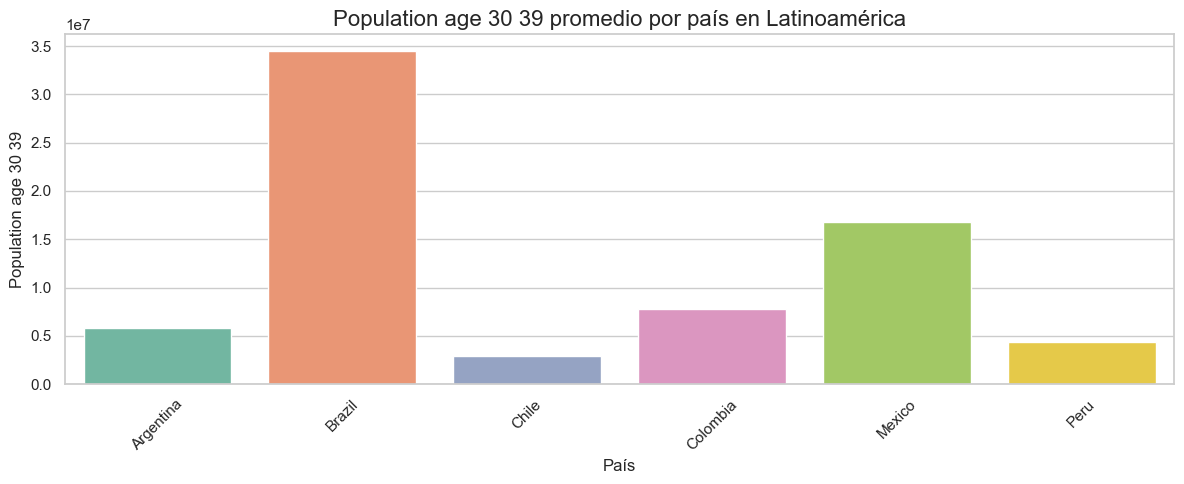

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


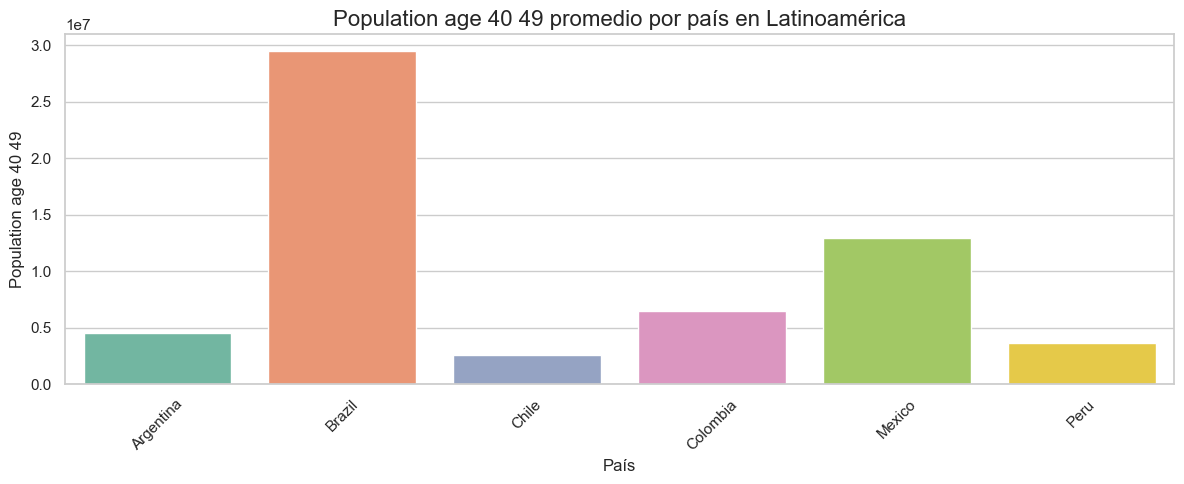

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


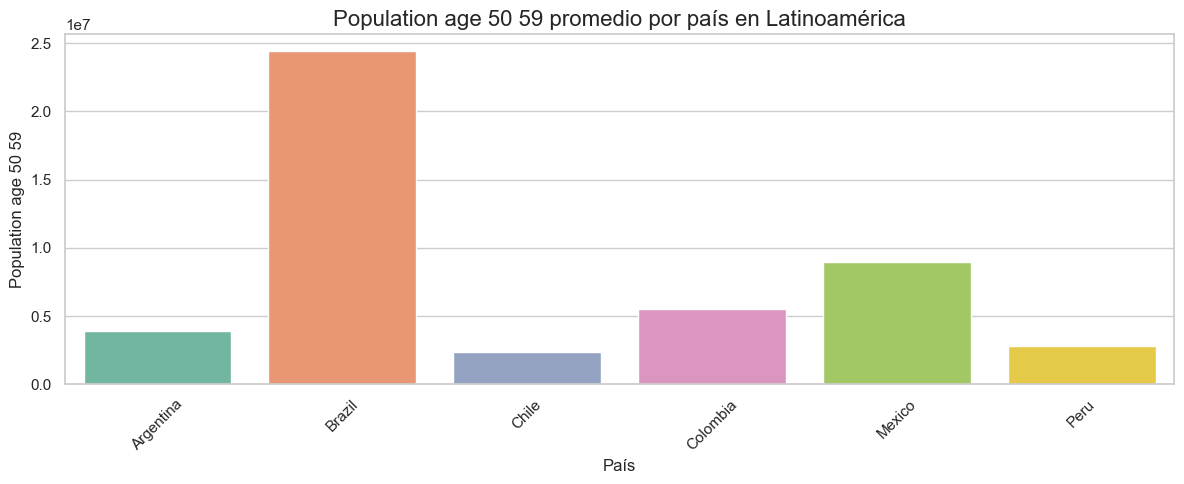

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


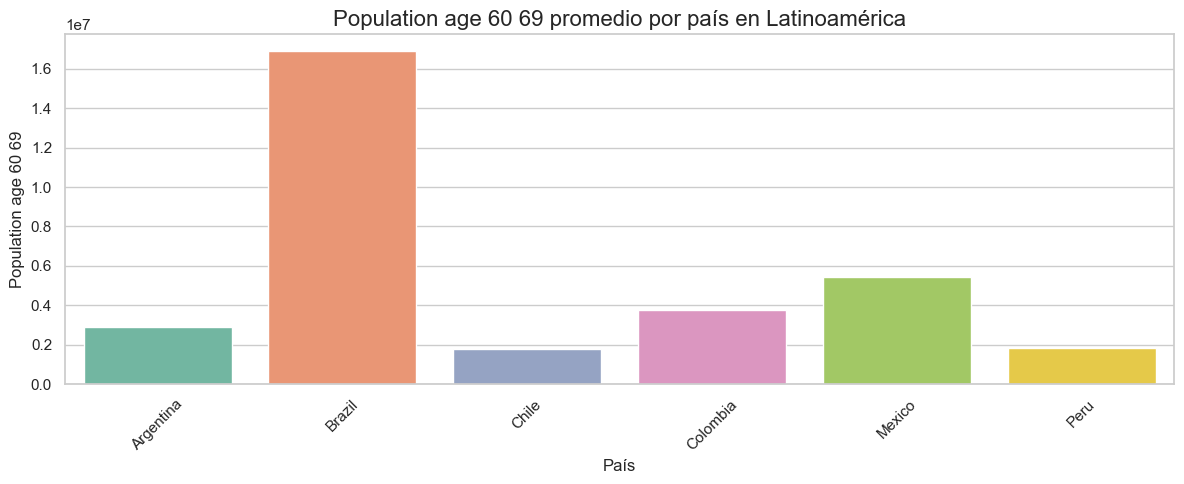

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


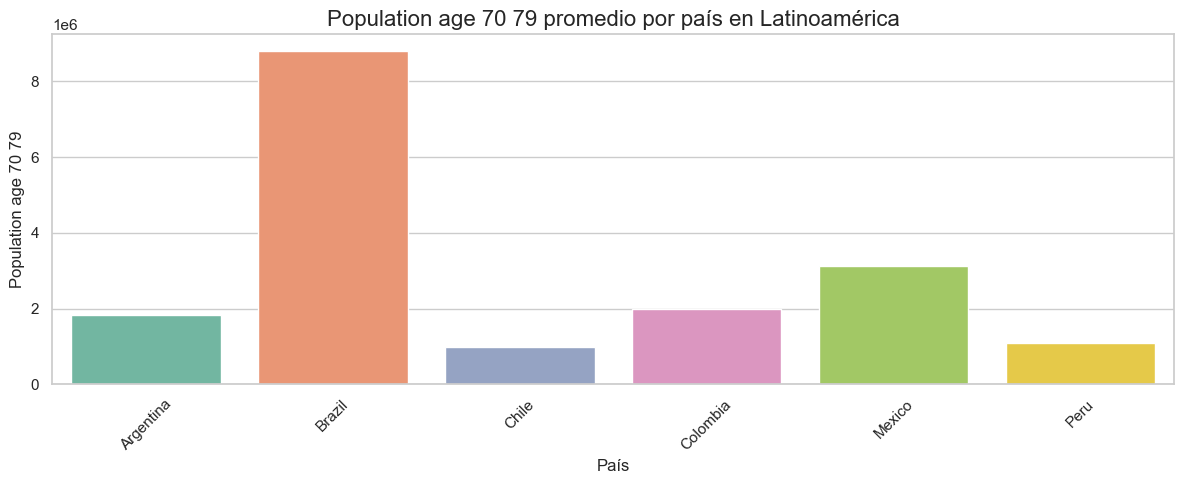

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


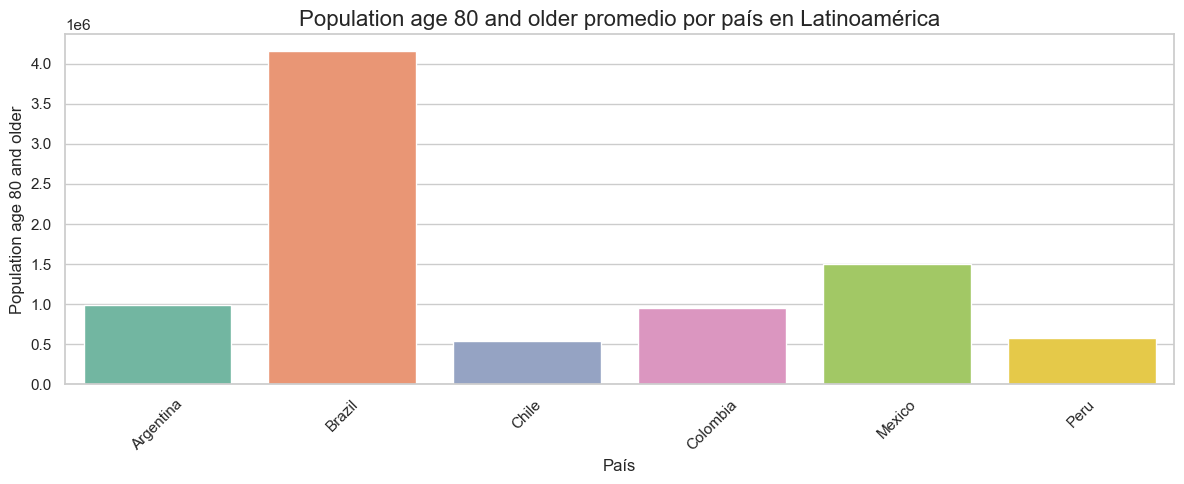

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


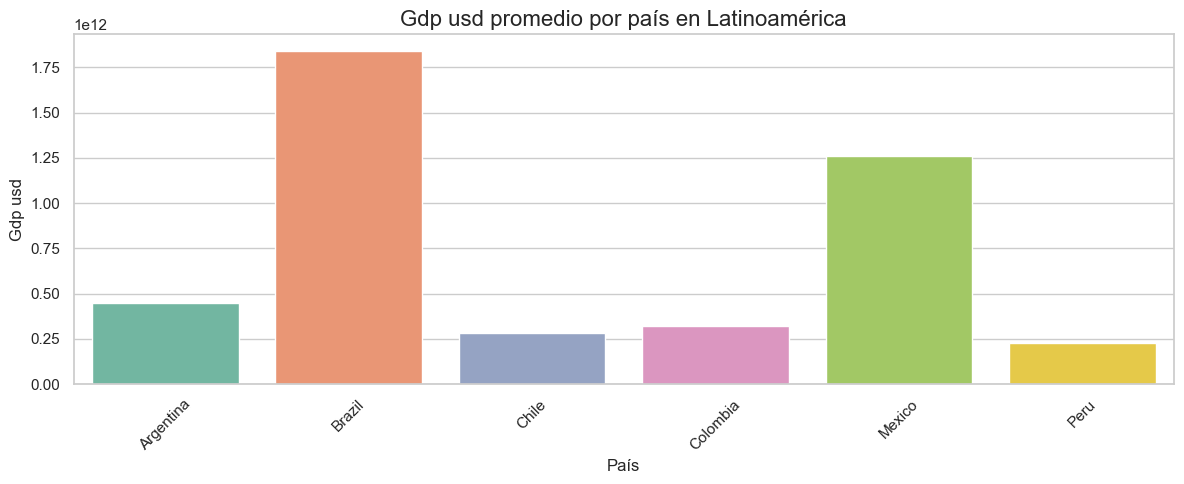

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


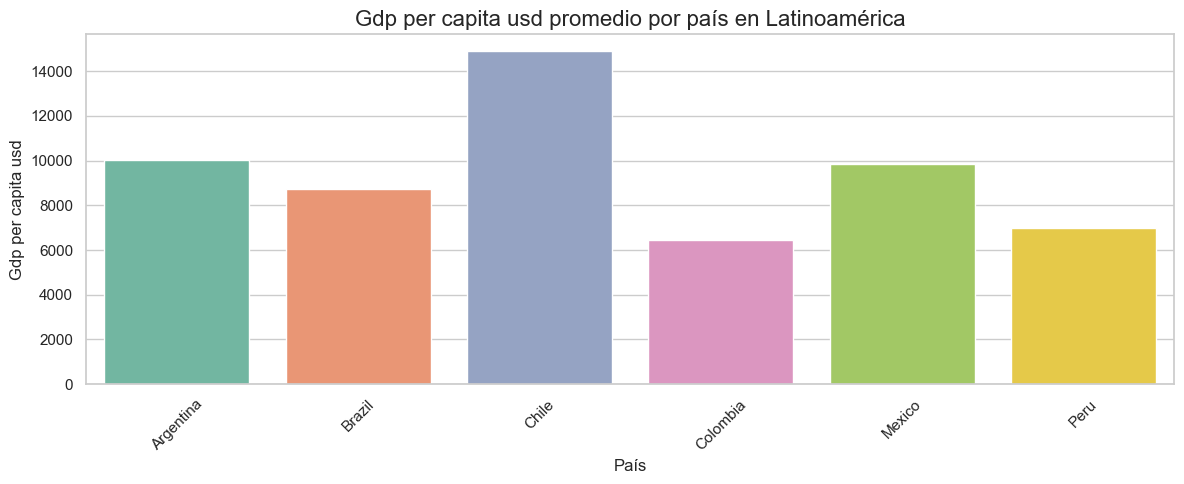

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


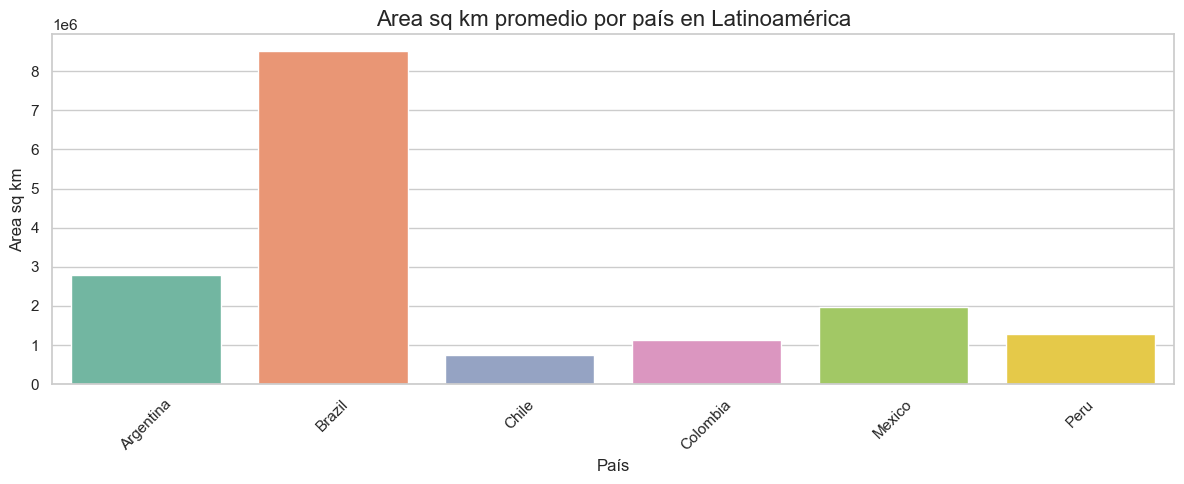

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


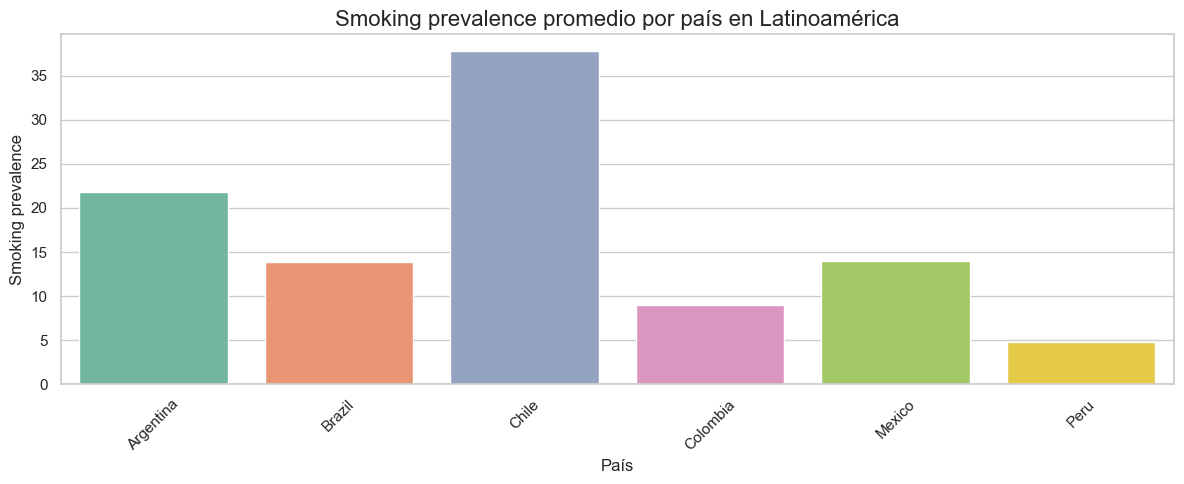

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


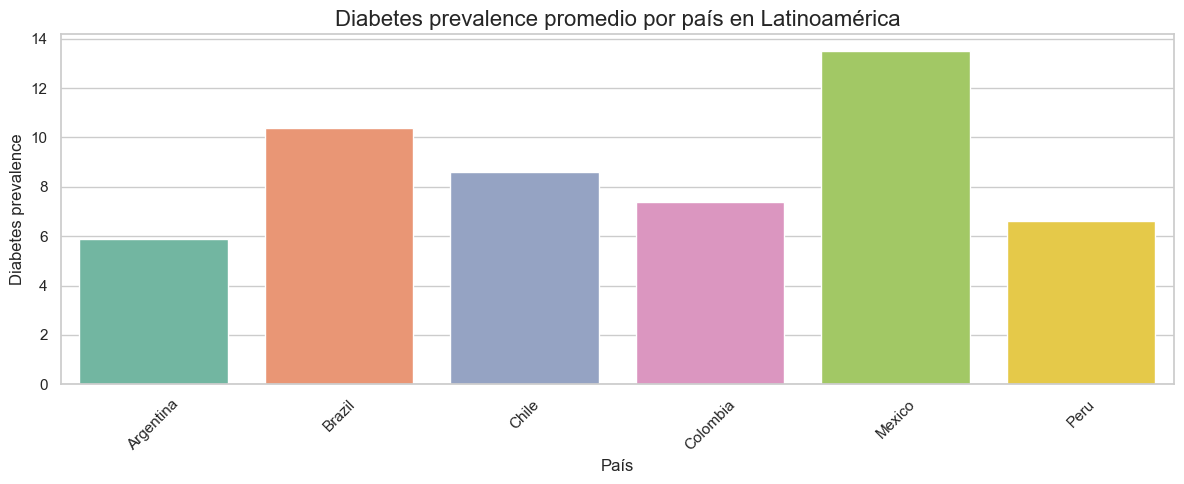

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


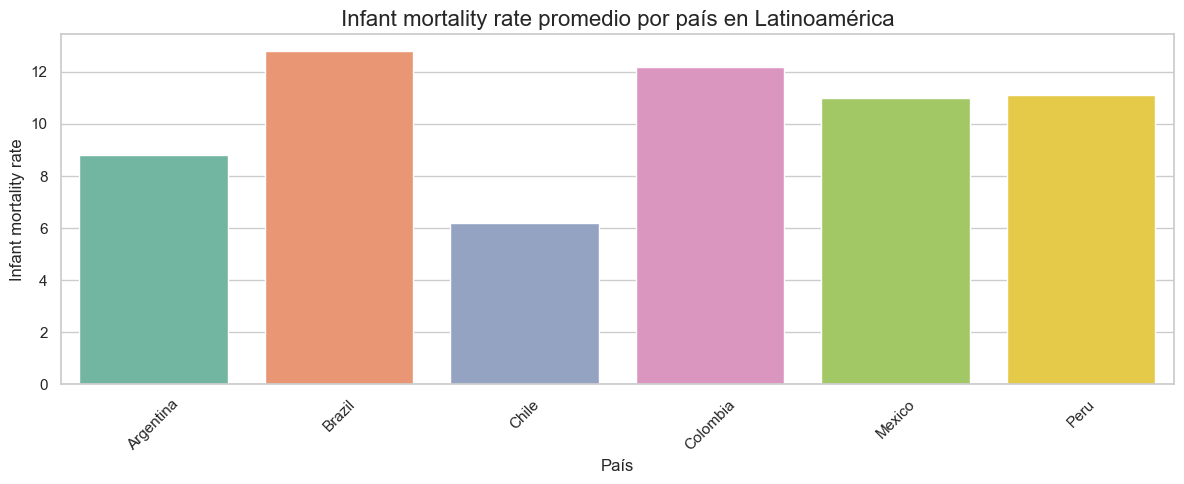

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


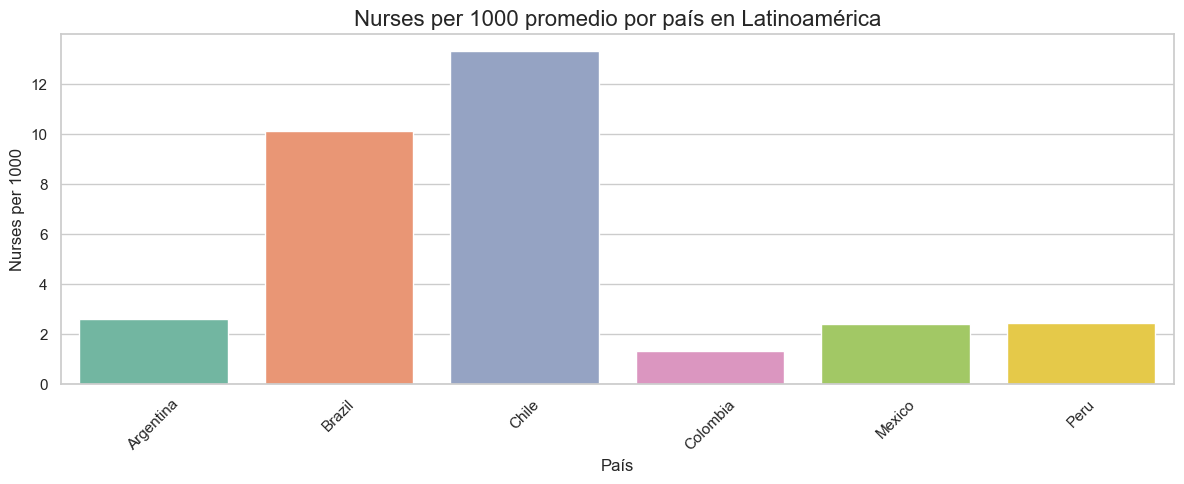

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


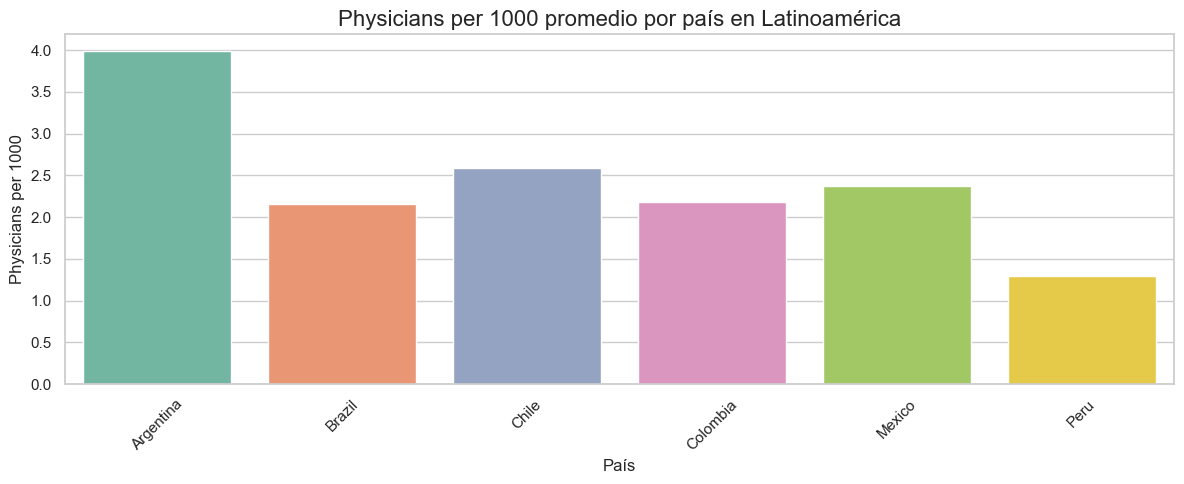

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


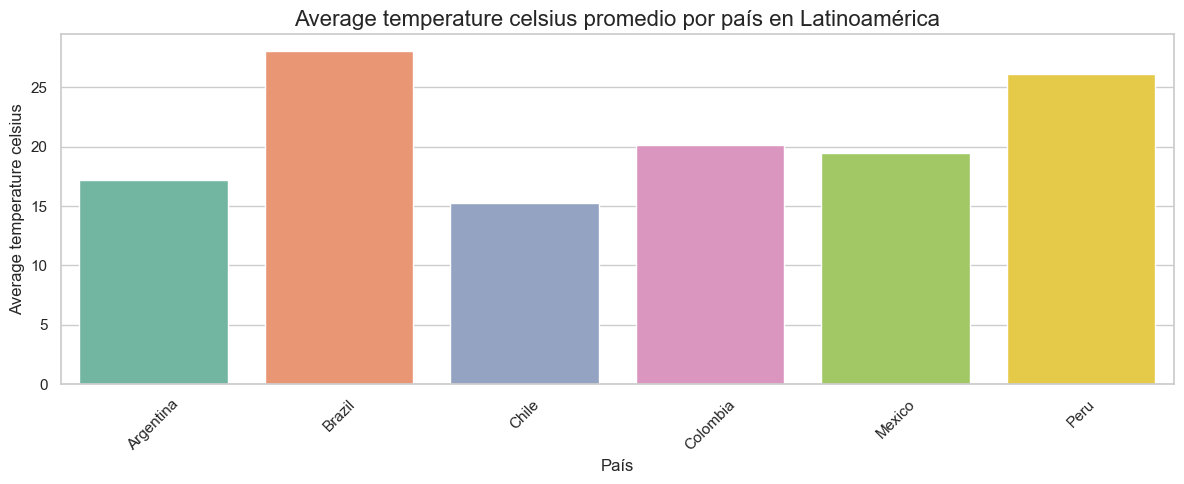

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


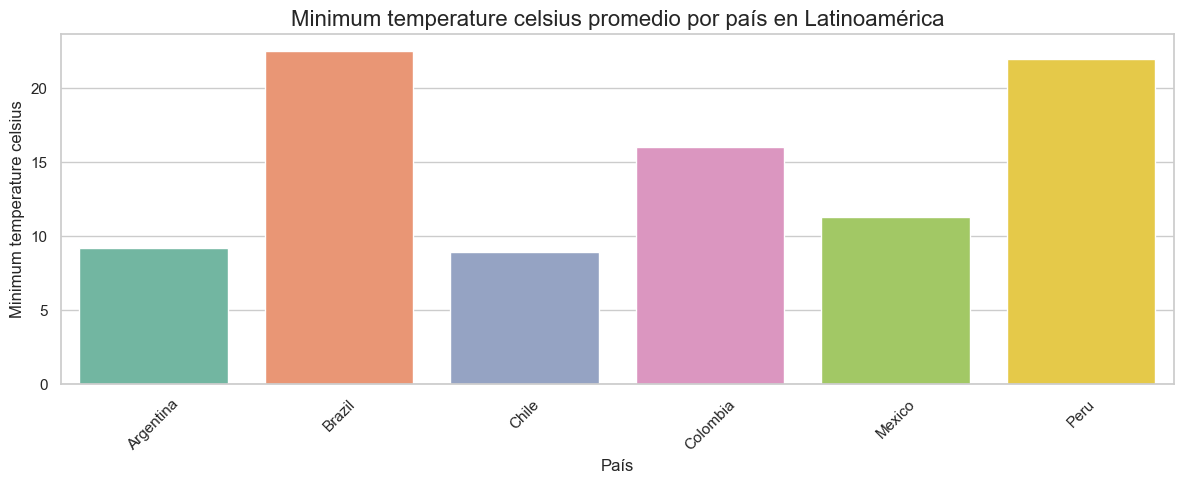

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


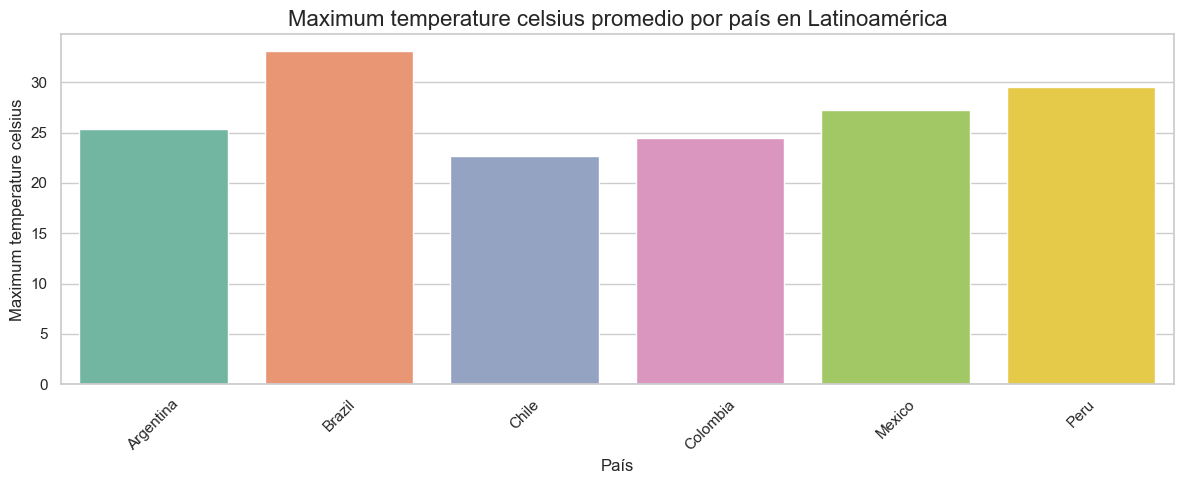

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


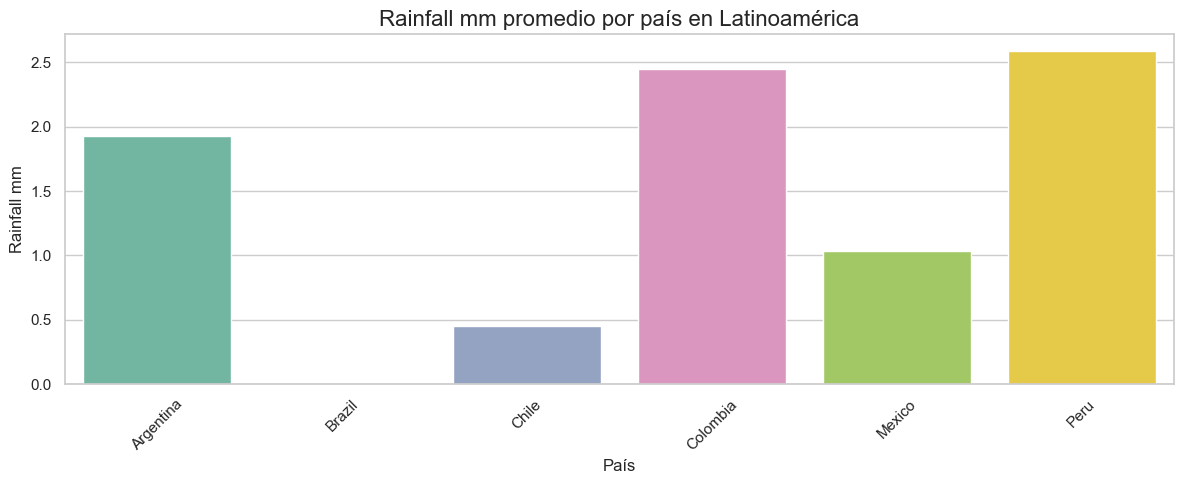

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


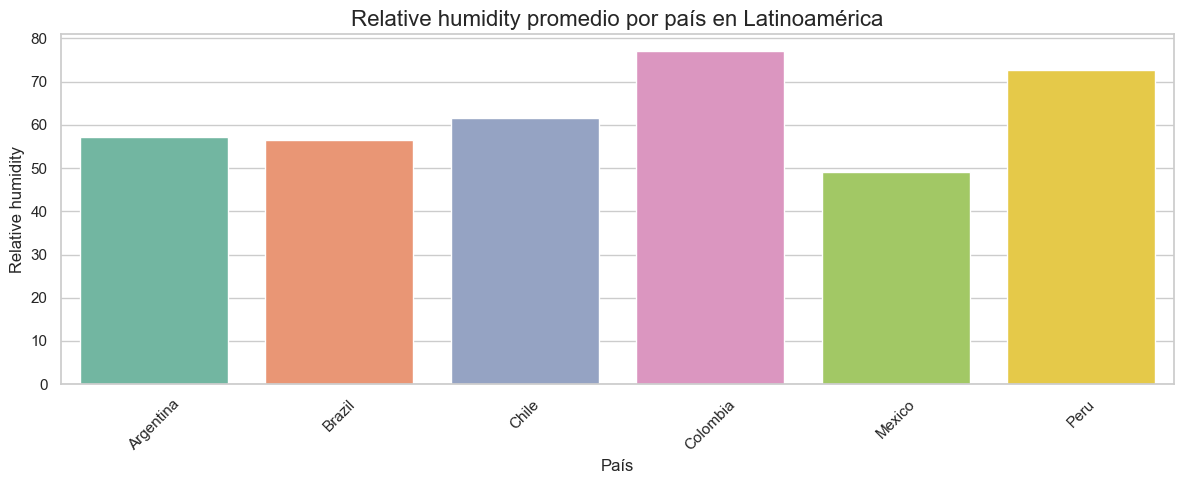

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


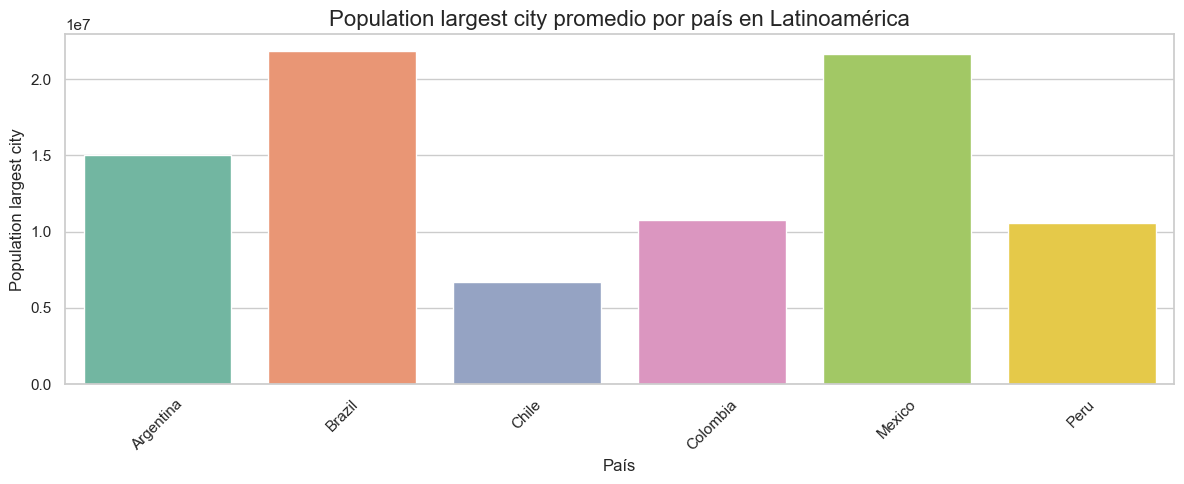

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


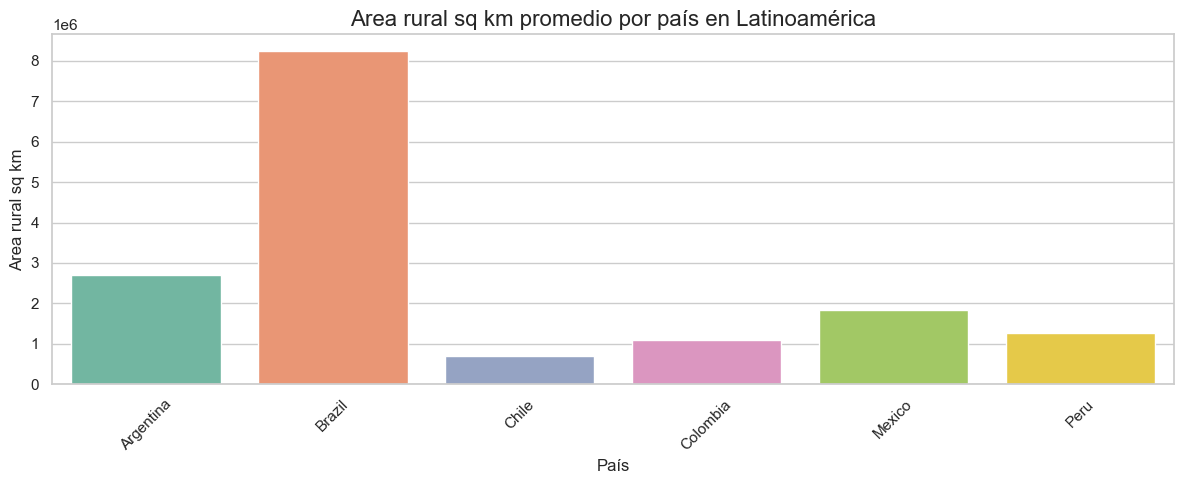

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


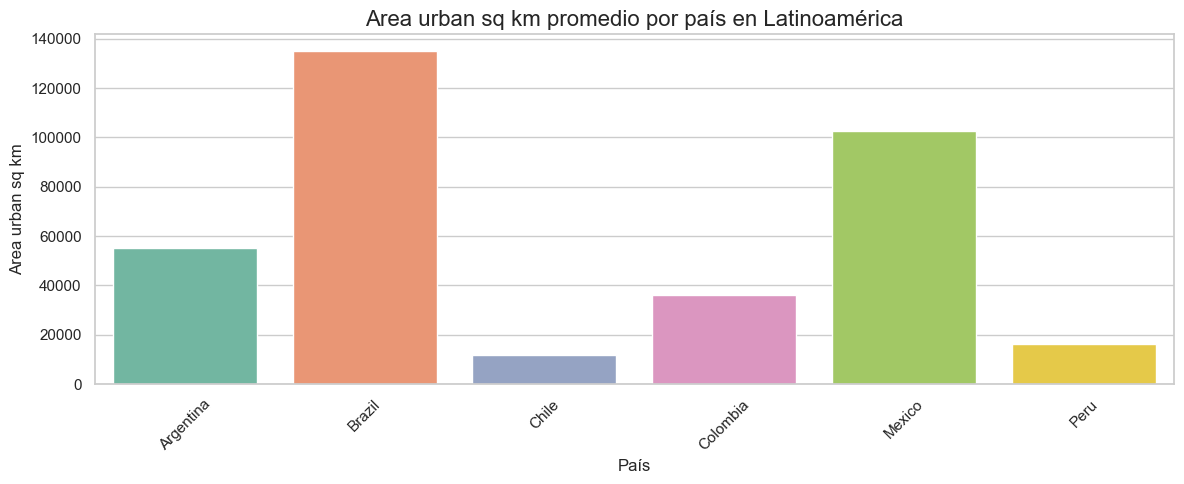

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


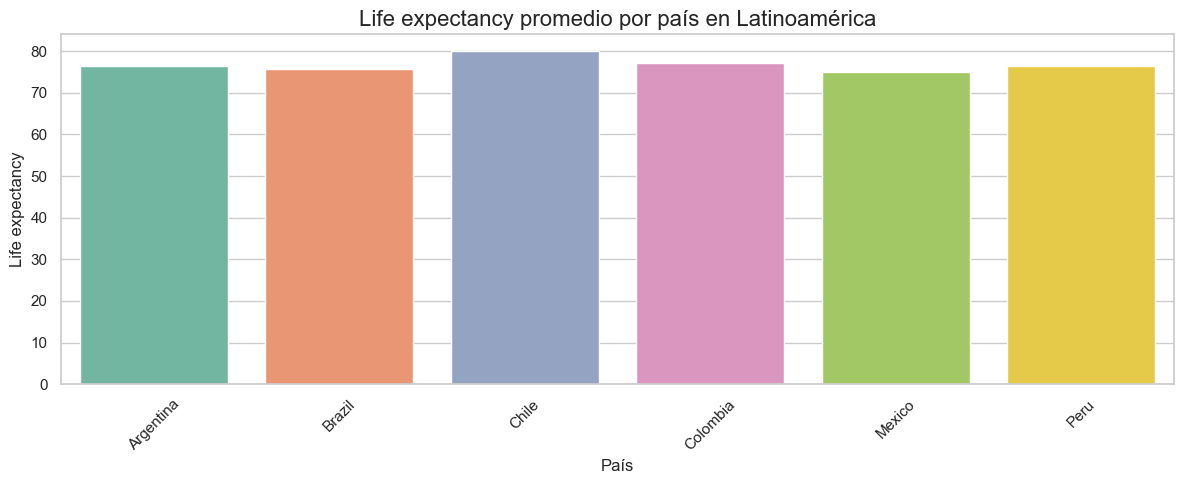

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


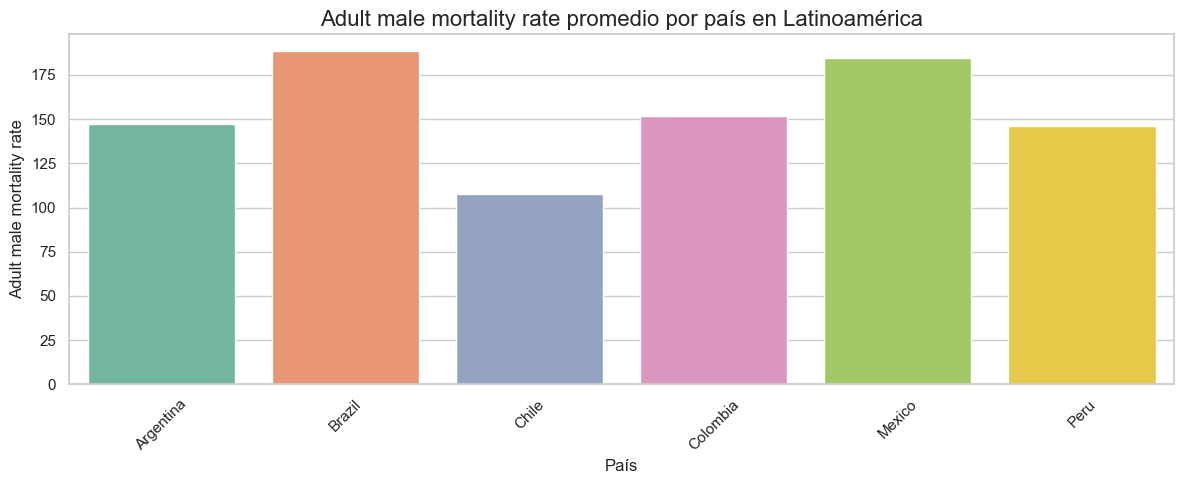

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


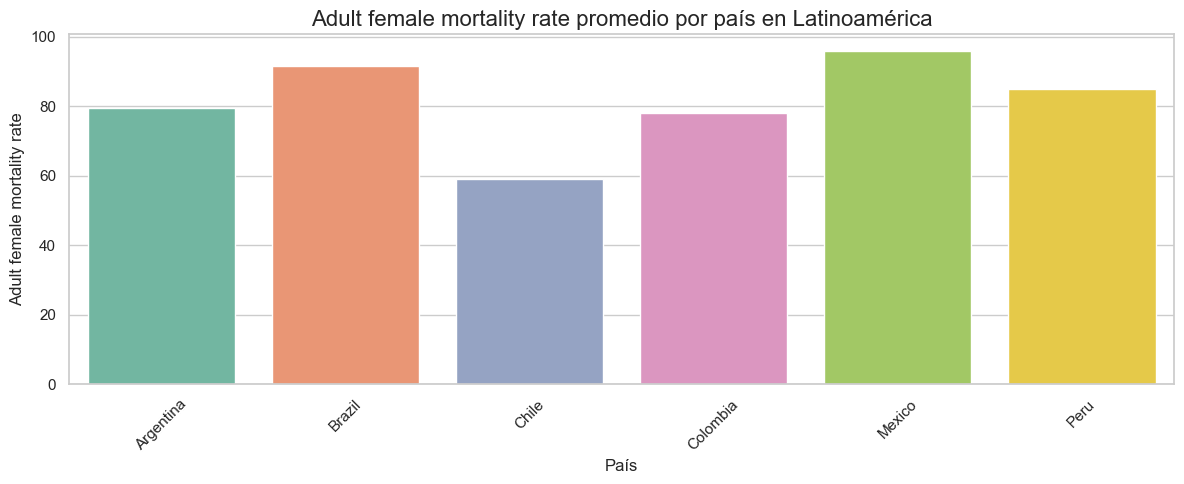

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


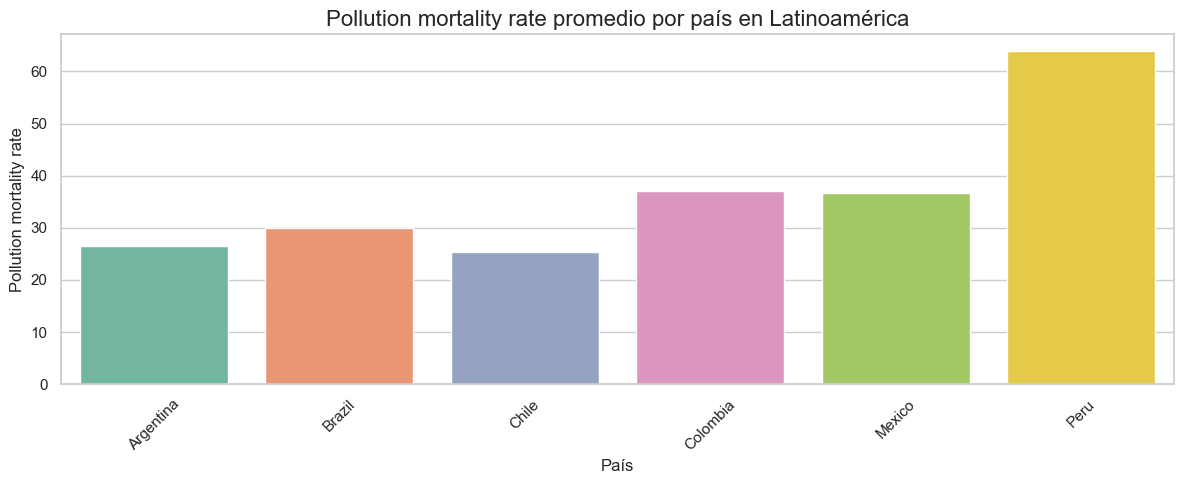

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3282469834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')


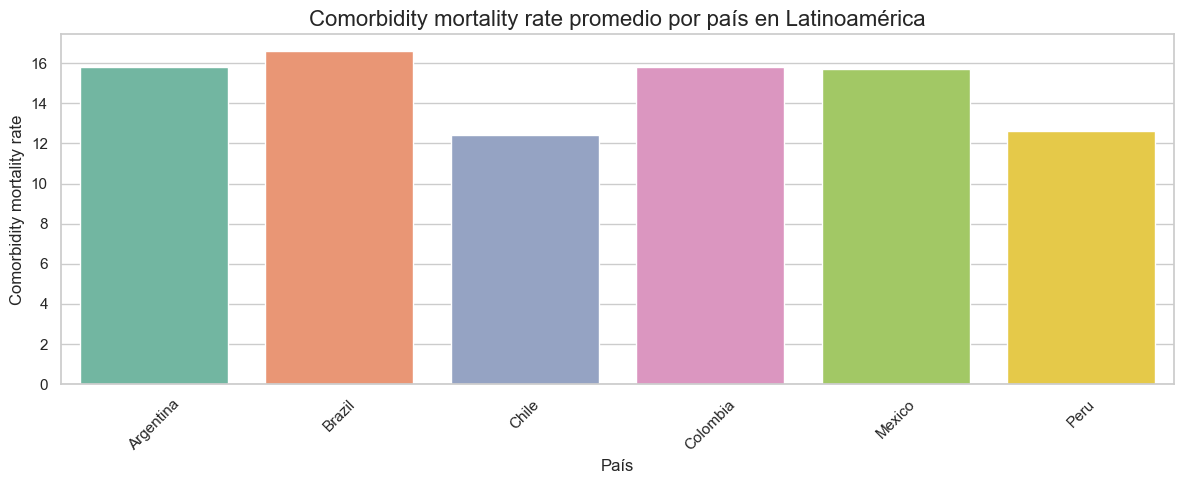

In [46]:
# Campos que no deseamos graficar
campos_excluidos = [
    'date', 'country_name', 'latitude', 'longitude', 
    'cumulative_confirmed', 'cumulative_deceased', 
    'cumulative_recovered', 'cumulative_vaccine_doses_administered', 
    'new_recovered'
]

# Estilo general
sns.set_theme(style="whitegrid")

# Iteramos solo por columnas que no están excluidas y que sean numéricas
for columna in df_datos_finales_filtrado.columns:
    if columna not in campos_excluidos and pd.api.types.is_numeric_dtype(df_datos_finales_filtrado[columna]):
        # Agrupamos por país y calculamos el promedio
        datos_agrupados = df_datos_finales_filtrado.groupby('country_name')[columna].mean().reset_index()

        # Gráfico
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=datos_agrupados, x='country_name', y=columna, palette='Set2', ax=ax) #hue = 'country_name')
        ax.set_title(f'{columna.replace("_", " ").capitalize()} promedio por país en Latinoamérica', fontsize=16)
        ax.set_xlabel('País')
        ax.set_ylabel(columna.replace("_", " ").capitalize())
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


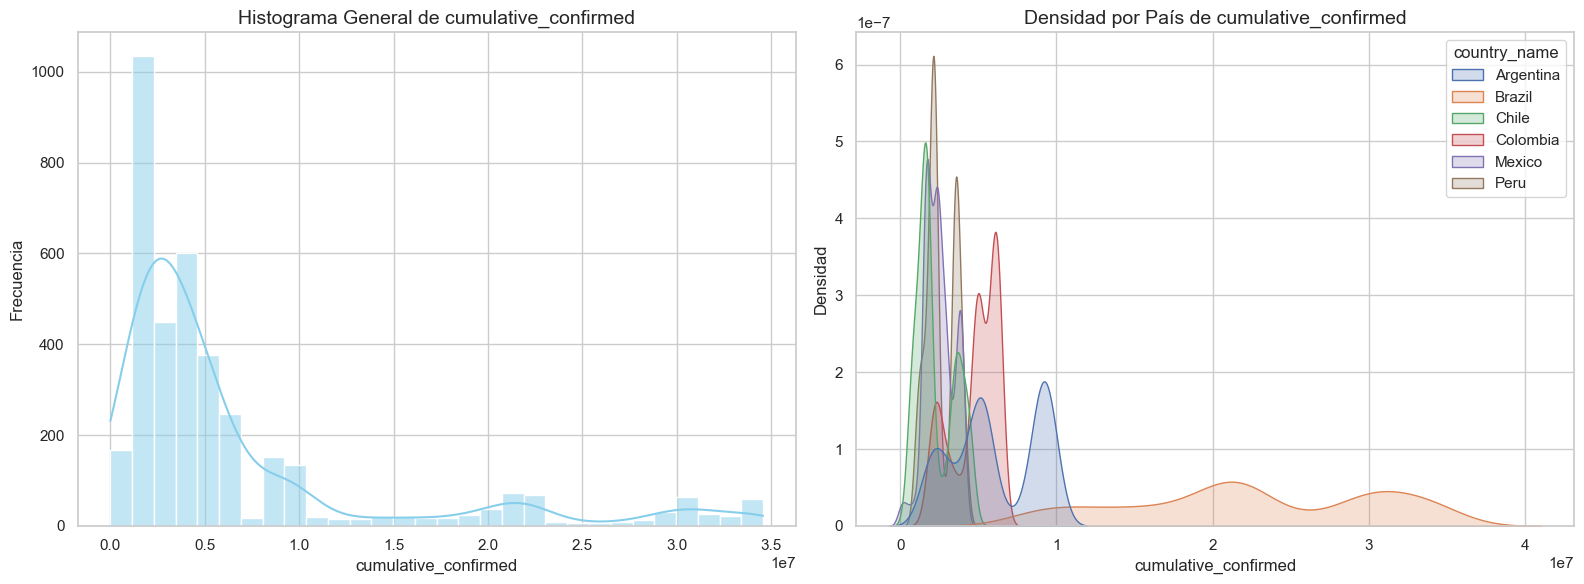

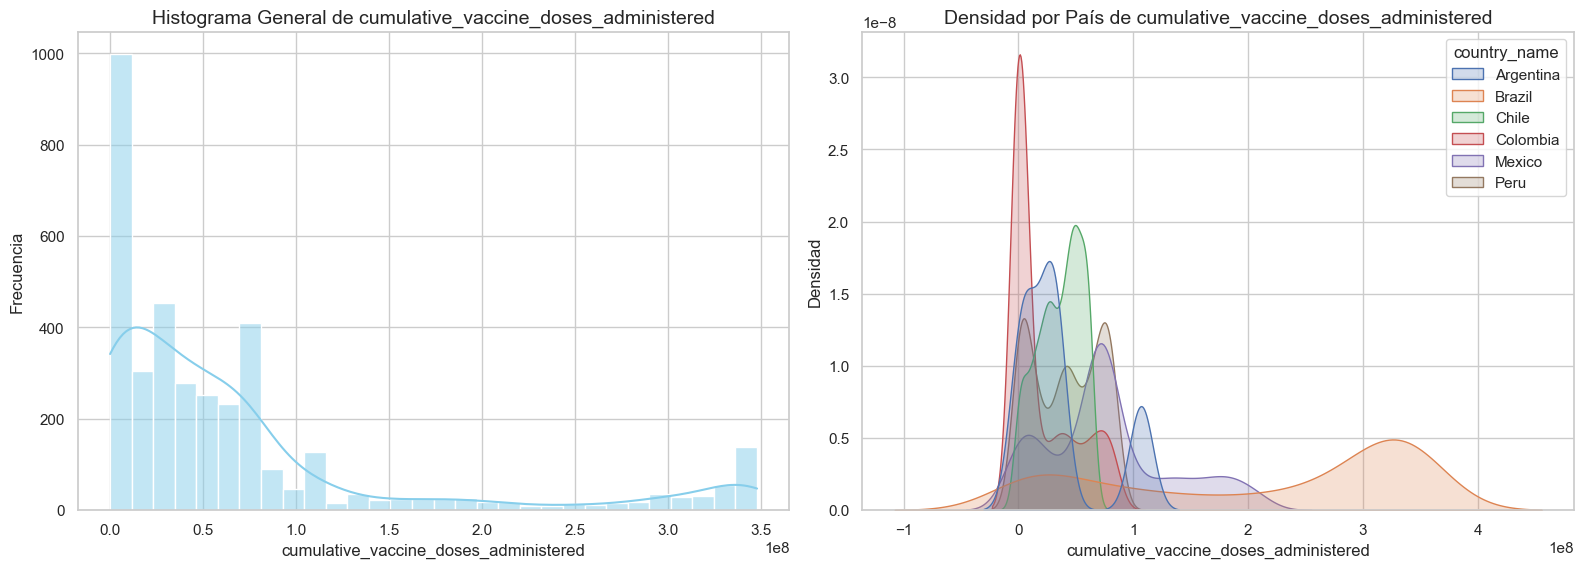

In [47]:
# Variables de interés
variables = ['cumulative_confirmed', 'cumulative_vaccine_doses_administered']
nombres = ['cumulative_confirmed', 'cumulative_vaccine_doses_administered']

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Visualización general y por país
for var, nombre in zip(variables, nombres):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histograma general
    sns.histplot(df_datos_finales_filtrado[var].dropna(), kde=True, ax=axes[0], bins=30, color='skyblue')
    axes[0].set_title(f'Histograma General de {nombre}', fontsize=14)
    axes[0].set_xlabel(nombre)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de densidad por país
    sns.kdeplot(data=df_datos_finales_filtrado, x=var, hue="country_name", ax=axes[1], fill=True, common_norm=False)
    axes[1].set_title(f'Densidad por País de {nombre}', fontsize=14)
    axes[1].set_xlabel(nombre)
    axes[1].set_ylabel('Densidad')

    plt.tight_layout()
    plt.show()


C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


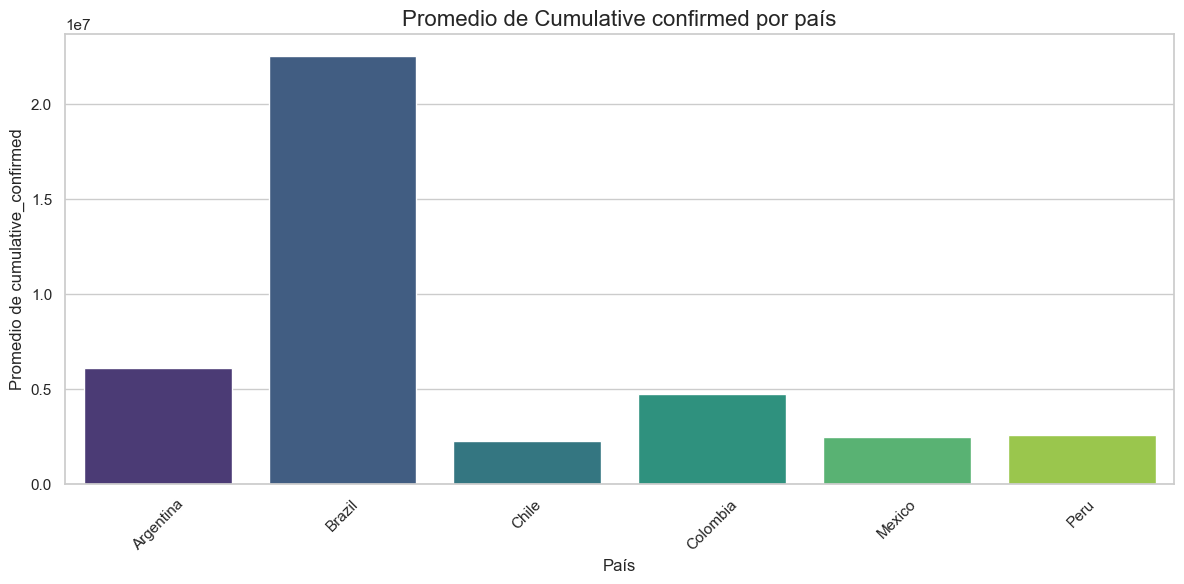

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


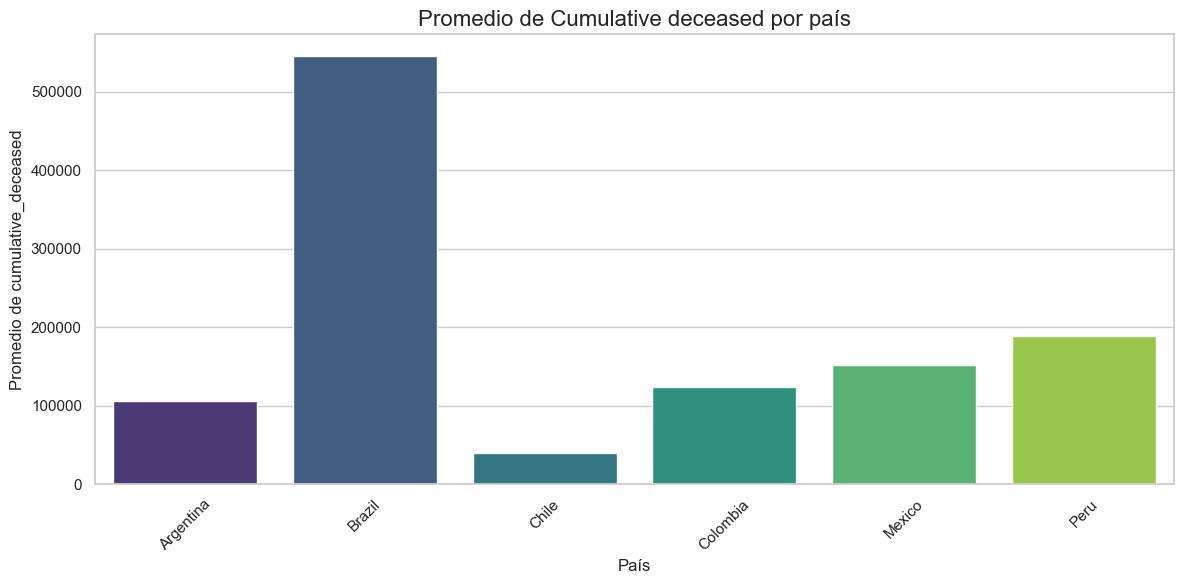

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


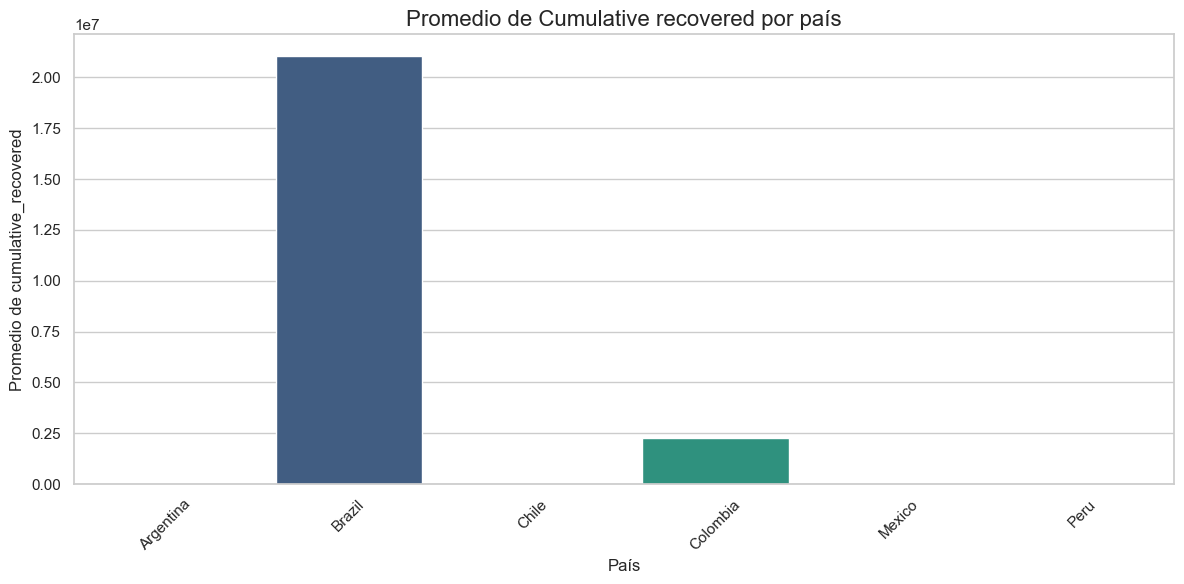

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


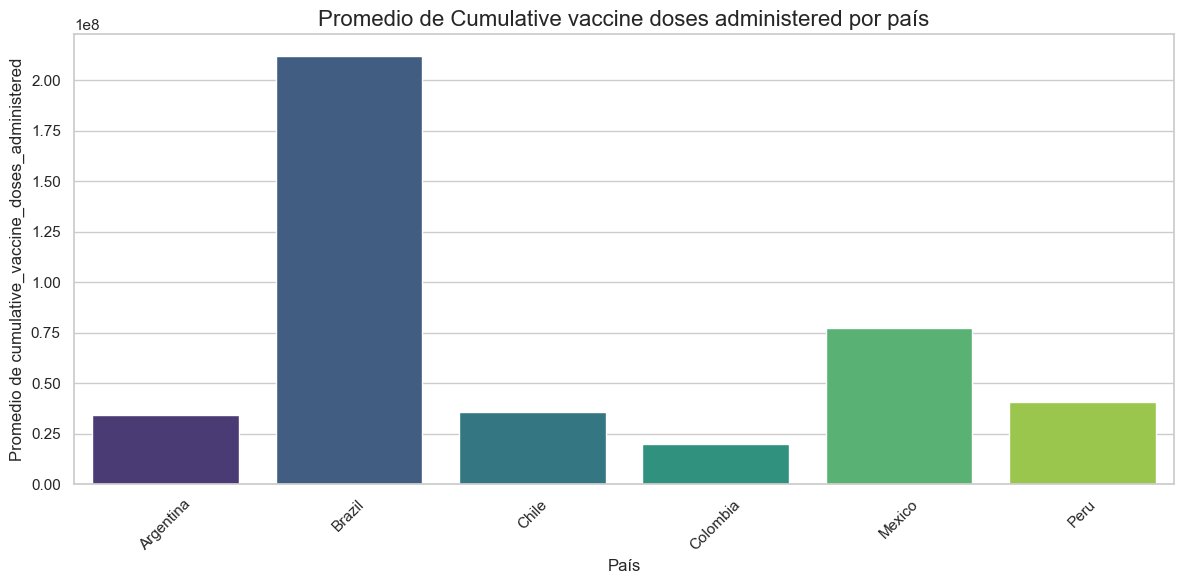

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3431492587.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


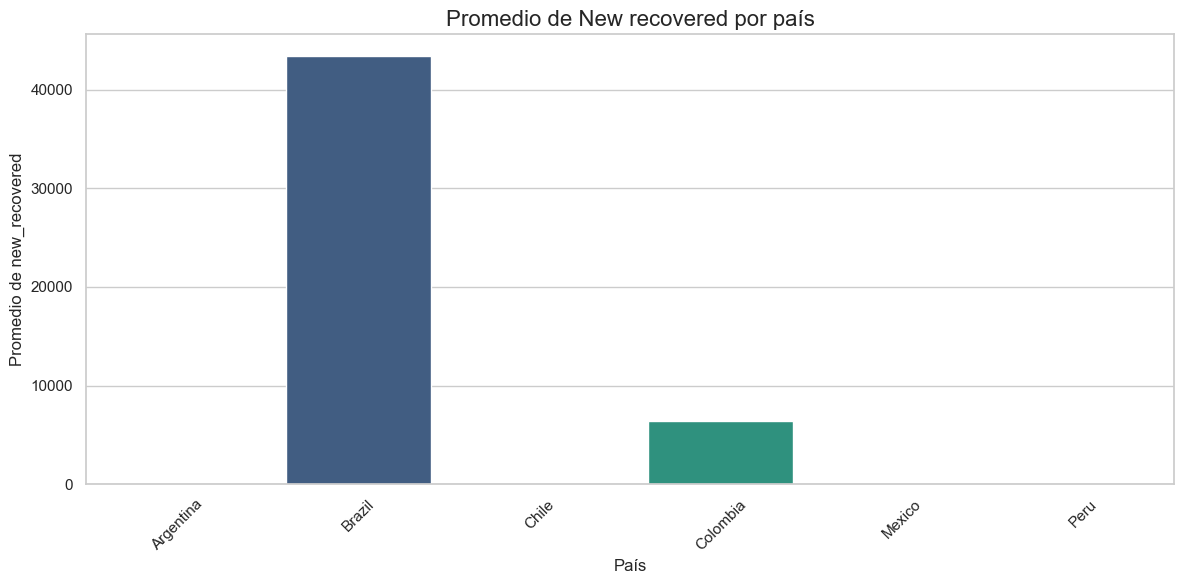

In [48]:
# Variables que queremos comparar por país
variables_comparar = [
    'cumulative_confirmed',
    'cumulative_deceased',
    'cumulative_recovered',
    'cumulative_vaccine_doses_administered',
    'new_recovered'
]

# Crear gráficos de barra sin incluir datos faltantes
for variable in variables_comparar:
    # Eliminar filas con NaN en la variable actual
    df_filtrado_variable = df_datos_finales_filtrado.dropna(subset=[variable])

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_filtrado_variable,
        x='country_name',
        y=variable,
        estimator='mean',
        ci=None,
        palette='viridis'
    )
    plt.title(f'Promedio de {variable.replace("_", " ").capitalize()} por país', fontsize=16)
    plt.xlabel('País')
    plt.ylabel(f'Promedio de {variable}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


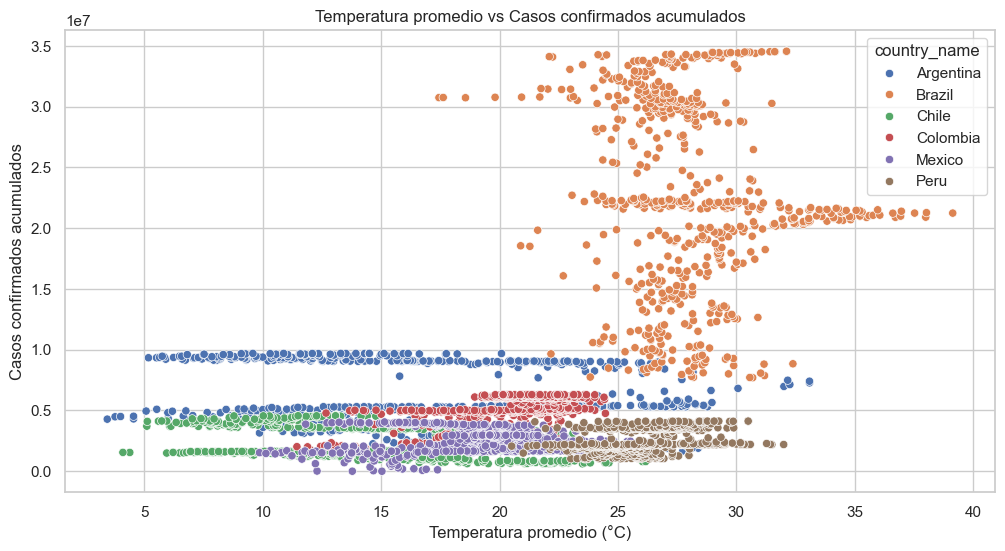

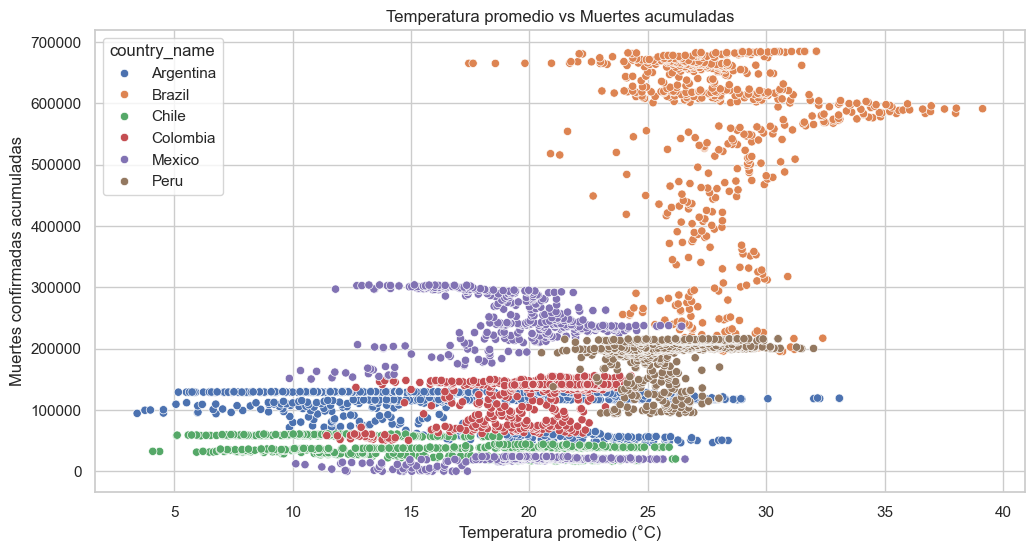

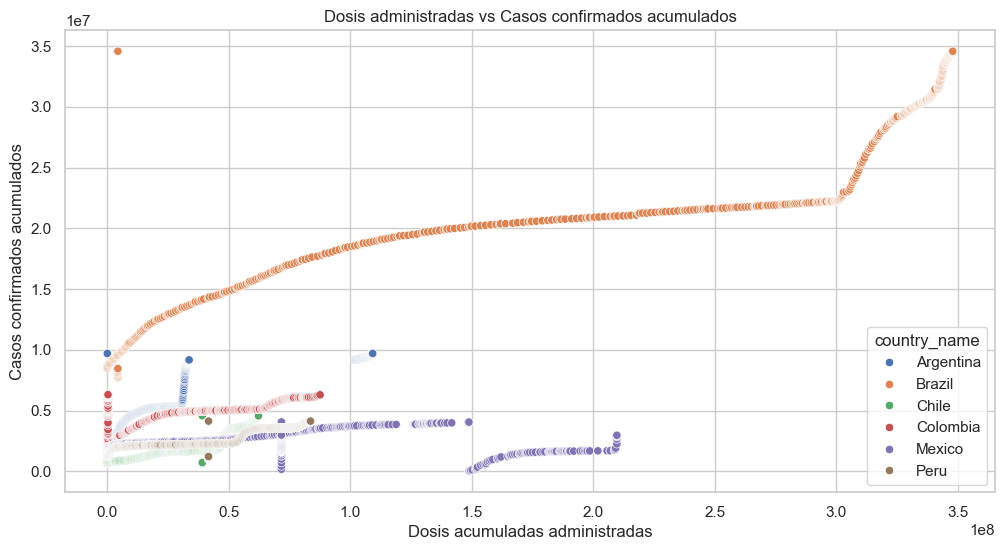

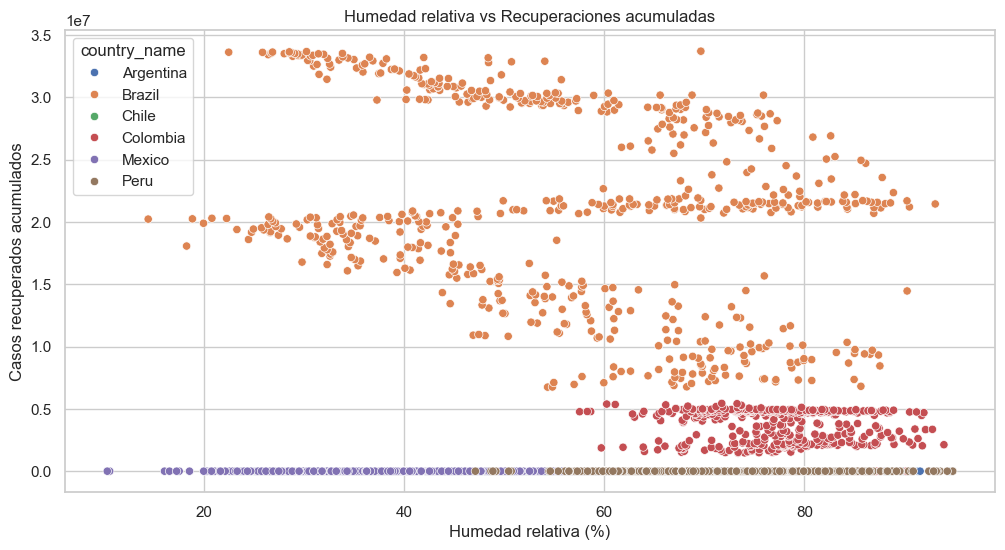

In [49]:
# Configuración de estilo general
sns.set(style="whitegrid")

# 1. Temperatura promedio vs Casos confirmados
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_datos_finales_filtrado, x='average_temperature_celsius', y='cumulative_confirmed', hue='country_name')
plt.title('Temperatura promedio vs Casos confirmados acumulados')
plt.xlabel('Temperatura promedio (°C)')
plt.ylabel('Casos confirmados acumulados')
plt.grid(True)
plt.show()

# 2. Temperatura promedio vs Muertes acumuladas
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_datos_finales_filtrado, x='average_temperature_celsius', y='cumulative_deceased', hue='country_name')
plt.title('Temperatura promedio vs Muertes acumuladas')
plt.xlabel('Temperatura promedio (°C)')
plt.ylabel('Muertes confirmadas acumuladas')
plt.grid(True)
plt.show()

# 3. Dosis administradas vs Casos confirmados
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_datos_finales_filtrado, x='cumulative_vaccine_doses_administered', y='cumulative_confirmed', hue='country_name')
plt.title('Dosis administradas vs Casos confirmados acumulados')
plt.xlabel('Dosis acumuladas administradas')
plt.ylabel('Casos confirmados acumulados')
plt.grid(True)
plt.show()

# 4. Humedad relativa vs Recuperaciones acumuladas
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_datos_finales_filtrado, x='relative_humidity', y='cumulative_recovered', hue='country_name')
plt.title('Humedad relativa vs Recuperaciones acumuladas')
plt.xlabel('Humedad relativa (%)')
plt.ylabel('Casos recuperados acumulados')
plt.grid(True)
plt.show()



C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3723180210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_datos_finales_filtrado, x='country_name', y='average_temperature_celsius', palette='viridis')


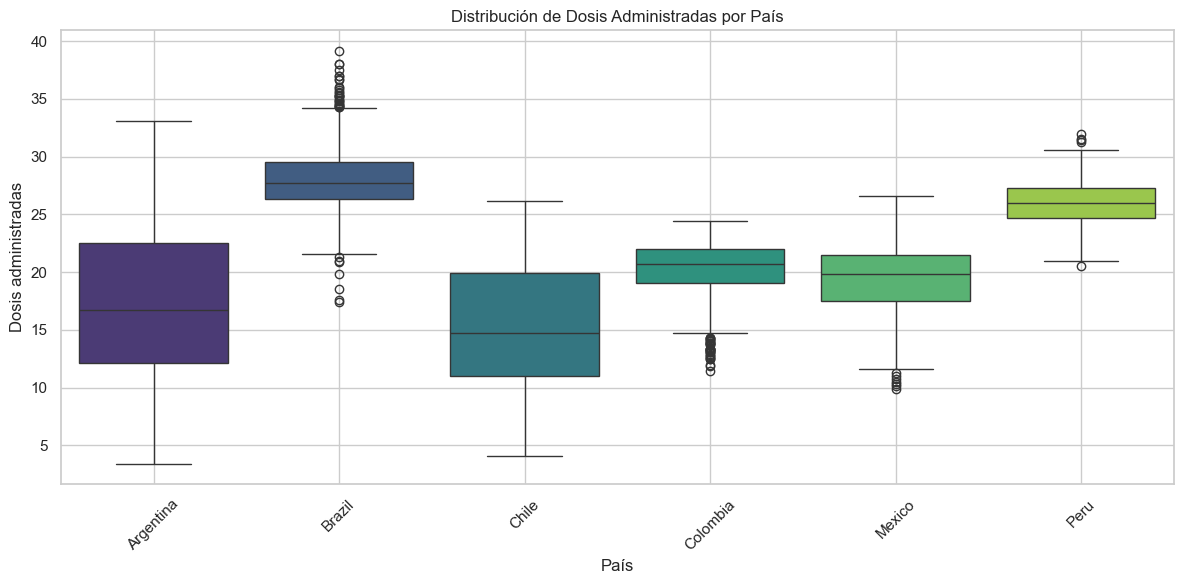

In [50]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_datos_finales_filtrado, x='country_name', y='average_temperature_celsius', palette='viridis')
plt.title('Distribución de Dosis Administradas por País')
plt.xlabel('País')
plt.ylabel('Dosis administradas')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

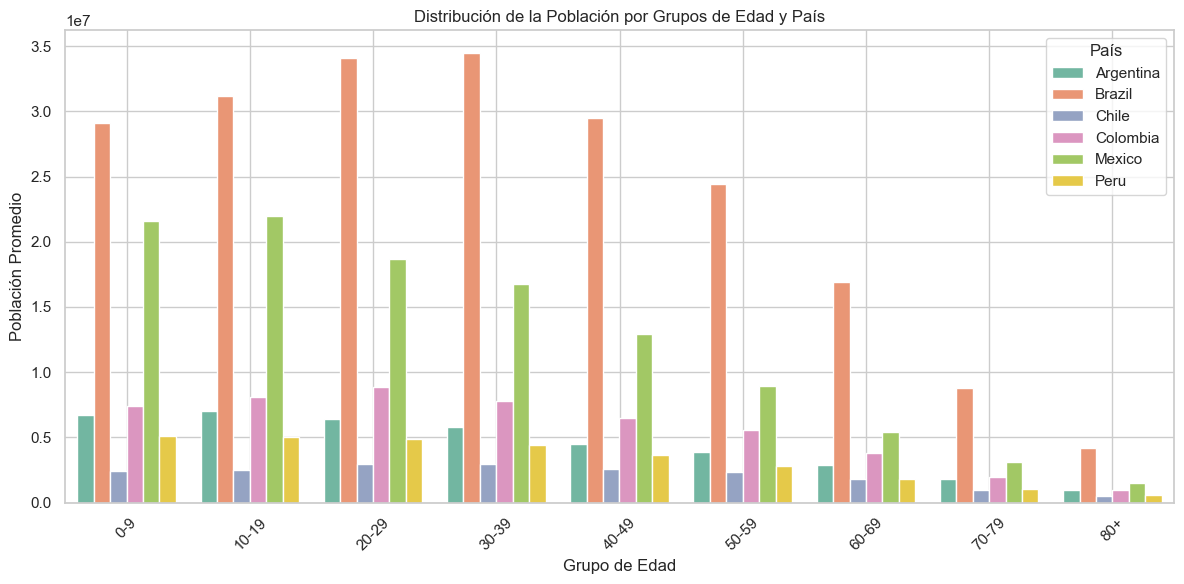

In [51]:
# 1. Seleccionamos columnas relevantes
columnas_edad = [
    'population_age_00_09', 'population_age_10_19', 'population_age_20_29',
    'population_age_30_39', 'population_age_40_49', 'population_age_50_59',
    'population_age_60_69', 'population_age_70_79', 'population_age_80_and_older'
]

# 2. Agrupamos por país (usamos el promedio por si hay múltiples fechas)
df_edad = df_datos_finales_filtrado.groupby('country_name')[columnas_edad].mean()

# 3. Reestructuramos el DataFrame para graficar
df_edad_melted = df_edad.reset_index().melt(id_vars='country_name', var_name='Grupo de Edad', value_name='Población')

# 4. Opcional: renombrar los grupos si deseas etiquetas más limpias
df_edad_melted['Grupo de Edad'] = df_edad_melted['Grupo de Edad'].replace({
    'population_age_00_09': '0-9',
    'population_age_10_19': '10-19',
    'population_age_20_29': '20-29',
    'population_age_30_39': '30-39',
    'population_age_40_49': '40-49',
    'population_age_50_59': '50-59',
    'population_age_60_69': '60-69',
    'population_age_70_79': '70-79',
    'population_age_80_and_older': '80+'
})

# 5. Graficamos la distribución
plt.figure(figsize=(12, 6))
sns.barplot(data=df_edad_melted, x='Grupo de Edad', y='Población', hue='country_name', palette='Set2')

plt.title('Distribución de la Población por Grupos de Edad y País')
plt.xlabel('Grupo de Edad')
plt.ylabel('Población Promedio')
plt.legend(title='País')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


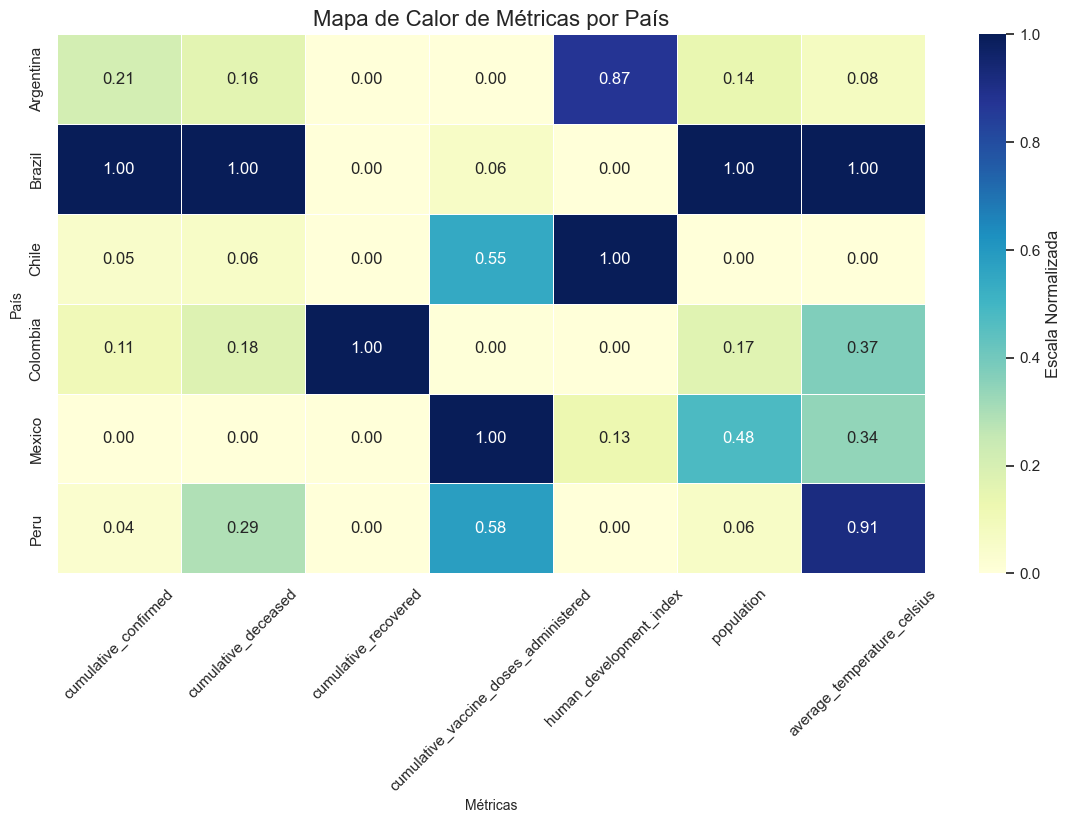

In [52]:
# Usamos las mismas métricas
columnas_metrica = [
    'cumulative_confirmed', 'cumulative_deceased', 'cumulative_recovered',
    'cumulative_vaccine_doses_administered', 'human_development_index',
    'population', 'average_temperature_celsius'
]

# Tomar el último registro por país (última fecha disponible)
df_metrica = df_datos_finales_filtrado.sort_values('date').groupby('country_name').last()
df_metrica = df_metrica[columnas_metrica]

# Normalizamos para que los valores estén en la misma escala
df_metrica_normalizada = (df_metrica - df_metrica.min()) / (df_metrica.max() - df_metrica.min())

# Graficamos el heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(df_metrica_normalizada, cmap='YlGnBu', annot=True, fmt=".2f", 
            cbar_kws={'label': 'Escala Normalizada'}, linewidths=0.5)

plt.title('Mapa de Calor de Métricas por País', fontsize=16)
plt.xlabel('Métricas', fontsize=10)
plt.ylabel('País', fontsize=10)
plt.xticks(rotation=45)
plt.show()



C:\Users\benav\AppData\Local\Temp\ipykernel_13800\1517600848.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\benav\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


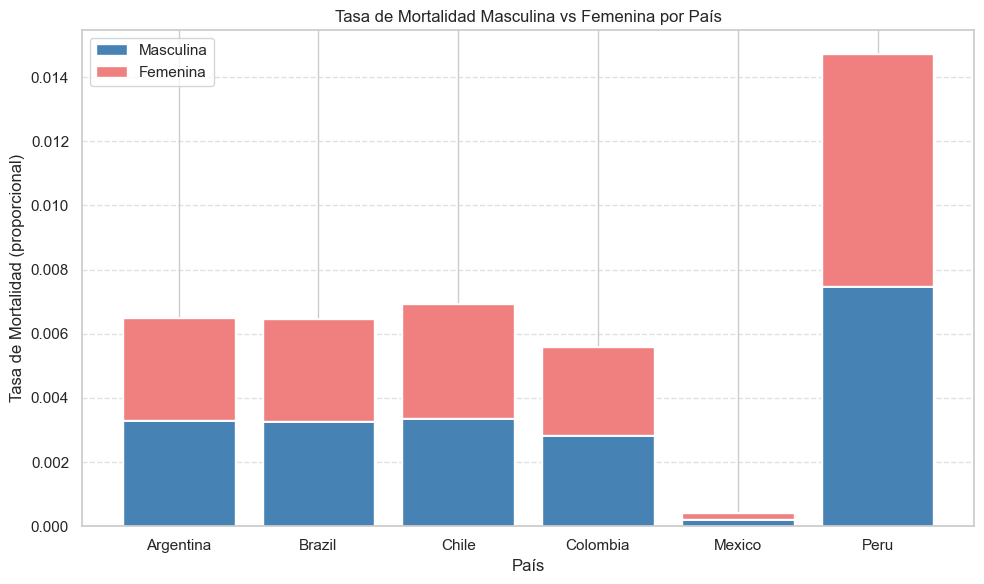

In [53]:


# Filtrar el último registro por país
df_ultimos = df_datos_finales_filtrado.sort_values('date').groupby('country_name').last()

# Calcular muertes estimadas por género (50% cada uno)
df_ultimos['muertes_masculinas'] = df_ultimos['cumulative_deceased'] * 0.5
df_ultimos['muertes_femeninas'] = df_ultimos['cumulative_deceased'] * 0.5

# Tasa de mortalidad por género
df_ultimos['tasa_mortalidad_m'] = df_ultimos['muertes_masculinas'] / df_ultimos['population_male']
df_ultimos['tasa_mortalidad_f'] = df_ultimos['muertes_femeninas'] / df_ultimos['population_female']

# Seleccionar países de interés

df_plot = df_ultimos.loc[df_datos_finales_filtrado['country_name'], ['tasa_mortalidad_m', 'tasa_mortalidad_f']]

# Crear gráfico de barras apiladas
plt.figure(figsize=(10,6))
plt.bar(df_plot.index, df_plot['tasa_mortalidad_m'], label='Masculina', color='steelblue')
plt.bar(df_plot.index, df_plot['tasa_mortalidad_f'], bottom=df_plot['tasa_mortalidad_m'], label='Femenina', color='lightcoral')

plt.title('Tasa de Mortalidad Masculina vs Femenina por País')
plt.xlabel('País')
plt.ylabel('Tasa de Mortalidad (proporcional)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



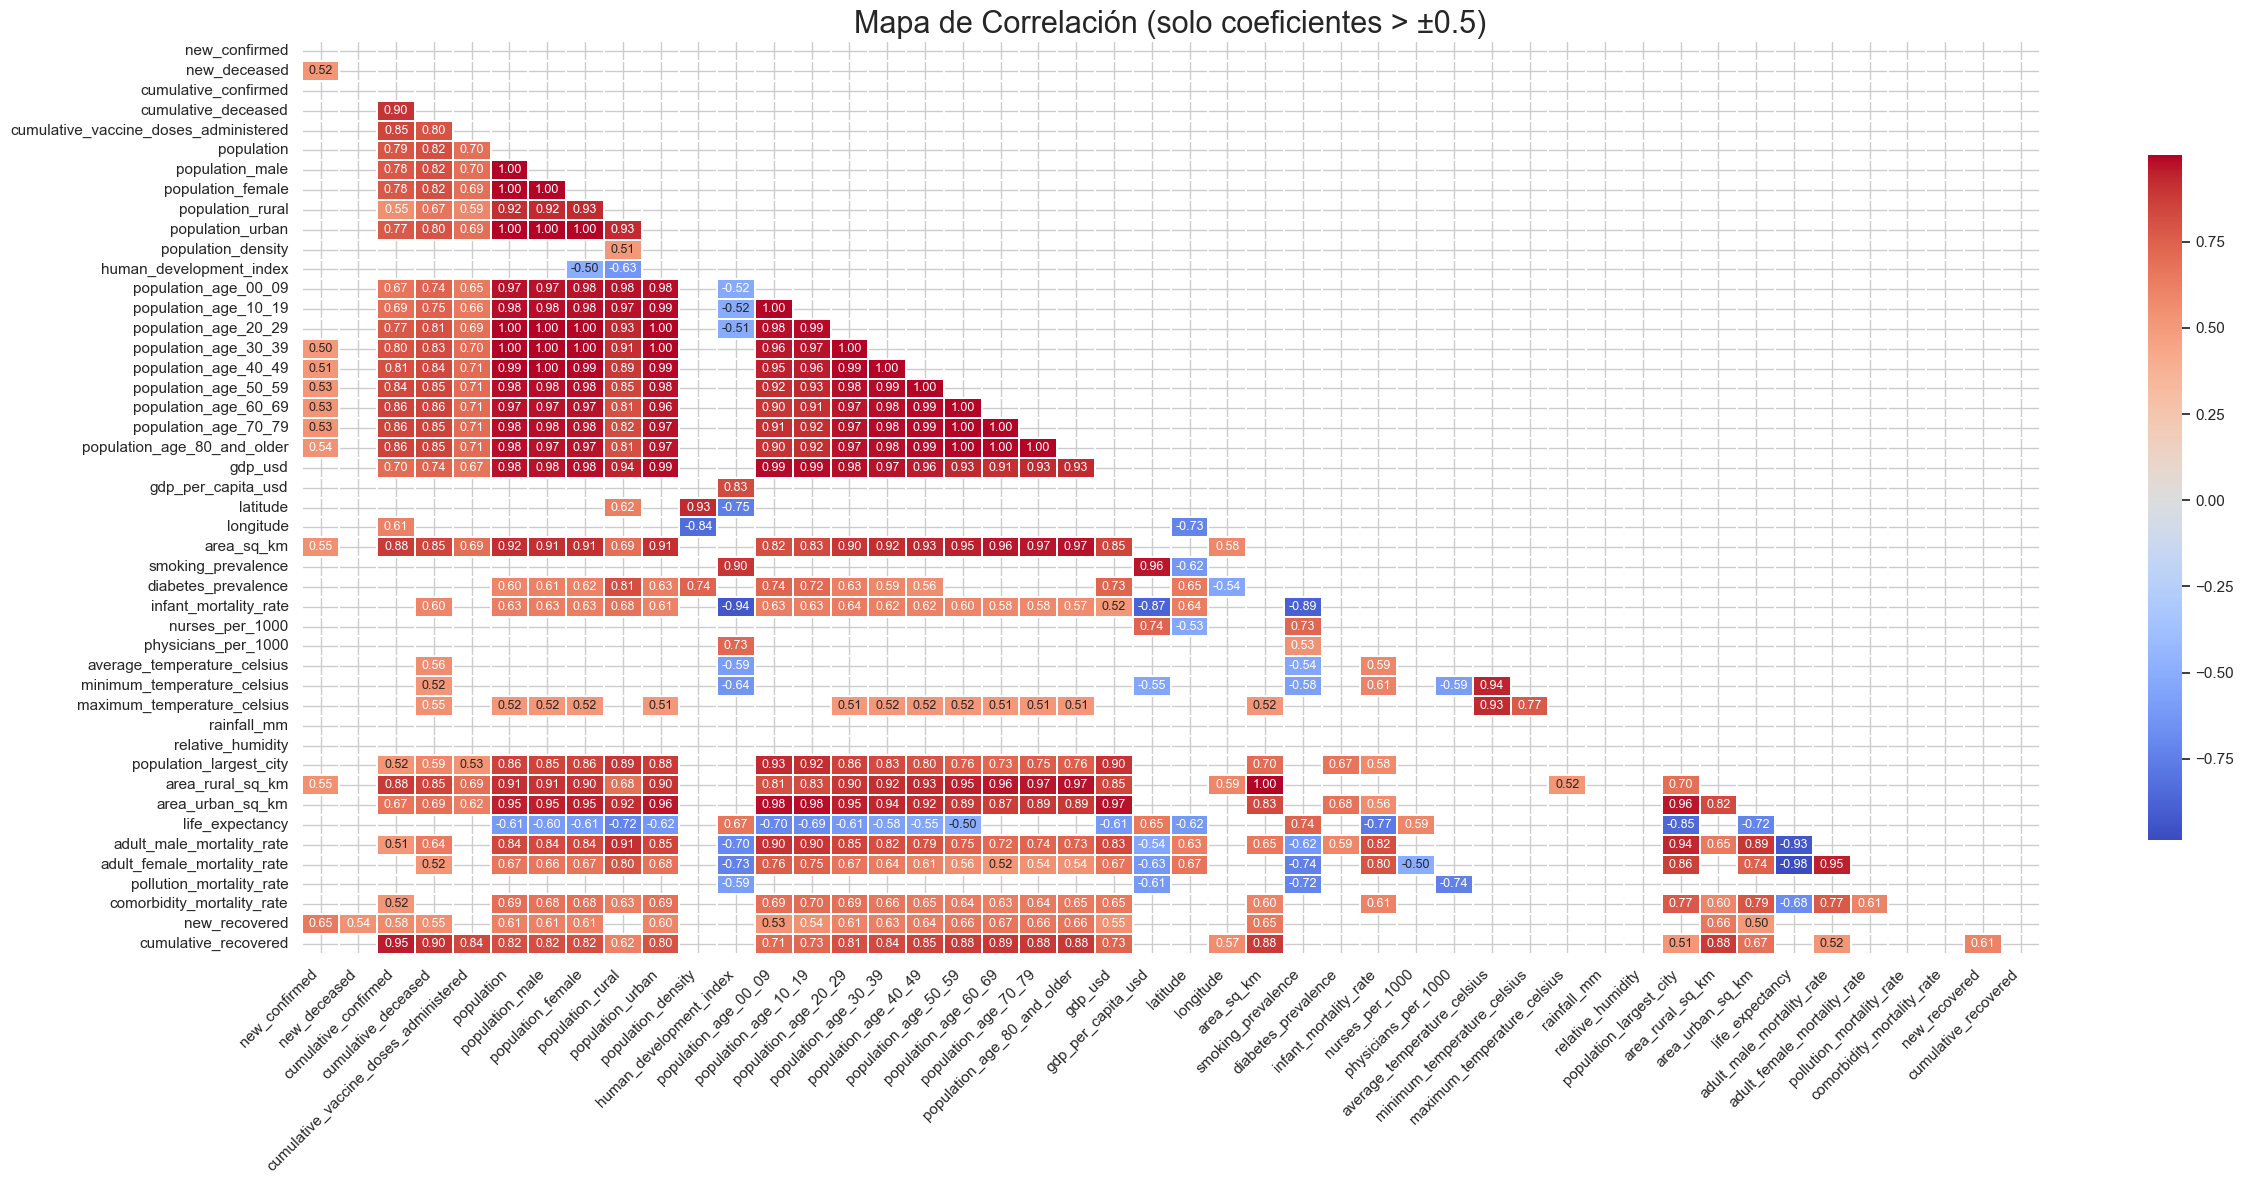

In [54]:
# Calcular la matriz de correlación para columnas numéricas relevantes
corr = df_datos_finales_filtrado[df_datos_finales_filtrado.columns[4:50]].corr()

# Crear una máscara para ocultar la mitad superior del mapa
mascara = np.triu(np.ones_like(corr, dtype=bool))

# Crear una copia y dejar solo correlaciones fuertes
strong_corr = corr.copy()
strong_corr[abs(strong_corr) < 0.5] = np.nan

sns.set_theme(style='whitegrid')

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(25, 12))
sns.heatmap(
    strong_corr,
    mask=mascara,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={'fontsize': 9},
    linewidths=0.08,
    ax=ax,
    cbar_kws={"shrink": .75}
)

# Mejorar la legibilidad del texto
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Mapa de Correlación (solo coeficientes > ±0.5)', fontsize=22)
plt.tight_layout()
plt.show()


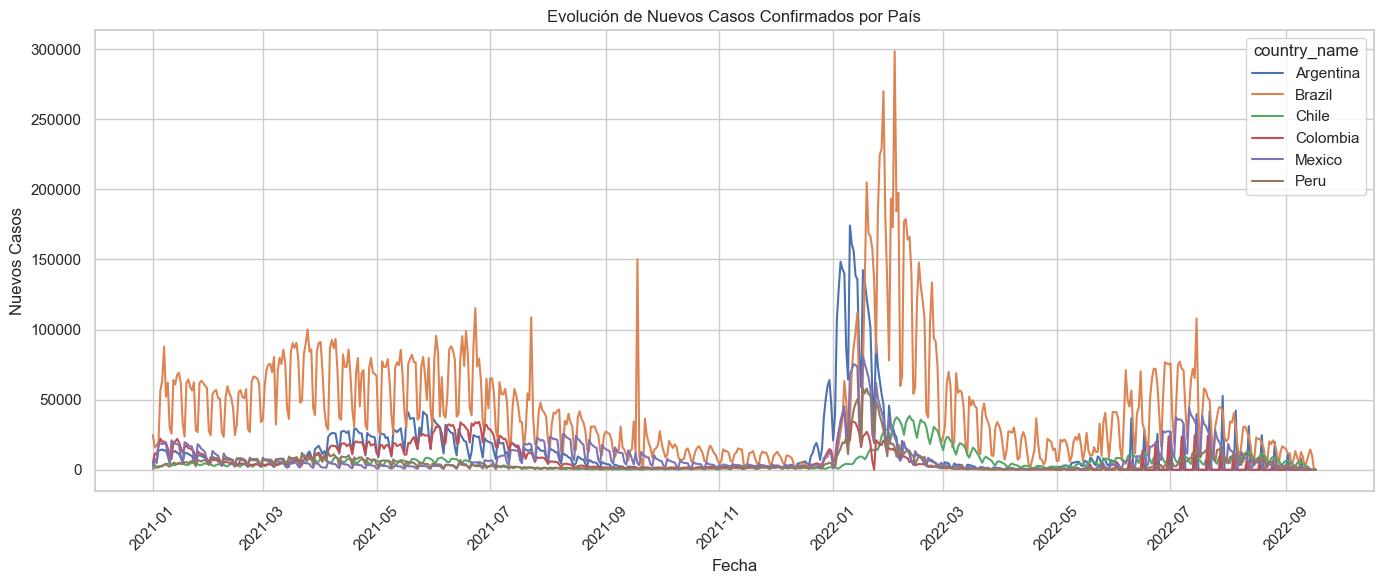

In [55]:
# Agrupamos por fecha y país
df_temporal = df_datos_finales_filtrado.groupby(['date', 'country_name'])[['new_confirmed', 'cumulative_vaccine_doses_administered']].sum().reset_index()

# Gráfico
plt.figure(figsize=(14,6))
sns.lineplot(data=df_temporal, x='date', y='new_confirmed', hue='country_name')
plt.title('Evolución de Nuevos Casos Confirmados por País')
plt.xlabel('Fecha')
plt.ylabel('Nuevos Casos')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


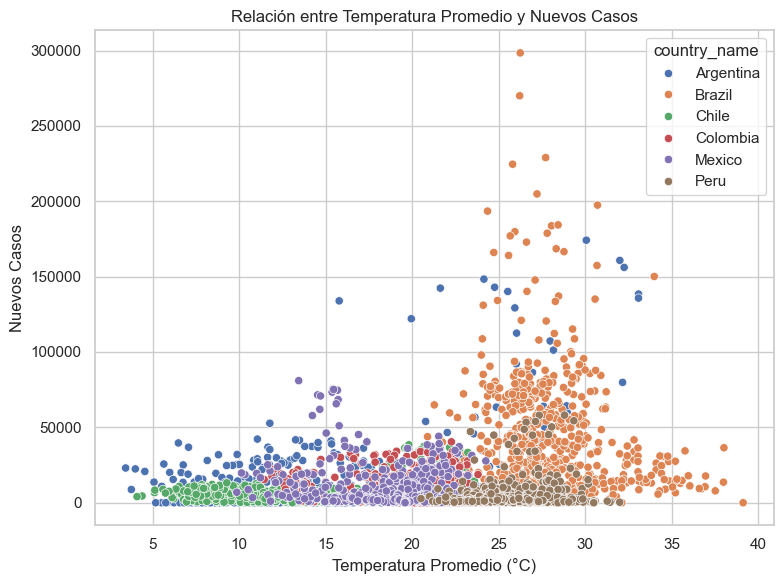

In [56]:

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_datos_finales_filtrado, x='average_temperature_celsius', y='new_confirmed', hue='country_name')
plt.title('Relación entre Temperatura Promedio y Nuevos Casos')
plt.xlabel('Temperatura Promedio (°C)')
plt.ylabel('Nuevos Casos')
plt.grid(True)
plt.tight_layout()
plt.show()


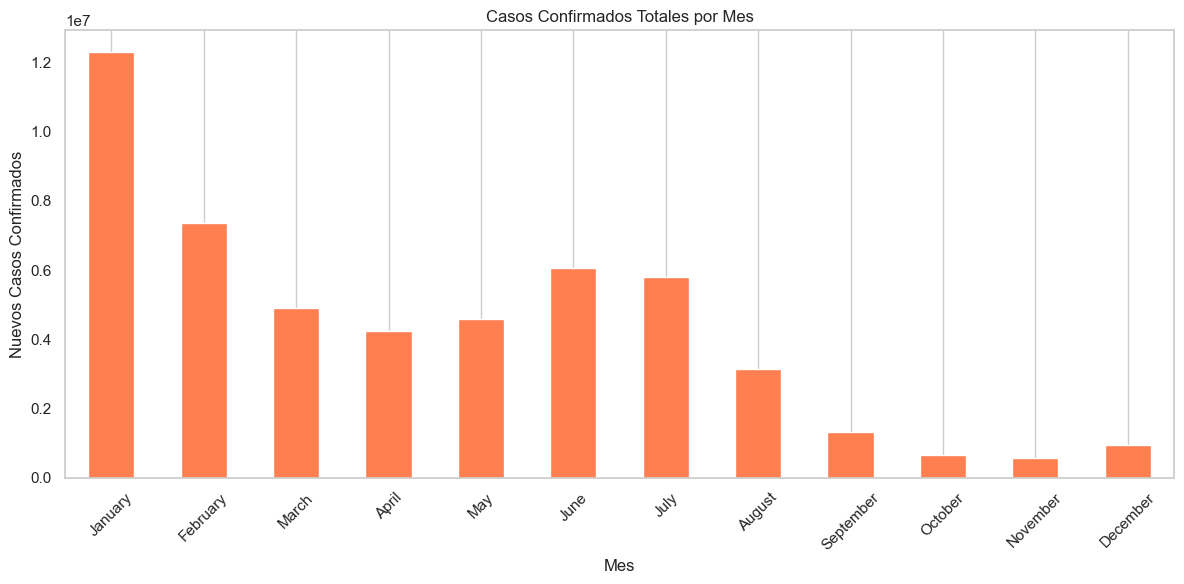

In [57]:
# Extraer mes
df_datos_finales_filtrado['month'] = pd.to_datetime(df_datos_finales_filtrado['date']).dt.month_name()

# Agrupar por mes
df_monthly = df_datos_finales_filtrado.groupby(['month'])['new_confirmed'].sum().reindex([
    'January','February','March','April','May','June','July','August','September','October','November','December'
])

# Gráfico
plt.figure(figsize=(12,6))
df_monthly.plot(kind='bar', color='coral')
plt.title('Casos Confirmados Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Nuevos Casos Confirmados')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## Avance 3

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered,nivel_recuperacion,month
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,55032.0,76.52,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253872,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September
10253873,PE,2022-09-14,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September
10253874,PE,2022-09-15,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September
10253875,PE,2022-09-16,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,16425.0,76.52,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September


In [60]:
# Asegurarse que la columna 'date' es datetime
#df_datos_finales_filtrado['date'] = pd.to_datetime(df_datos_finales_filtrado['date'])

# Agrupar por país y fecha
df_diario = df_datos_finales_filtrado.groupby(['country_name', 'date'])[
    ['cumulative_confirmed', 'cumulative_deceased']
].sum().reset_index()


In [61]:
# Aplicar media móvil por país
ventana = 7
df_diario['confirmed_rolling'] = df_diario.groupby('country_name')['cumulative_confirmed'].transform(lambda x: x.rolling(window=ventana).mean())
df_diario['deceased_rolling'] = df_diario.groupby('country_name')['cumulative_deceased'].transform(lambda x: x.rolling(window=ventana).mean())


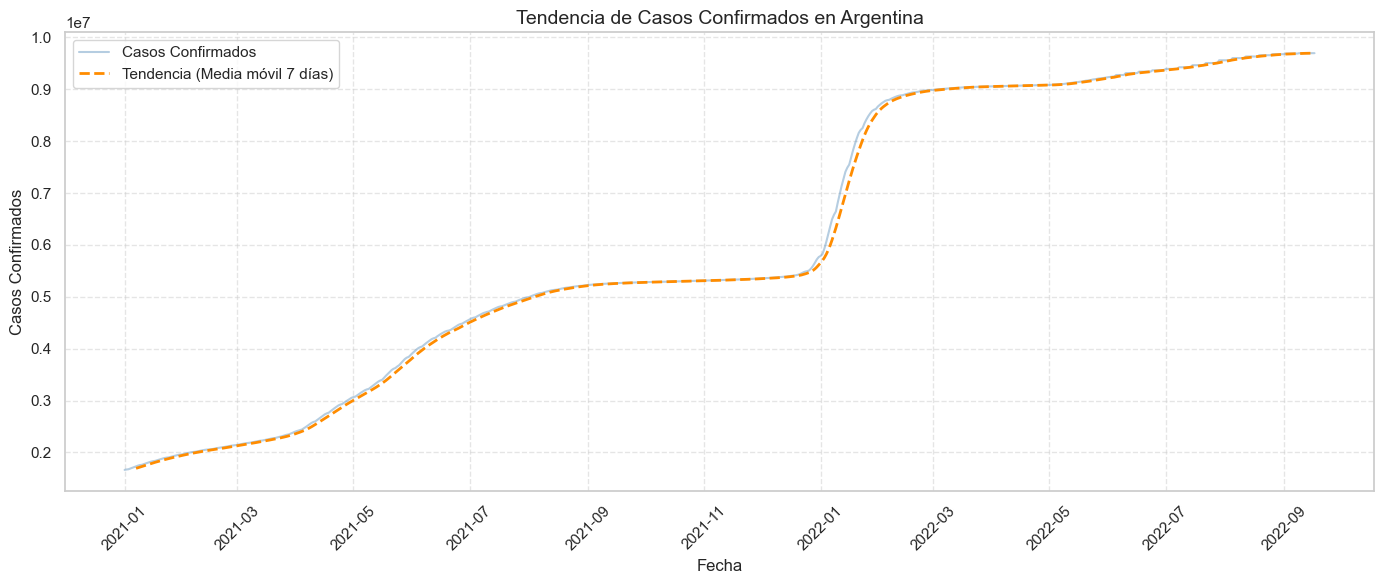

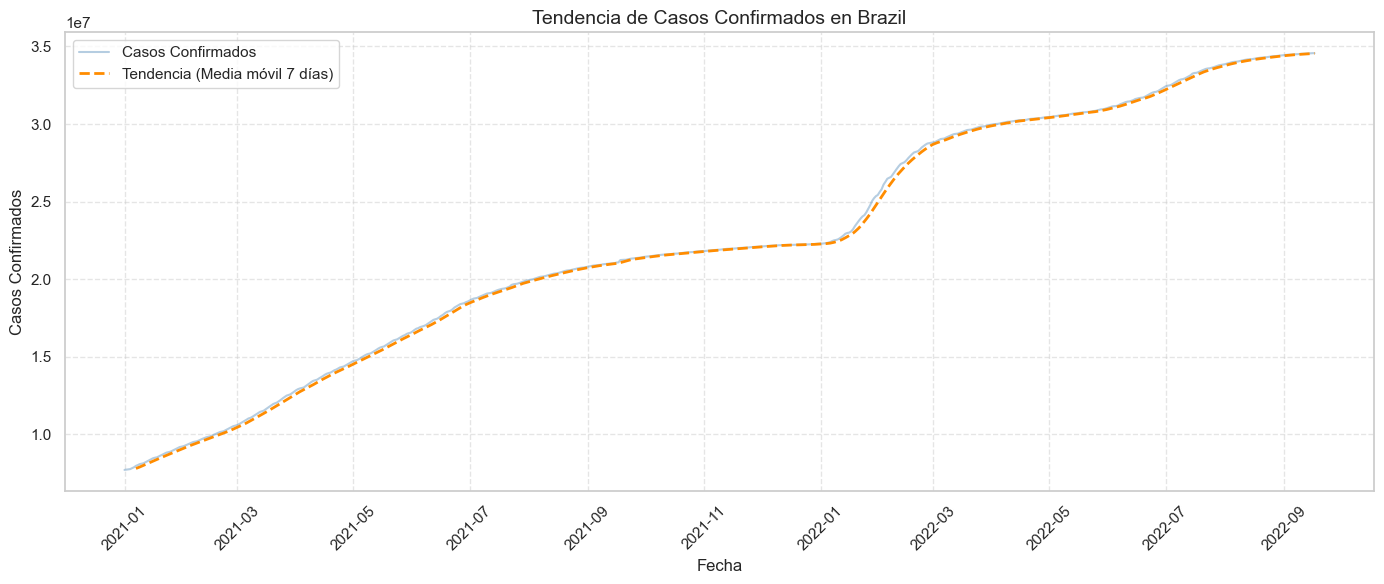

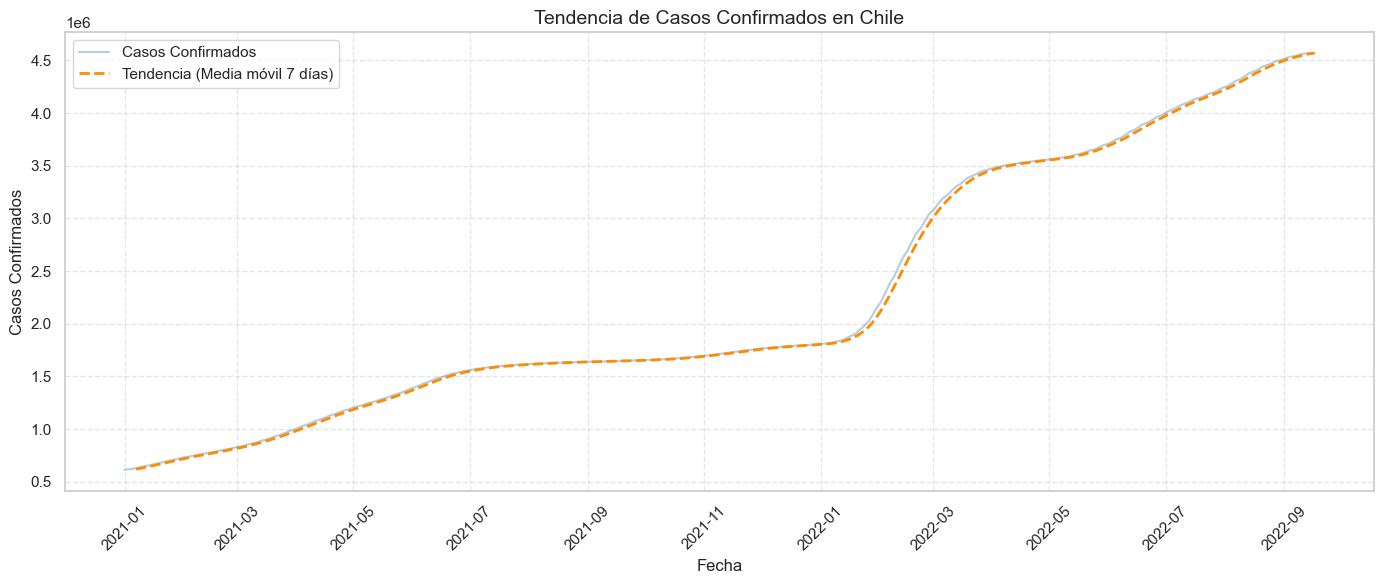

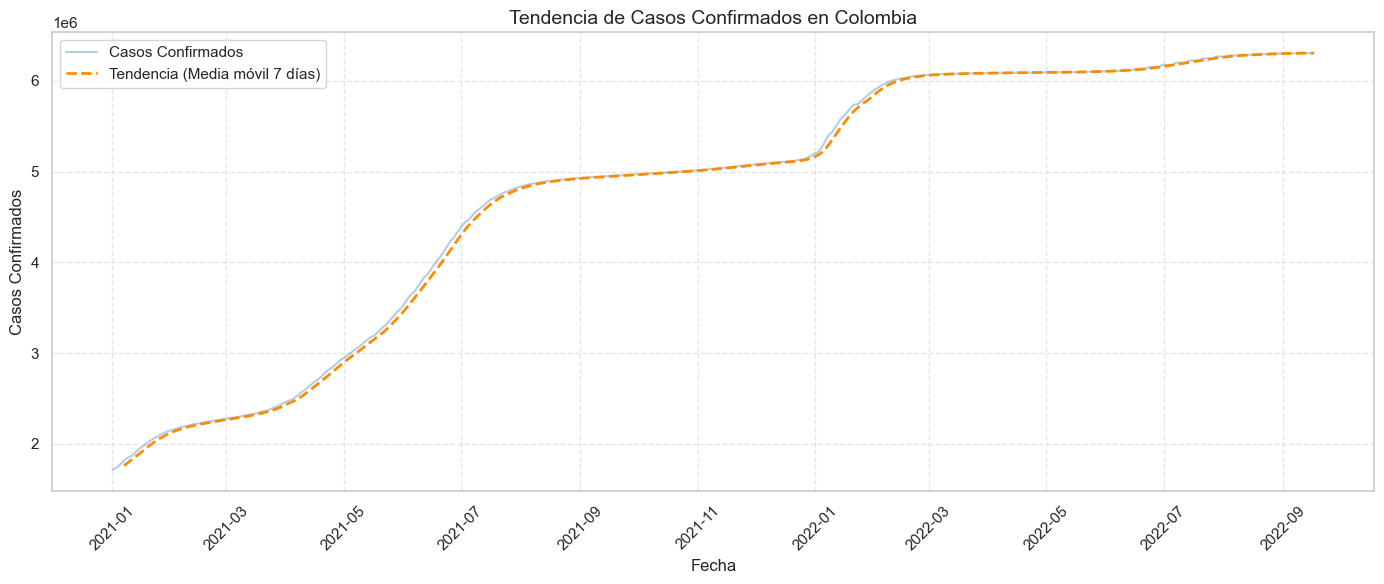

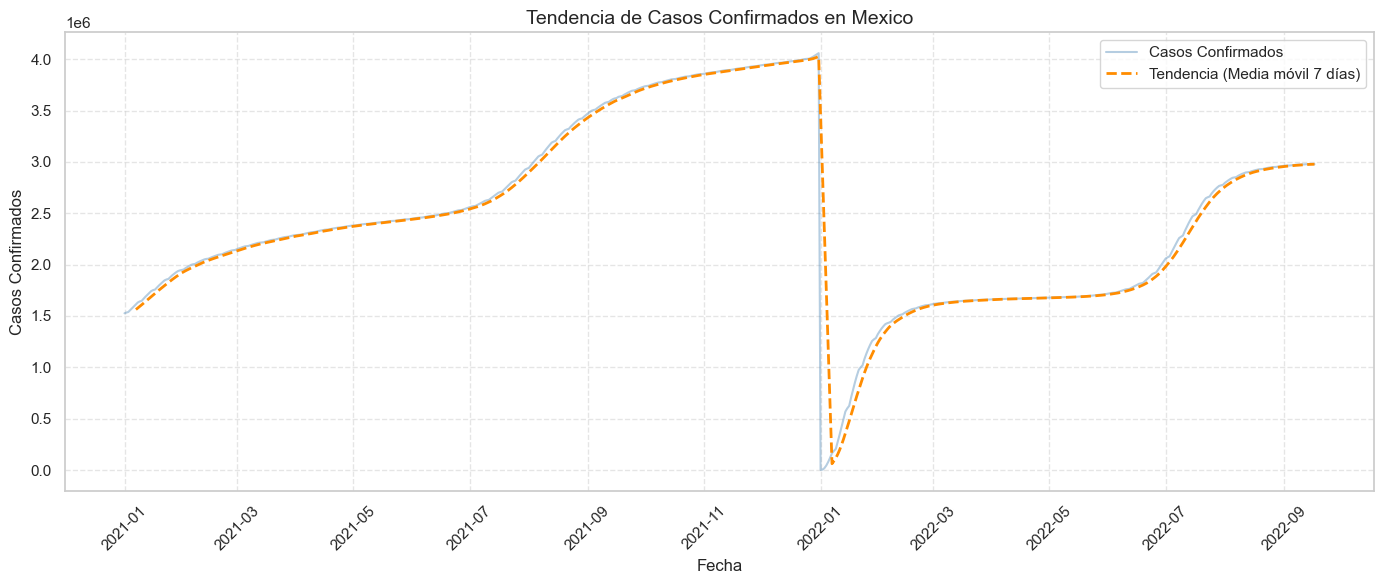

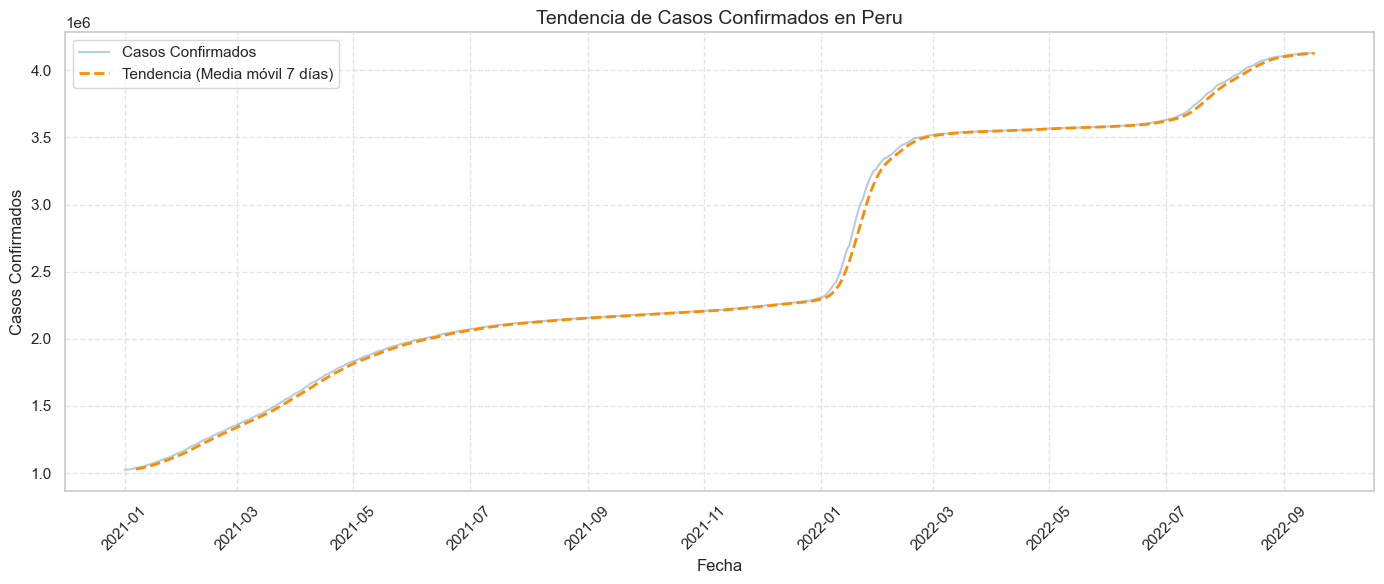

In [62]:
import matplotlib.dates as mdates

for pais in df_datos_finales_filtrado['country_name'].unique():
    df_pais = df_diario[df_diario['country_name'] == pais]

    plt.figure(figsize=(14, 6))
    plt.plot(df_pais['date'], df_pais['cumulative_confirmed'], label='Casos Confirmados', alpha=0.4, color='steelblue')
    plt.plot(df_pais['date'], df_pais['confirmed_rolling'], label='Tendencia (Media móvil 7 días)', linestyle='--', color='darkorange', linewidth=2)

    # Título y etiquetas
    plt.title(f'Tendencia de Casos Confirmados en {pais}', fontsize=14)
    plt.xlabel('Fecha')
    plt.ylabel('Casos Confirmados')
    plt.xticks(rotation=45) 

    # Mostrar cuadrícula y leyenda
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


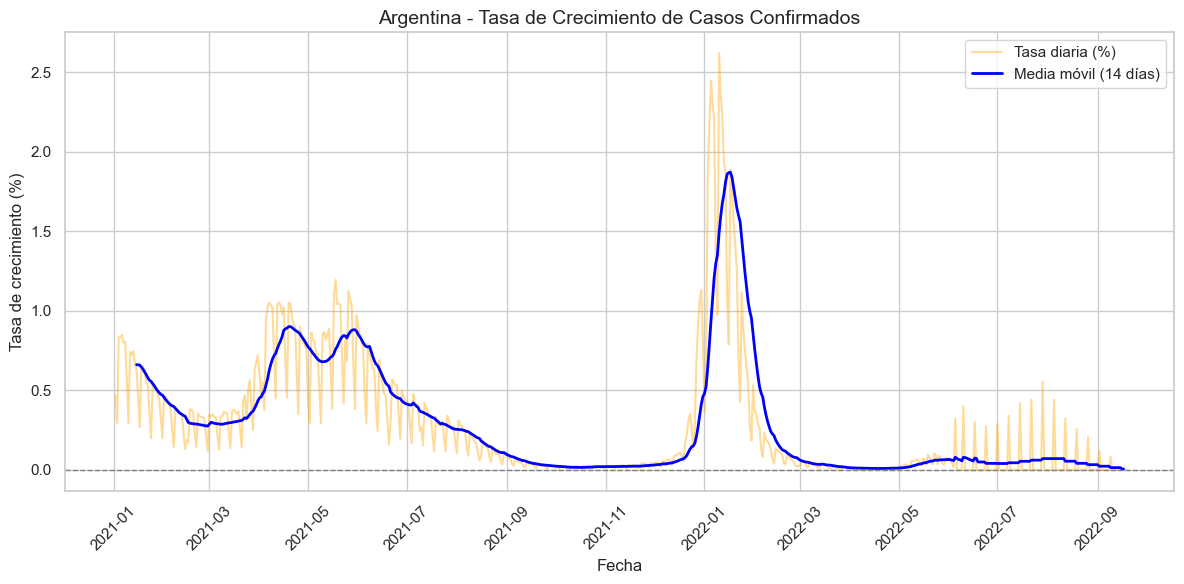

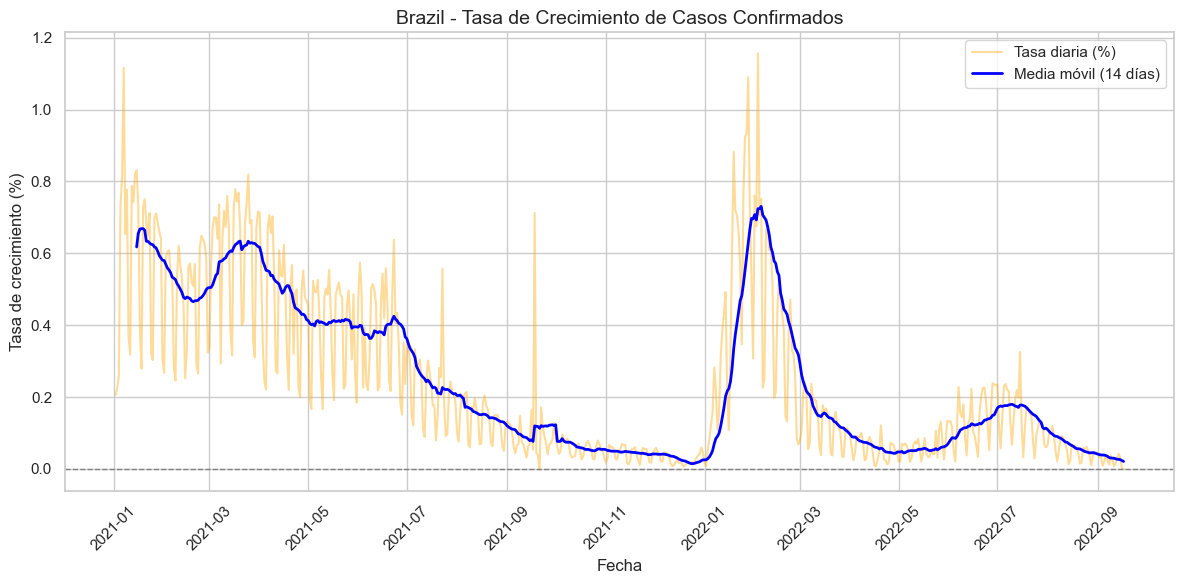

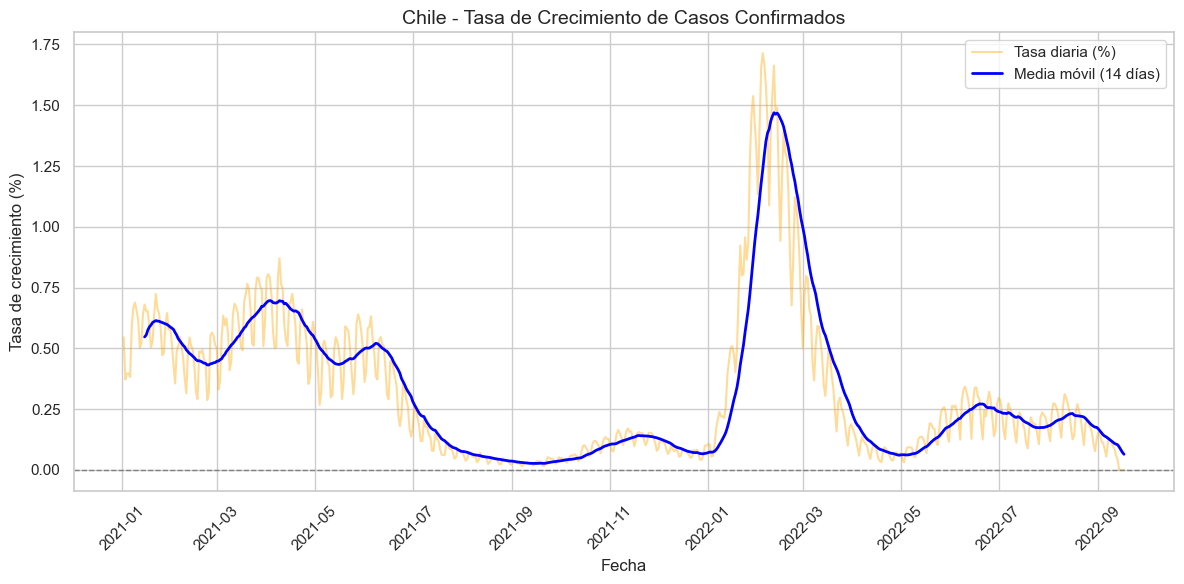

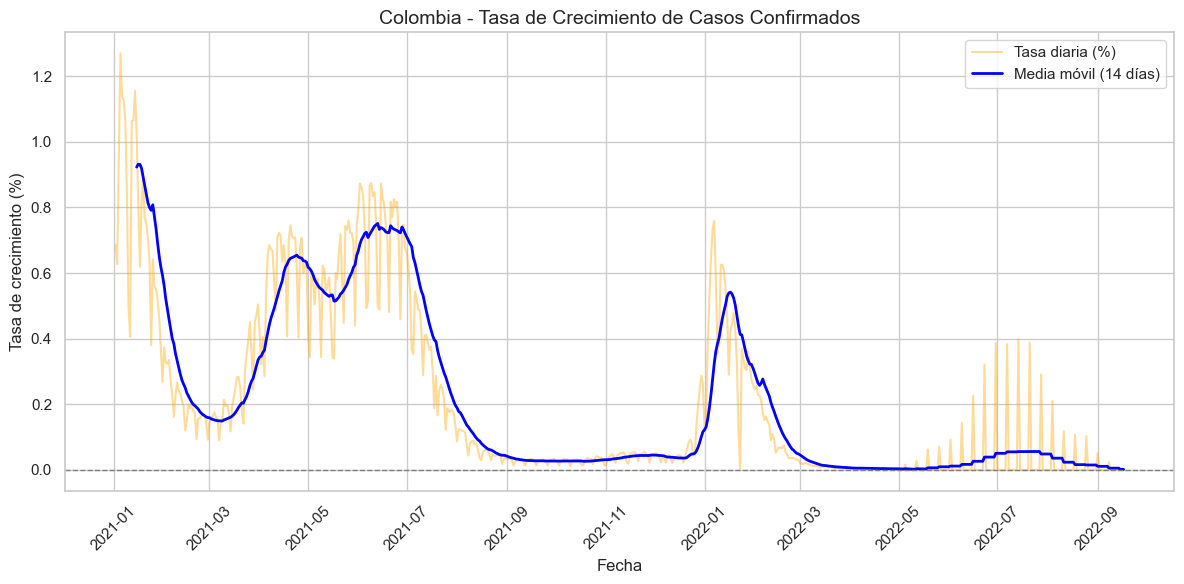

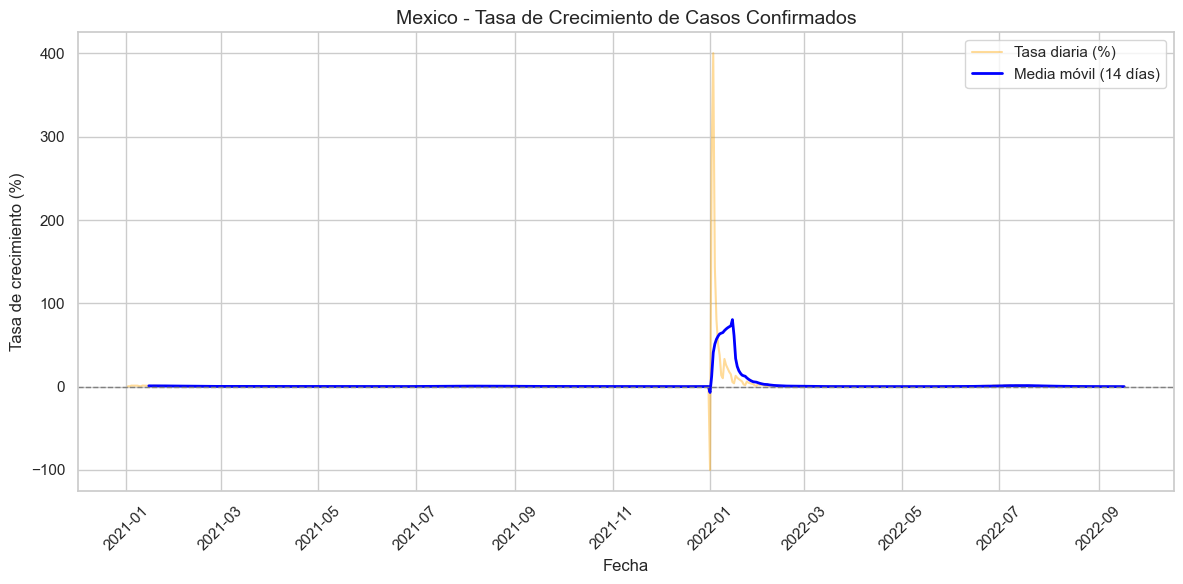

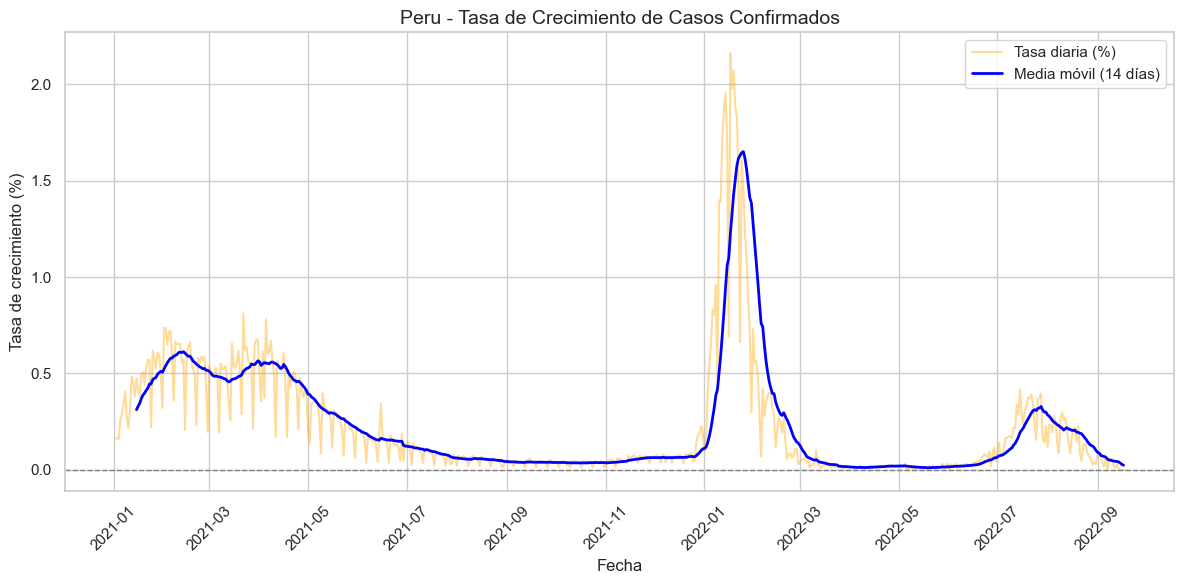

In [63]:
for pais in df_datos_finales_filtrado['country_name'].unique():
    df_pais = df_datos_finales_filtrado[df_datos_finales_filtrado['country_name'] == pais].copy()
    df_pais = df_pais.sort_values('date')

    # Calcular tasa de crecimiento
    df_pais['growth_rate'] = df_pais['cumulative_confirmed'].pct_change() * 100

    # Suavizar
    df_pais['growth_rate_rolling'] = df_pais['growth_rate'].rolling(window=14).mean()

    # Gráfico
    plt.figure(figsize=(12,6))
    plt.plot(df_pais['date'], df_pais['growth_rate'], label='Tasa diaria (%)', color='orange', alpha=0.4)
    plt.plot(df_pais['date'], df_pais['growth_rate_rolling'], label='Media móvil (14 días)', color='blue', linewidth=2)

    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    plt.title(f'{pais} - Tasa de Crecimiento de Casos Confirmados', fontsize=14)
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de crecimiento (%)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()




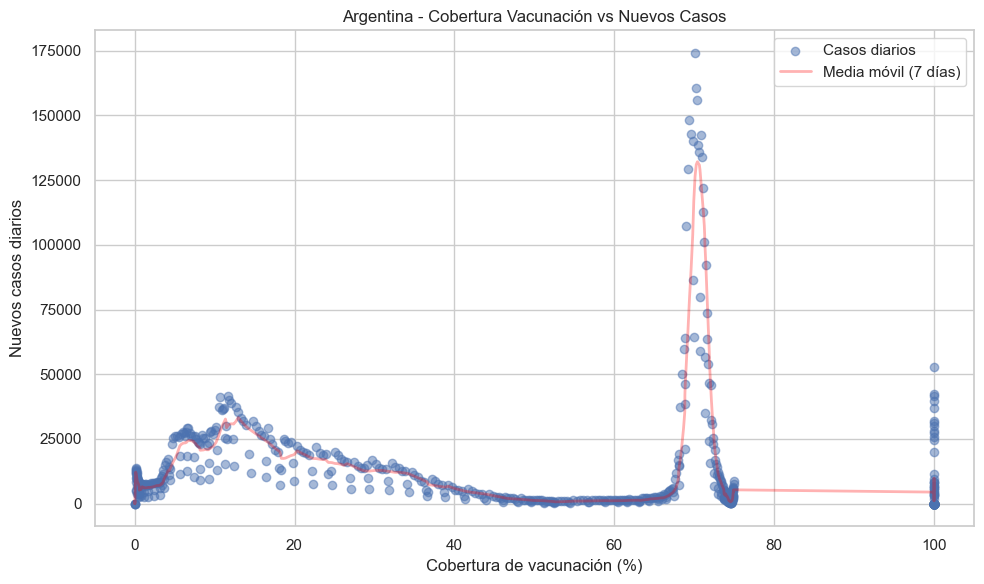

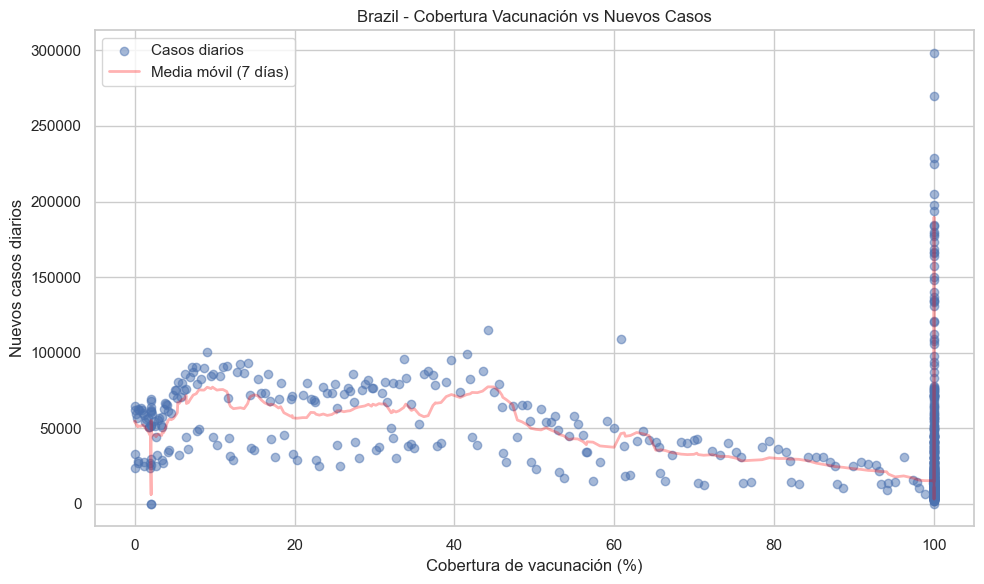

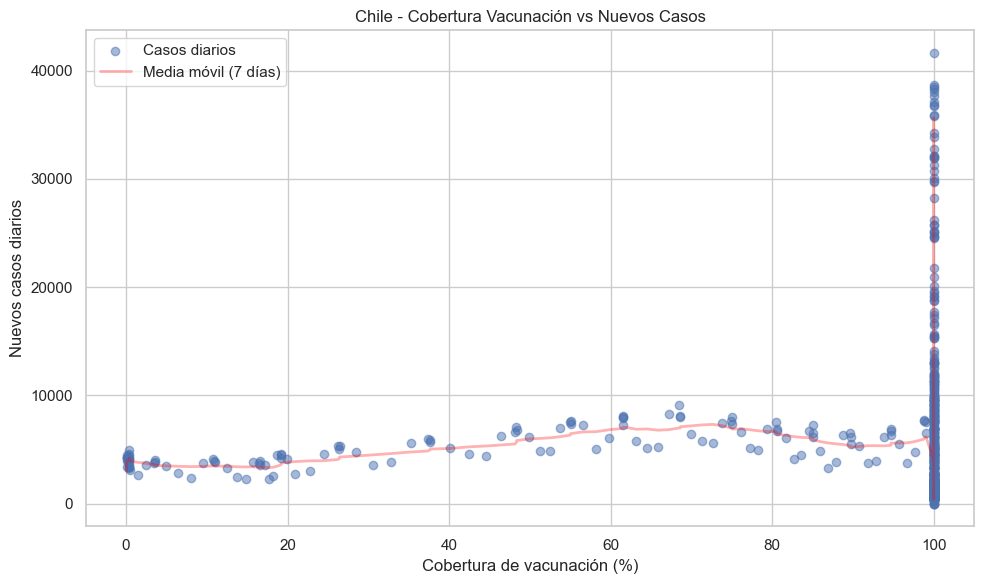

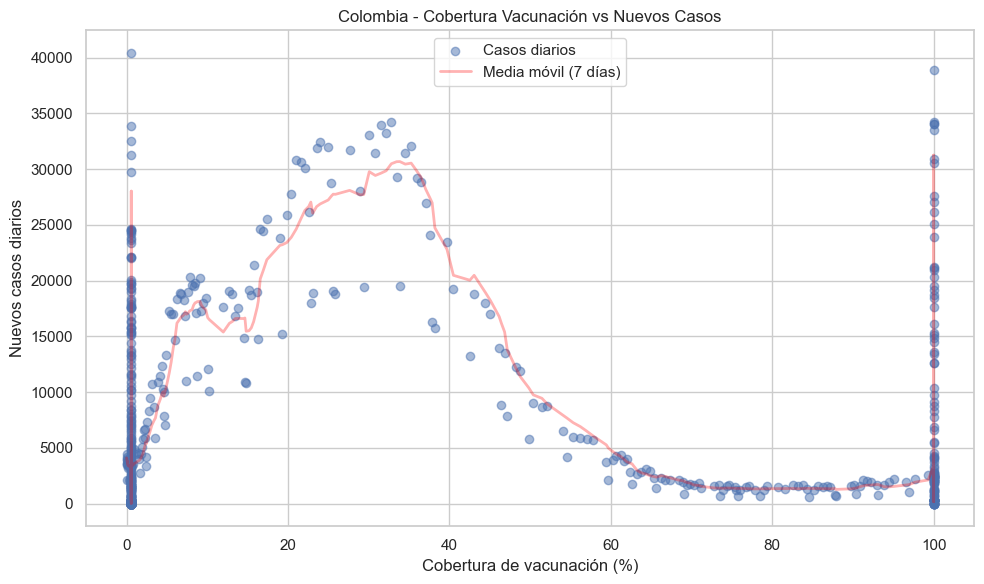

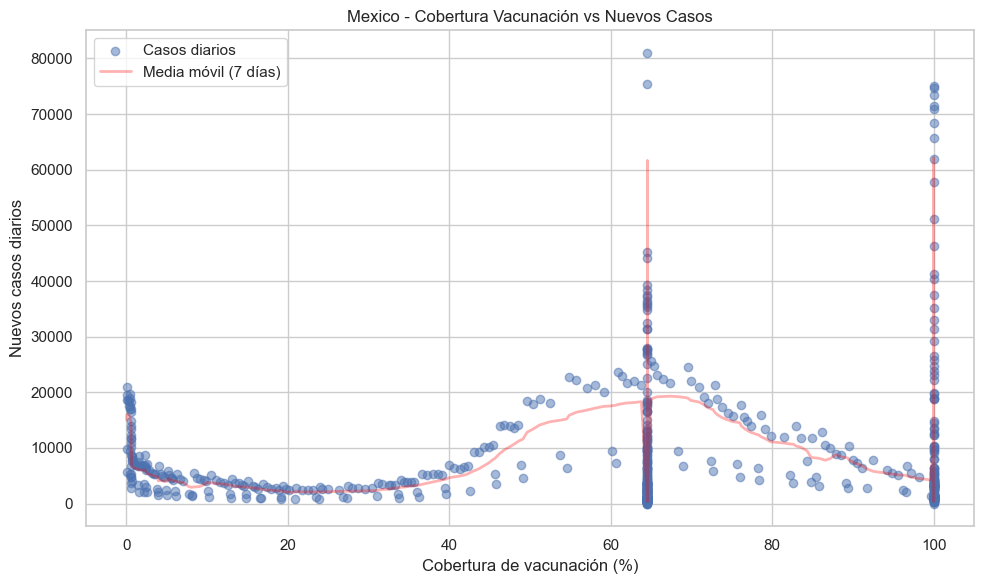

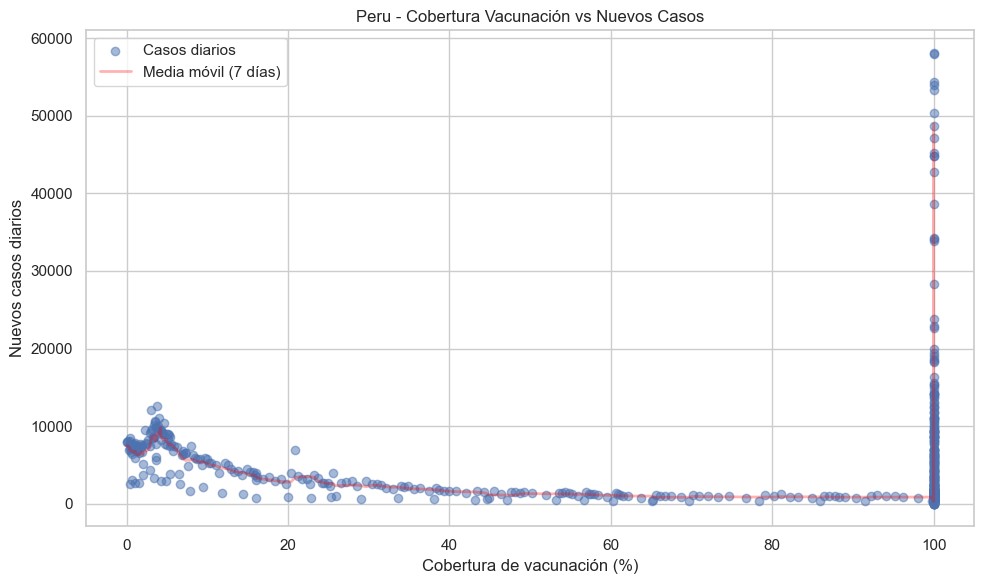

In [64]:
for pais in df_datos_finales_filtrado['country_name'].unique():  
    df_pais = df_datos_finales_filtrado[df_datos_finales_filtrado['country_name'] == pais].copy()
    df_pais = df_pais.sort_values('date')
    
    df_pais = df_pais[df_pais['population'] > 0]
    
    # Cobertura de vacunación (%)
    df_pais['vac_coverage'] = (df_pais['cumulative_vaccine_doses_administered'] / df_pais['population']) * 100
    df_pais['vac_coverage'] = df_pais['vac_coverage'].clip(upper=100)  # Limitar al 100%

    # Nuevos casos diarios (evitar valores negativos)
    df_pais['new_cases'] = df_pais['cumulative_confirmed'].diff().clip(lower=0)
    df_pais['new_cases_rolling'] = df_pais['new_cases'].rolling(window=7).mean()

    # Eliminar filas con NaNs o valores inválidos
    df_plot = df_pais[['vac_coverage', 'new_cases', 'new_cases_rolling']].dropna()
    df_plot = df_plot.sort_values('vac_coverage')

    # Gráfico
    plt.figure(figsize=(10,6))
    plt.scatter(df_plot['vac_coverage'], df_plot['new_cases'], alpha=0.5, label='Casos diarios')
    plt.plot(df_plot['vac_coverage'], df_plot['new_cases_rolling'], color='red', linewidth=2, alpha=0.3, label='Media móvil (7 días)')
    plt.title(f'{pais} - Cobertura Vacunación vs Nuevos Casos')
    plt.xlabel('Cobertura de vacunación (%)')
    plt.ylabel('Nuevos casos diarios')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


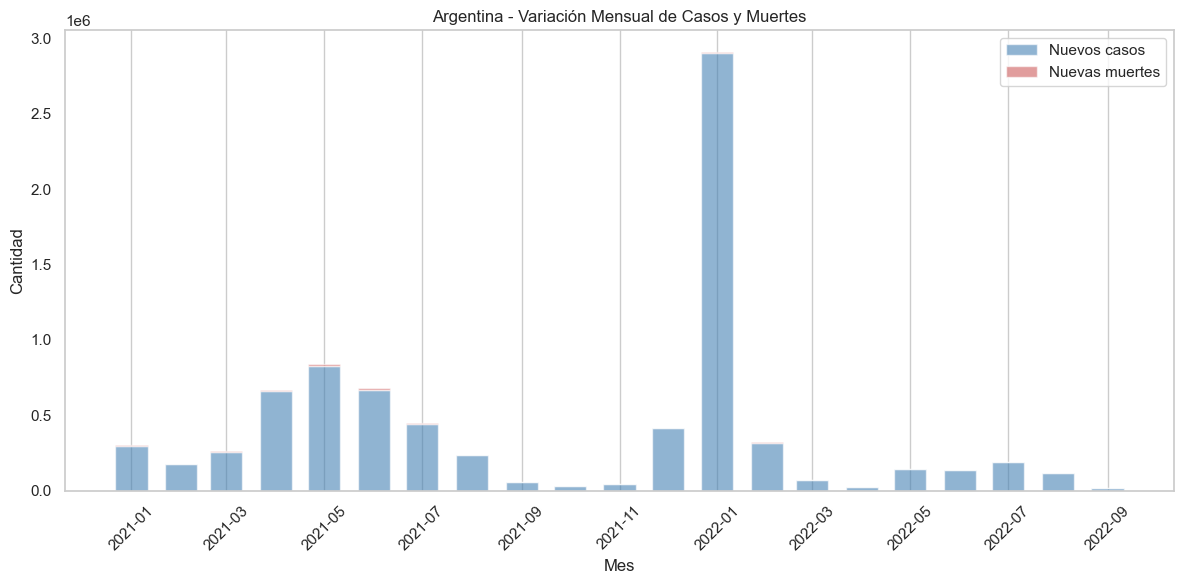

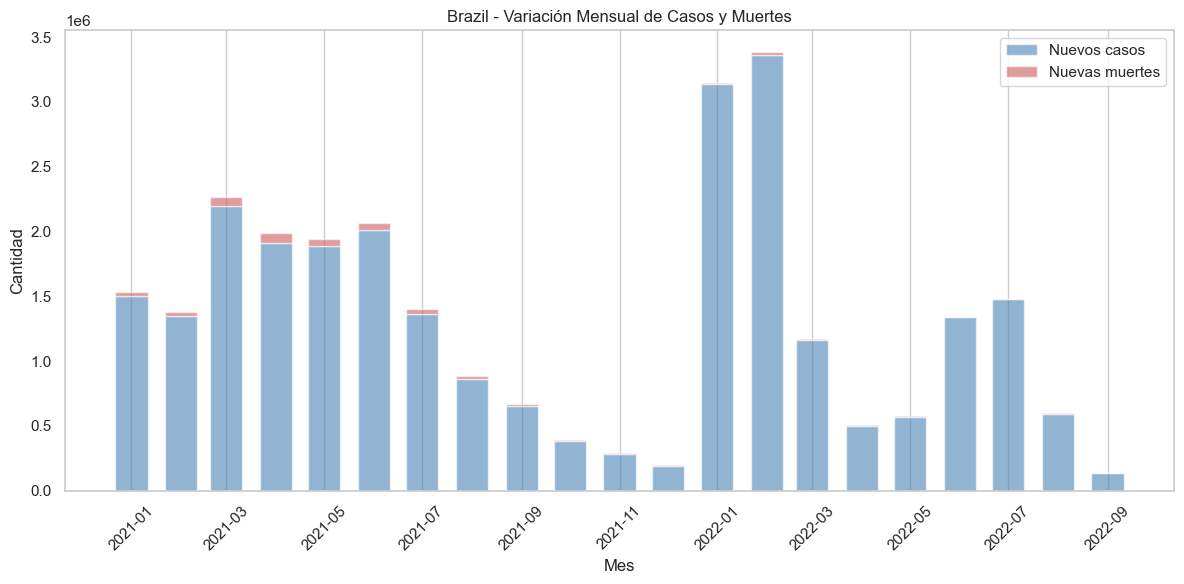

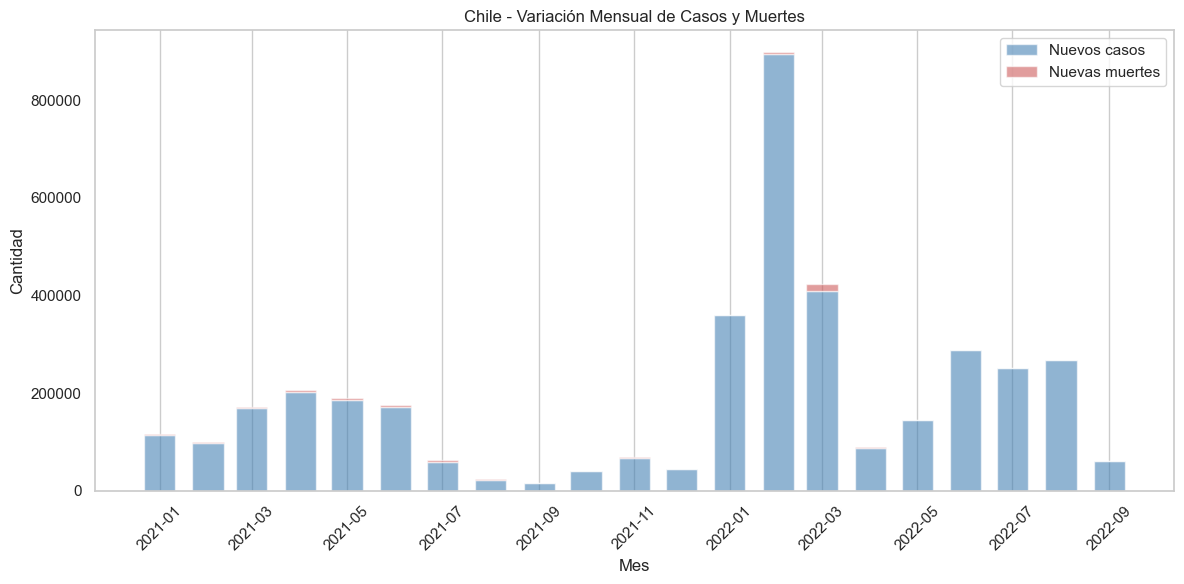

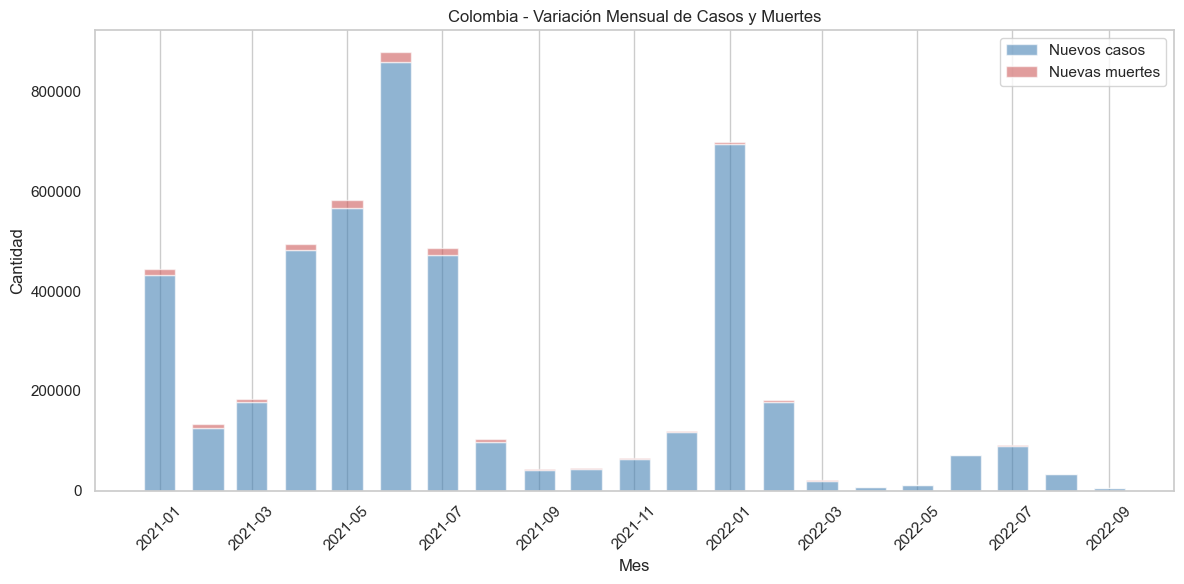

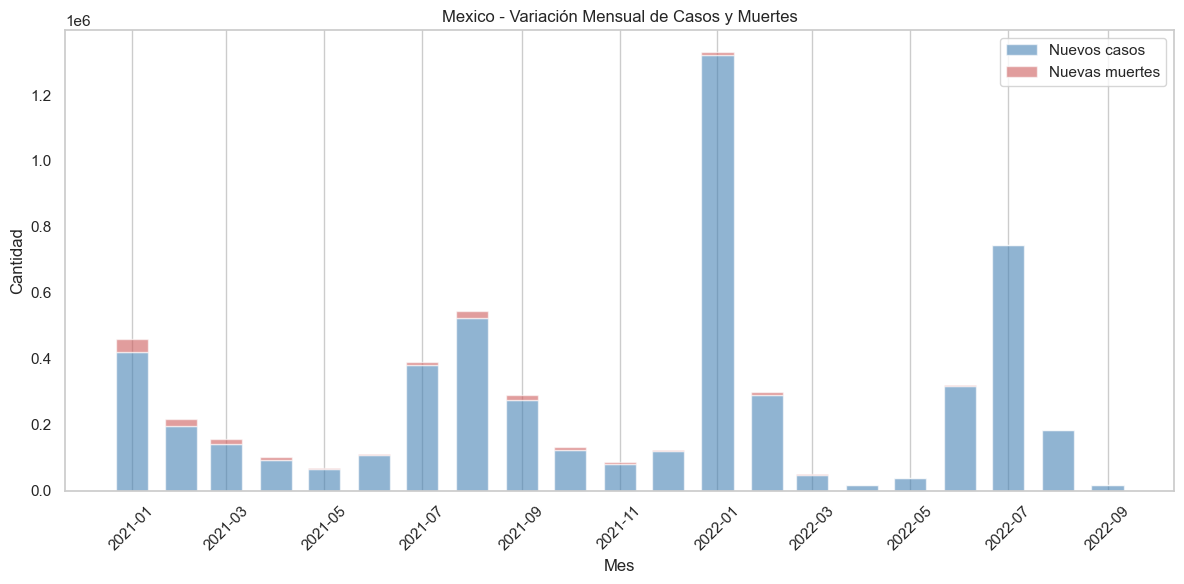

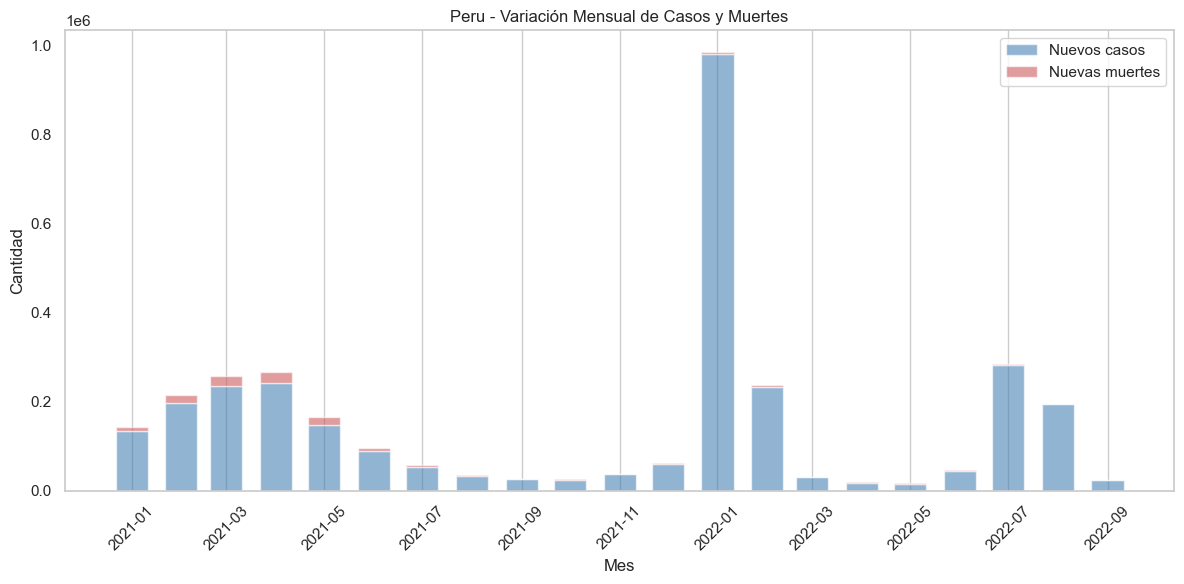

In [65]:
# Crear una nueva columna 'mes' con el primer día del mes
df_datos_finales_filtrado['mes'] = df_datos_finales_filtrado['date'].dt.to_period('M').dt.to_timestamp()

for pais in df_datos_finales_filtrado['country_name'].unique():
    df_pais = df_datos_finales_filtrado[df_datos_finales_filtrado['country_name'] == pais].copy()
    df_pais = df_pais.sort_values('date')

    # Calcular casos y muertes diarias, evitando negativos
    df_pais['nuevos_casos'] = df_pais['cumulative_confirmed'].diff().clip(lower=0)
    df_pais['nuevas_muertes'] = df_pais['cumulative_deceased'].diff().clip(lower=0)

    # Agrupar por mes
    df_mensual = df_pais.groupby('mes')[['nuevos_casos', 'nuevas_muertes']].sum().reset_index()

    # Gráfico
    plt.figure(figsize=(12,6))
    plt.bar(df_mensual['mes'], df_mensual['nuevos_casos'], width=20, label='Nuevos casos', alpha=0.6, color='steelblue')
    plt.bar(df_mensual['mes'], df_mensual['nuevas_muertes'], width=20, label='Nuevas muertes', alpha=0.6, color='indianred', bottom=df_mensual['nuevos_casos'])

    plt.title(f'{pais} - Variación Mensual de Casos y Muertes')
    plt.xlabel('Mes')
    plt.ylabel('Cantidad')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()




Grafica de Comparación de la Situación Actual por País

Donde tenemos la cantidad de de casos activos, cantidad de casos confirmados totales, cantidad de muertes totales y porcentaje de cobertura de vacunacion por paises

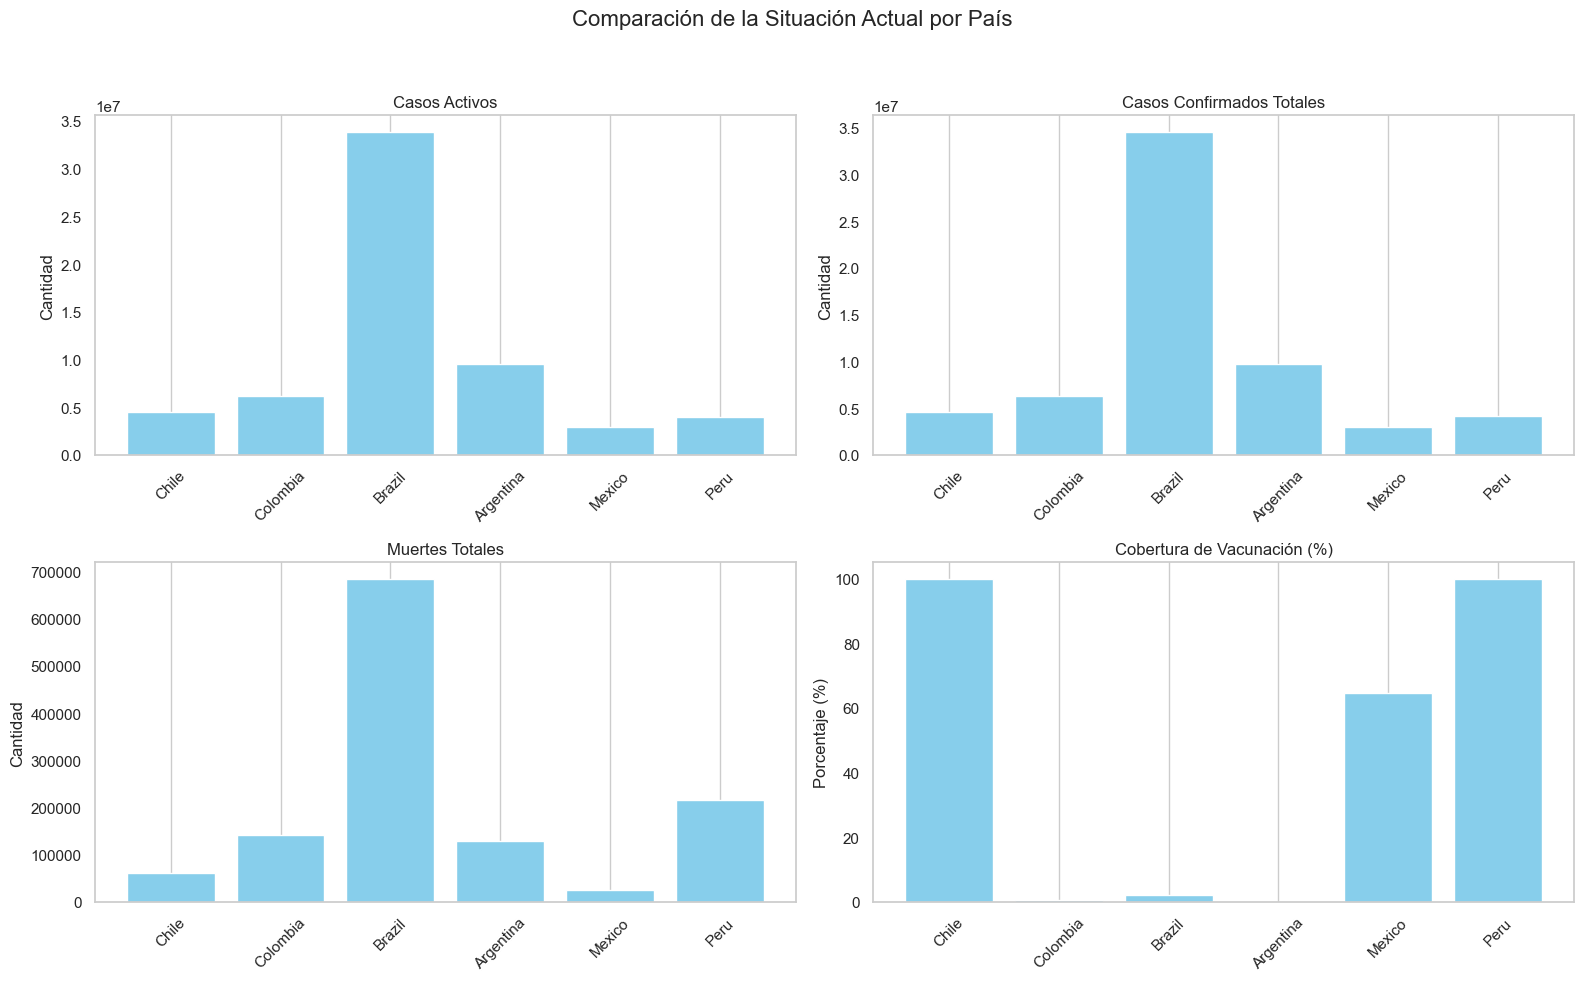

In [66]:
# Crear DataFrame con los últimos datos disponibles por país
df_actual = df_datos_finales_filtrado.sort_values('date').groupby('country_name').tail(1)

# Calcular casos activos
df_actual['casos_activos'] = (
    df_actual['cumulative_confirmed'] - 
    df_actual['cumulative_recovered'] - 
    df_actual['cumulative_deceased']
)

# Cobertura de vacunación
df_actual['vac_coverage'] = (df_actual['cumulative_vaccine_doses_administered'] / df_actual['population']) * 100
df_actual['vac_coverage'] = df_actual['vac_coverage'].clip(upper=100)

# Filtrar países de interés
df_actual = df_actual[df_actual['country_name'].isin(df_datos_finales_filtrado['country_name'].unique())]

# Gráfico comparativo
indicadores = ['casos_activos', 'cumulative_confirmed', 'cumulative_deceased', 'vac_coverage']
titulos = ['Casos Activos', 'Casos Confirmados Totales', 'Muertes Totales', 'Cobertura de Vacunación (%)']

plt.figure(figsize=(16,10))

for i, indicador in enumerate(indicadores):
    plt.subplot(2, 2, i+1)
    plt.bar(df_actual['country_name'], df_actual[indicador], color='skyblue')
    plt.title(titulos[i])
    plt.ylabel('Cantidad' if indicador != 'vac_coverage' else 'Porcentaje (%)')
    plt.xticks(rotation=45)
    plt.grid(axis='y')

plt.suptitle('Comparación de la Situación Actual por País', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


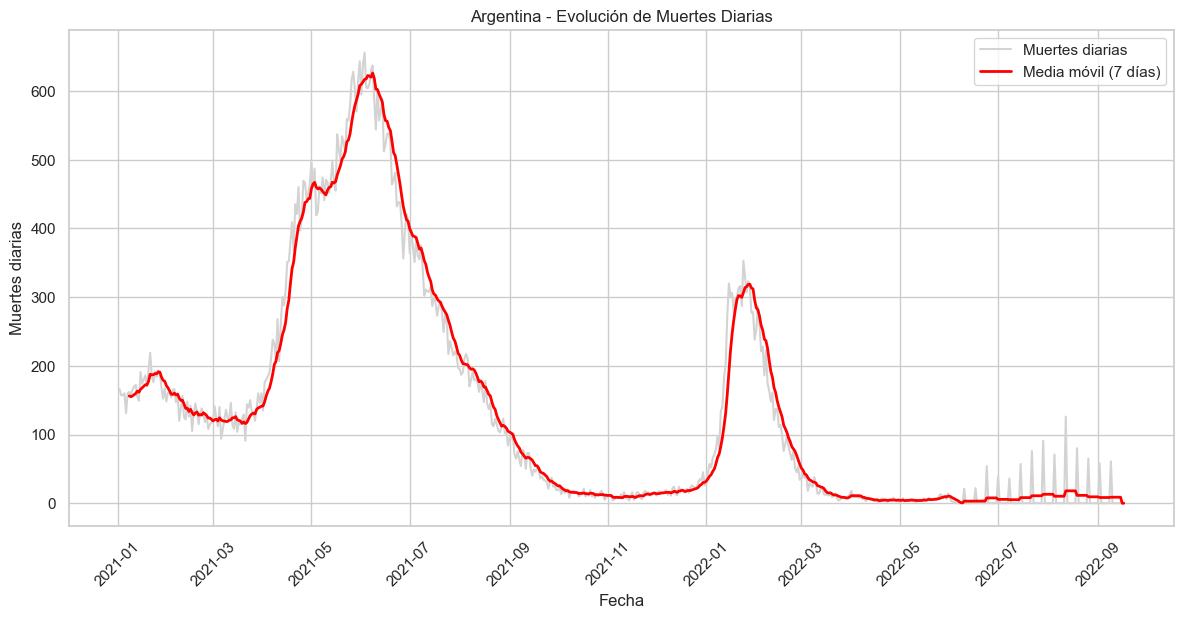

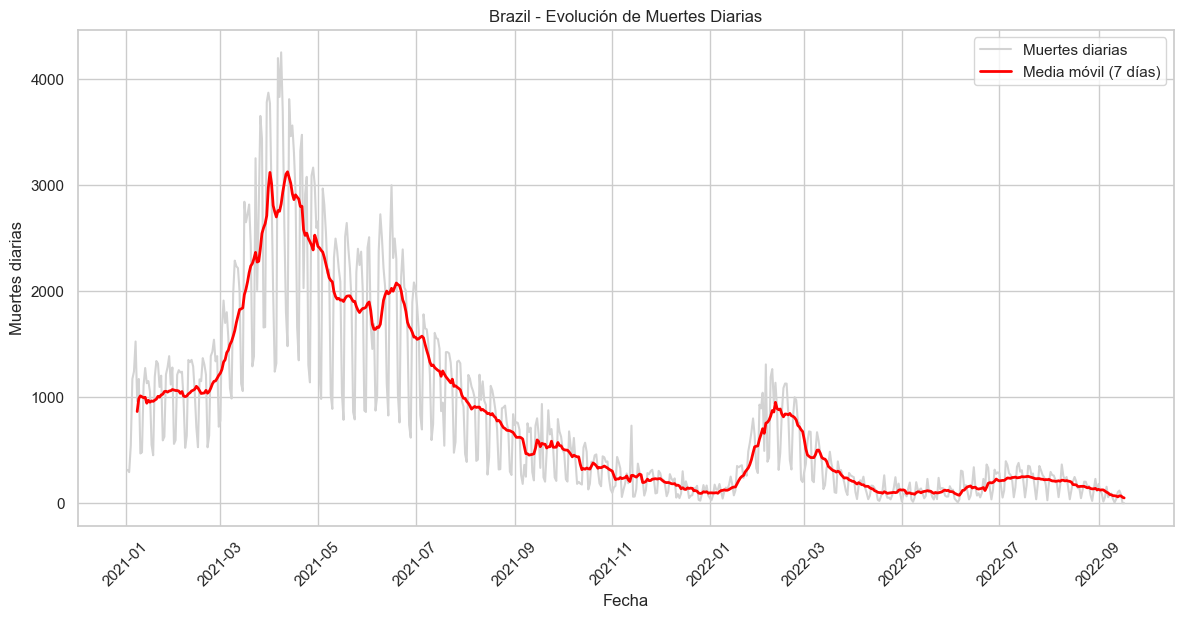

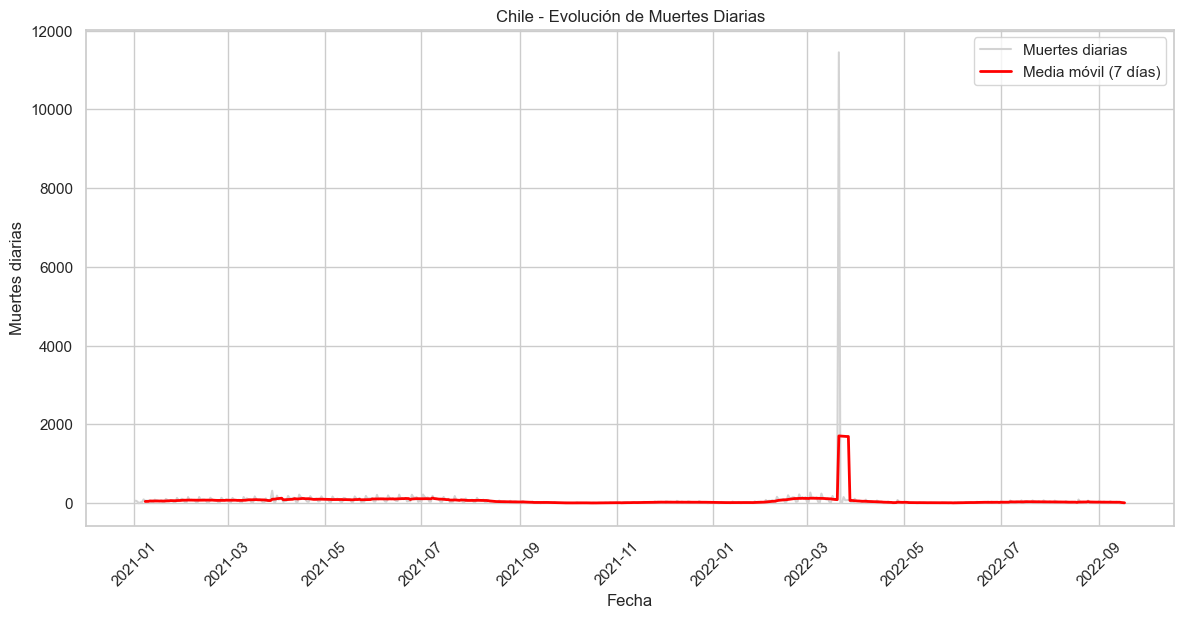

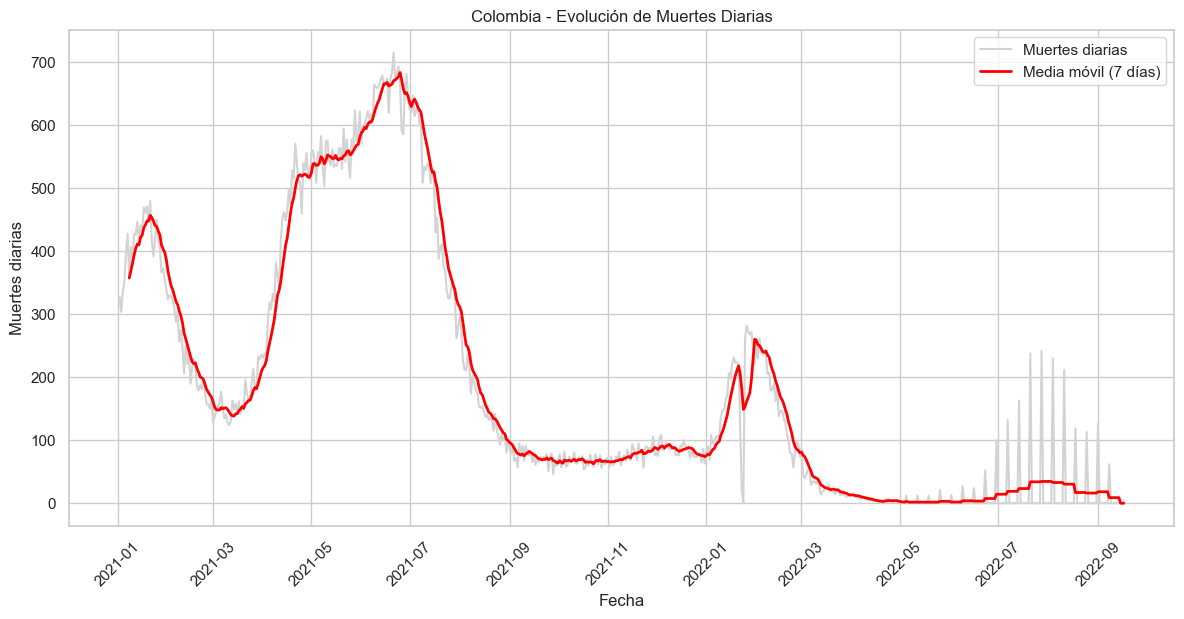

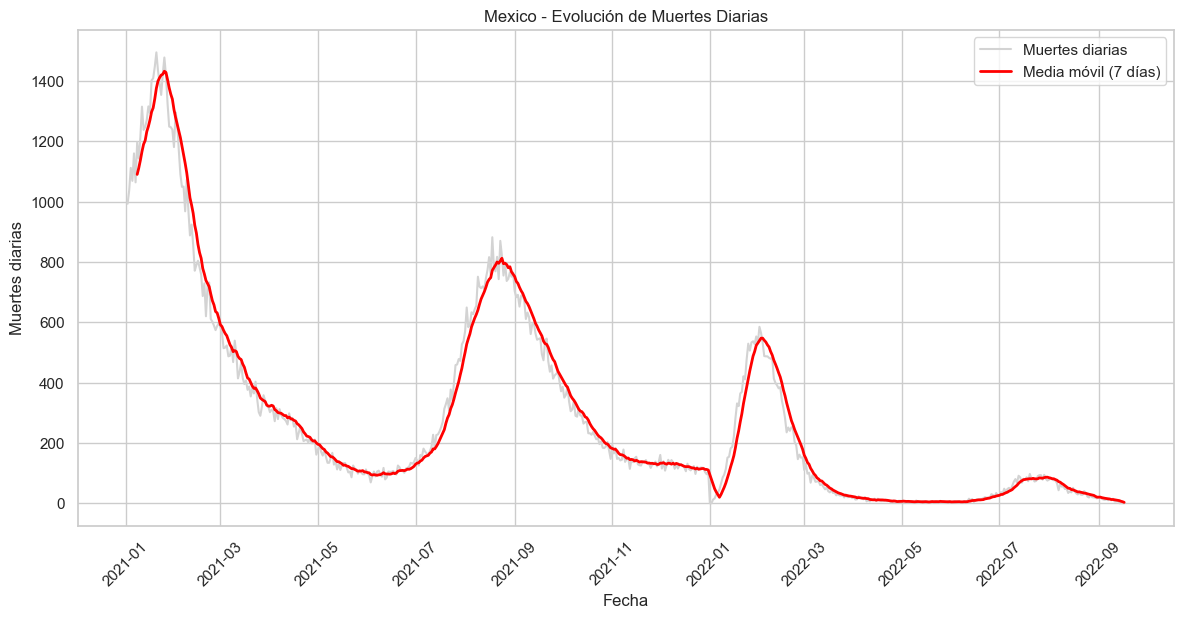

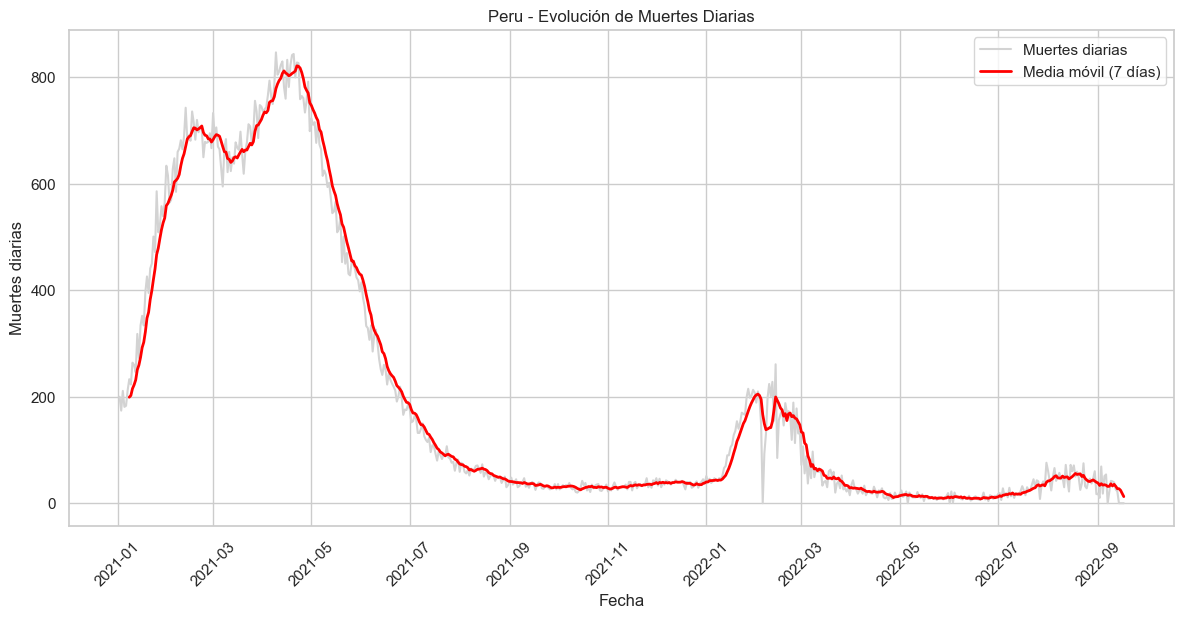

In [ ]:
for pais in df_datos_finales_filtrado['country_name'].unique(): 
    df_pais = df_datos_finales_filtrado[df_datos_finales_filtrado['country_name'] == pais].copy()
    df_pais = df_pais.sort_values('date')

    # Calcular muertes diarias (con valores negativos corregidos)
    df_pais['muertes_diarias'] = df_pais['cumulative_deceased'].diff().clip(lower=0)

    # Media móvil de 7 días
    df_pais['muertes_diarias_7d'] = df_pais['muertes_diarias'].rolling(window=7).mean()

    # Gráfico
    plt.figure(figsize=(12,6))
    plt.plot(df_pais['date'], df_pais['muertes_diarias'], color='lightgray', label='Muertes diarias')
    plt.plot(df_pais['date'], df_pais['muertes_diarias_7d'], color='red', linewidth=2, label='Media móvil (7 días)')

    plt.title(f'{pais} - Evolución de Muertes Diarias')
    plt.xlabel('Fecha')
    plt.ylabel('Muertes diarias')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()



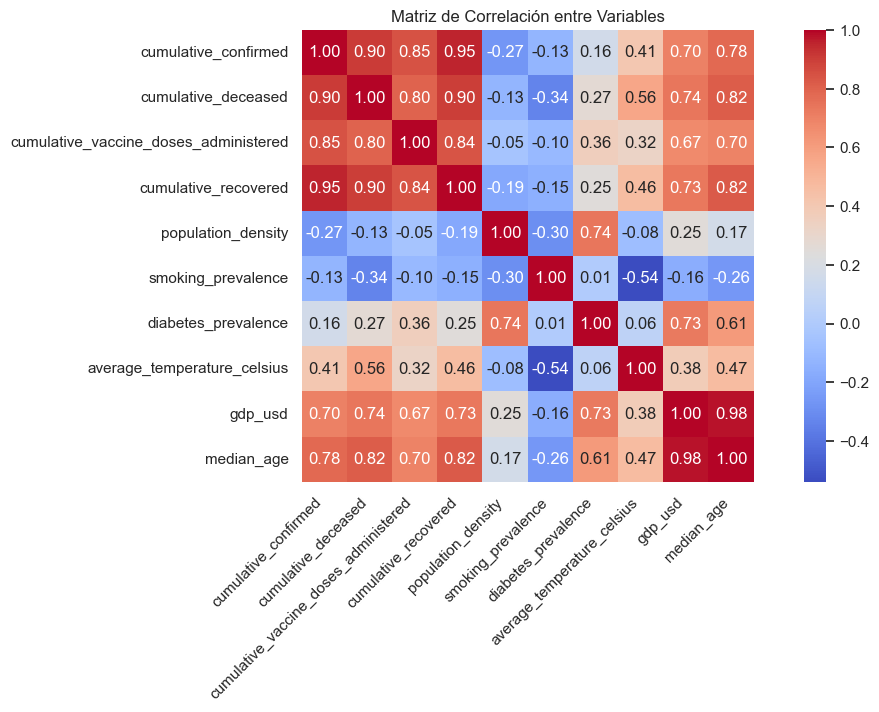

In [67]:
# Crear columna de edad promedio a partir de los grupos de edades
columnas_edades = [
    'population_age_00_09', 'population_age_10_19', 'population_age_20_29',
    'population_age_30_39', 'population_age_40_49', 'population_age_50_59',
    'population_age_60_69', 'population_age_70_79', 'population_age_80_and_older'
]

# Asegúrate de que las columnas existen antes de calcular
columnas_existentes = [col for col in columnas_edades if col in df_datos_finales_filtrado.columns]
df_datos_finales_filtrado['median_age'] = df_datos_finales_filtrado[columnas_existentes].mean(axis=1)

# Selección de columnas numéricas relevantes (incluyendo la nueva 'median_age')
columnas_interes = [
    'cumulative_confirmed', 
    'cumulative_deceased', 
    'cumulative_vaccine_doses_administered',
    'cumulative_recovered',
    'population_density', 
    'smoking_prevalence', 
    'diabetes_prevalence', 
    'average_temperature_celsius',
    'gdp_usd',  
    'median_age'
]

# Filtrar solo columnas que existen en el DataFrame
columnas_validas = [col for col in columnas_interes if col in df_datos_finales_filtrado.columns]

# Filtrar datos
df_corr = df_datos_finales_filtrado[columnas_validas].copy()

# Eliminar filas con valores faltantes
df_corr = df_corr.dropna()

# Calcular matriz de correlación
correlation_matrix = df_corr.corr()
#mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Visualizar
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matriz de Correlación entre Variables')
plt.tight_layout()
plt.xticks(rotation=45, ha='right', va='top')
plt.show()




1.Alta correlación entre casos confirmados, muertes, dosis y recuperados  
2.La edad mediana tiene alta correlación con casi todo
3.El PIB (GDP) también tiene un fuerte vínculo Alta correlación con:median_age (0.98) diabetes_prevalence (0.73) confirmed y deceased (>0.70)
Interpretación: Países más ricos reportan más casos, posiblemente por mejor sistema de monitoreo sanitario.
4.La temperatura promedio tiene relación moderada con el COVID
5.El tabaquismo tiene correlación negativa con otras variables

C:\Users\benav\AppData\Local\Temp\ipykernel_13800\3383371259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_datos_finales_filtrado,


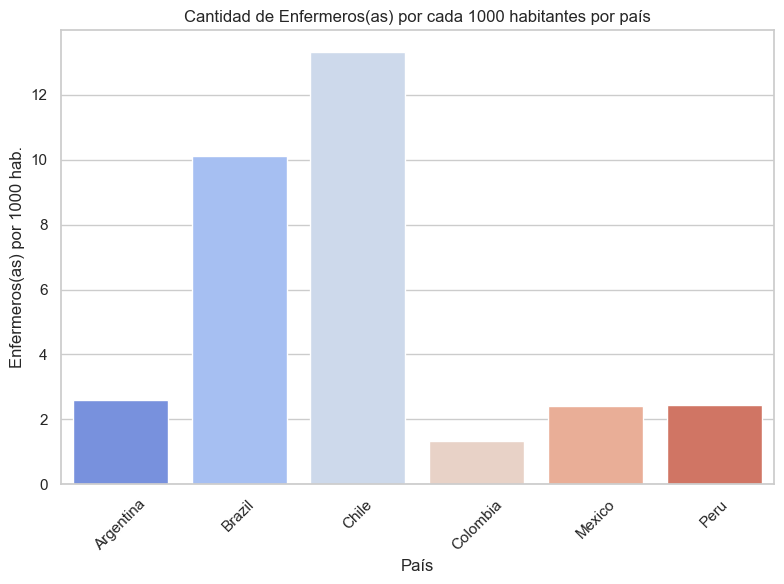

In [68]:
plt.figure(figsize=(8,6))
sns.barplot(data=df_datos_finales_filtrado, 
            x='country_name', 
            y='nurses_per_1000', 
            palette='coolwarm')

plt.title('Cantidad de Enfermeros(as) por cada 1000 habitantes por país')
plt.xlabel('País')
plt.ylabel('Enfermeros(as) por 1000 hab.')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [69]:
df_datos_finales_filtrado = df_datos_finales_filtrado.round(2)
df_datos_finales_filtrado

,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered,nivel_recuperacion,month,mes,median_age
366,AR,2021-01-01,AR,Argentina,2685.0,140.0,1662867.0,46522.0,18849.0,44938712.0,...,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January,2021-01-01,4457455.11
367,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January,2021-01-01,4457455.11
368,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January,2021-01-01,4457455.11
369,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January,2021-01-01,4457455.11
370,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,147.09,79.48,26.6,15.8,0.0,0.0,Bajo,January,2021-01-01,4457455.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253872,PE,2022-09-13,PE,Peru,1150.0,22.0,4127612.0,216173.0,41669294.0,29381884.0,...,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September,2022-09-01,3264653.78
10253873,PE,2022-09-14,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September,2022-09-01,3264653.78
10253874,PE,2022-09-15,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September,2022-09-01,3264653.78
10253875,PE,2022-09-16,PE,Peru,0.0,0.0,4127612.0,216173.0,41669294.0,29381884.0,...,146.37,84.82,63.9,12.6,0.0,0.0,Bajo,September,2022-09-01,3264653.78


In [72]:
df_datos_finales_filtrado.to_csv('CSV\\latam_covid.csv', index=False)